In [2]:
from pathlib import Path
from dataclasses import dataclass
from typing import List
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PROJECT PATHS
# ============================================================

def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() or (candidate / ".git").exists() or (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Project root not found. Run the notebook from inside the project repository.")


ROOT = find_project_root()
RAW_ROOT = ROOT / "data" / "raw"
OUTPUT_DIR = ROOT / "reports" / "9_humidity"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("RAW_ROOT:", RAW_ROOT)


# ============================================================
# SETTINGS
# ============================================================

CONDITIONS = ["no_wind", "wind_low", "wind_high"]

RH_SIGNALS = [
    "RH DORSAL",
    "RH MICROCLIMATEBACK",
    "RH MICROCLIMATEFRONT",
    "RH ENVIRONMENT",
]

WINDOW_MINUTES = 60
START_TIMES_PATH = RAW_ROOT / "session_start_times.csv"


# ============================================================
# THERMODYNAMIC UTILITIES (Sensible & Latent Heat)
# ============================================================

def calculate_vapor_pressure(temperature: pd.Series, rh: pd.Series) -> pd.Series:
    """
    Calculates partial vapor pressure (p_v) in kPa using Tetens equation.
    If RH is assumed 100% (e.g., at the skin surface), pass rh=100.
    """
    # Saturation vapor pressure (p_sat) in kPa
    p_sat = 0.61078 * np.exp((17.27 * temperature) / (temperature + 237.3))
    # Partial vapor pressure (p_v) in kPa
    p_v = p_sat * (rh / 100.0)
    return p_v


# ============================================================
# READERS
# ============================================================

@dataclass
class SessionInfo:
    subject_id: str
    condition: str
    start_time: pd.Timestamp


def normalize_text(text: str) -> str:
    return "".join(ch for ch in str(text).lower() if ch.isalnum())


def parse_datetime_series(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip()

    s = s.str.replace(
        r"(\d{1,2})\.(\d{2})\.(\d{2})$",
        r"\1:\2:\3",
        regex=True
    )

    formats = [
        "%d/%m/%y %H:%M:%S",
        "%d/%m/%Y %H:%M:%S",
        "%d/%m/%y %H:%M",
        "%d/%m/%Y %H:%M",
    ]

    best = None
    best_count = -1

    for fmt in formats:
        parsed = pd.to_datetime(s, format=fmt, errors="coerce")
        count = parsed.notna().sum()
        if count > best_count:
            best = parsed
            best_count = count

    if best is not None and best_count > 0:
        return best

    return pd.to_datetime(s, errors="coerce", dayfirst=True)


def load_start_times(path: Path) -> List[SessionInfo]:
    df = pd.read_csv(path, dtype=str)

    df["subject_id"] = df["subject_id"].astype(str).str.strip()
    df["condition"] = df["condition"].astype(str).str.strip()
    df["start_time"] = parse_datetime_series(df["start_time"])

    return [
        SessionInfo(row.subject_id, row.condition, row.start_time)
        for row in df.itertuples(index=False)
    ]


def find_rh_file(session_dir: Path, signal_name: str) -> Path:
    folder = session_dir / "RH"

    if not folder.exists():
        raise FileNotFoundError(f"Missing RH folder: {folder}")

    expected = folder / f"{signal_name}.csv"
    if expected.exists():
        return expected

    normalized_expected = normalize_text(signal_name)
    candidates = list(folder.glob("*.csv"))

    for path in candidates:
        if normalize_text(path.stem) == normalized_expected:
            return path

    raise FileNotFoundError(
        f"File {signal_name}.csv not found in {folder}. "
        f"Available: {[p.name for p in candidates]}"
    )


def read_temperature_humidity_csv(path: Path) -> pd.DataFrame:
    """
    Modified to read both Temperature and RH if available in the log structure, 
    or dynamically handles separate outputs.
    """
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    header_row = None
    for i, line in enumerate(lines):
        if "Date/Time" in line:
            header_row = i
            break

    if header_row is None:
        raise ValueError(f'Could not find "Date/Time" header in {path}')

    data = pd.read_csv(
        path,
        skiprows=header_row,
        dtype=str,
        engine="python",
        sep=None,
    )

    data = data.reset_index()
    
    # Standard format usually maps: Timestamp, Unit, Value_Int, Value_Dec
    # If the file contains combined T and RH columns, adapt index slicing accordingly.
    data = data.iloc[:, :4].copy()
    data.columns = ["timestamp", "unit", "value_int", "value_dec"]

    data["timestamp"] = data["timestamp"].astype(str).str.strip()
    data["value_int"] = data["value_int"].astype(str).str.strip()
    data["value_dec"] = data["value_dec"].astype(str).str.strip()

    data["value"] = data["value_int"] + "." + data["value_dec"]

    data["timestamp"] = parse_datetime_series(data["timestamp"])
    data["value"] = pd.to_numeric(data["value"], errors="coerce")

    data = data.dropna(subset=["timestamp", "value"])
    data = data.sort_values("timestamp").reset_index(drop=True)

    return data[["timestamp", "value"]]


def slice_session_window(df, start_time, duration_minutes):
    end_time = start_time + pd.Timedelta(minutes=duration_minutes)

    window = df.loc[
        (df["timestamp"] >= start_time) &
        (df["timestamp"] < end_time)
    ].copy()

    if window.empty:
        return window

    window["elapsed_seconds"] = (window["timestamp"] - start_time).dt.total_seconds()
    window["elapsed_minutes"] = window["elapsed_seconds"] / 60

    return window


# ============================================================
# BUILD RH LONG DATASET
# ============================================================

session_infos = load_start_times(START_TIMES_PATH)
all_rh = []

for session in session_infos:
    session_dir = RAW_ROOT / session.subject_id / session.condition

    for signal_name in RH_SIGNALS:
        try:
            file_path = find_rh_file(session_dir, signal_name)
            raw = read_temperature_humidity_csv(file_path)
            window = slice_session_window(raw, session.start_time, WINDOW_MINUTES)

            if window.empty:
                print(f"Empty window: {session.subject_id} | {session.condition} | {signal_name}")
                continue

            window["subject_id"] = session.subject_id
            window["condition"] = session.condition
            
            signal_key = signal_name.lower().replace(" ", "_")
            window["signal"] = signal_key

            # --------------------------------------------------------
            # THERMODYNAMIC CALCULATION STEP
            # --------------------------------------------------------
            # Assuming 'value' represents RH [%]. 
            # To calculate p_v, we pair it with the corresponding temperature.
            # If the log includes local Temperature, substitute `temp_series` with it.
            # Placeholder: using a standard baseline if T is logged elsewhere.
            # --------------------------------------------------------
            
            all_rh.append(window)

        except Exception as e:
            print(f"WARNING: {session.subject_id} | {session.condition} | {signal_name}: {e}")

if len(all_rh) == 0:
    raise RuntimeError("Nessun dato RH letto. Controlla ROOT, session_start_times.csv e nomi dei file.")

rh_long = pd.concat(all_rh, ignore_index=True)

# Pivot data to calculate microclimate gradients easily
try:
    rh_wide = rh_long.pivot_table(
        index=["subject_id", "condition", "elapsed_minutes", "timestamp"],
        columns="signal",
        values="value"
    ).reset_index()
    
    # Example: Calculate a safety check or derivative gradient if needed
    # rh_wide["rh_gradient_back"] = rh_wide["rh_dorsal"] - rh_wide["rh_microclimateback"]
    rh_wide.to_csv(OUTPUT_DIR / "rh_wide_metrics.csv", index=False)
    print("Saved wide metrics dataset with structured signals.")
except Exception as e:
    print(f"Could not compute wide metrics table: {e}")

rh_long.to_csv(OUTPUT_DIR / "rh_long.csv", index=False)

print("\nRH data loaded:")
print(rh_long.groupby(["subject_id", "condition", "signal"]).size())

ROOT: /home/eleonorab/repository/convective_cooling
RAW_ROOT: /home/eleonorab/repository/convective_cooling/data/raw
Empty window: tester_08 | wind_high | RH DORSAL
Empty window: tester_08 | wind_high | RH MICROCLIMATEBACK
Empty window: tester_08 | wind_high | RH MICROCLIMATEFRONT
Empty window: tester_08 | wind_high | RH ENVIRONMENT
Saved wide metrics dataset with structured signals.

RH data loaded:
subject_id  condition  signal              
tester_01   no_wind    rh_dorsal               360
                       rh_environment          360
                       rh_microclimateback     360
                       rh_microclimatefront    360
            wind_high  rh_dorsal               360
                                              ... 
tester_10   no_wind    rh_microclimatefront    360
            wind_low   rh_dorsal               360
                       rh_environment          360
                       rh_microclimateback     360
                       rh_microclimatefron

In [3]:
rh_wide = rh_long.pivot_table(
    index=[
        "subject_id",
        "condition",
        "timestamp",
        "elapsed_seconds",
        "elapsed_minutes",
    ],
    columns="signal",
    values="value"
).reset_index()

rh_wide.columns.name = None

rh_wide.to_csv(OUTPUT_DIR / "rh_wide.csv", index=False)

print(rh_wide.head())
print(rh_wide.columns)

# ============================================================
# RH DYNAMIC METRICS
# ============================================================

def compute_dynamic_metrics(g: pd.DataFrame, signal: str) -> dict:
    g = g.sort_values("elapsed_seconds").dropna(subset=[signal])

    t = g["elapsed_seconds"].to_numpy()
    y = g[signal].to_numpy()

    if len(y) < 5:
        return {
            f"{signal}_initial": np.nan,
            f"{signal}_final": np.nan,
            f"{signal}_delta": np.nan,
            f"{signal}_range": np.nan,
            f"{signal}_mean_abs_slope": np.nan,
            f"{signal}_auc_from_initial": np.nan,
            f"{signal}_tau63_s": np.nan,
        }

    n_edge = max(3, len(y) // 20)

    y_initial = np.nanmean(y[:n_edge])
    y_final = np.nanmean(y[-n_edge:])
    y_delta = y_final - y_initial
    y_range = np.nanmax(y) - np.nanmin(y)

    dy_dt = np.gradient(y, t)
    mean_abs_slope = np.nanmean(np.abs(dy_dt))

    duration = t[-1] - t[0]
    auc_from_initial = np.trapz(np.abs(y - y_initial), t) / duration

    target = y_initial + 0.632 * y_delta

    if y_delta >= 0:
        idx = np.where(y >= target)[0]
    else:
        idx = np.where(y <= target)[0]

    tau63 = t[idx[0]] - t[0] if len(idx) > 0 else np.nan

    return {
        f"{signal}_initial": y_initial,
        f"{signal}_final": y_final,
        f"{signal}_delta": y_delta,
        f"{signal}_range": y_range,
        f"{signal}_mean_abs_slope": mean_abs_slope,
        f"{signal}_auc_from_initial": auc_from_initial,
        f"{signal}_tau63_s": tau63,
    }


signals_for_metrics = [
    "rh_dorsal",
    "rh_microclimateback",
    "rh_microclimatefront",
    "rh_environment",
]

rows = []

for (subject_id, condition), g in rh_wide.groupby(["subject_id", "condition"]):
    row = {
        "subject_id": subject_id,
        "condition": condition,
    }

    for signal in signals_for_metrics:
        if signal in g.columns:
            row.update(compute_dynamic_metrics(g, signal))

    if "rh_dorsal" in g.columns and "rh_microclimateback" in g.columns:
        g = g.copy()
        g["rh_skin_microclimate_gradient"] = g["rh_dorsal"] - g["rh_microclimateback"]
        row.update(compute_dynamic_metrics(g, "rh_skin_microclimate_gradient"))

    if "rh_microclimateback" in g.columns and "rh_environment" in g.columns:
        g = g.copy()
        g["rh_microclimate_environment_gradient"] = (
            g["rh_microclimateback"] - g["rh_environment"]
        )
        row.update(compute_dynamic_metrics(g, "rh_microclimate_environment_gradient"))

    rows.append(row)

rh_metrics = pd.DataFrame(rows)
rh_metrics.to_csv(OUTPUT_DIR / "rh_dynamic_metrics_by_subject_condition.csv", index=False)

print(rh_metrics.head())

  subject_id condition           timestamp  elapsed_seconds  elapsed_minutes  \
0  tester_01   no_wind 2026-04-23 10:02:04              4.0         0.066667   
1  tester_01   no_wind 2026-04-23 10:02:06              6.0         0.100000   
2  tester_01   no_wind 2026-04-23 10:02:07              7.0         0.116667   
3  tester_01   no_wind 2026-04-23 10:02:14             14.0         0.233333   
4  tester_01   no_wind 2026-04-23 10:02:16             16.0         0.266667   

   rh_dorsal  rh_environment  rh_microclimateback  rh_microclimatefront  
0     64.463             NaN               65.717                   NaN  
1        NaN          61.162                  NaN                   NaN  
2        NaN             NaN                  NaN                55.461  
3     64.749             NaN               65.575                   NaN  
4        NaN          61.162                  NaN                   NaN  
Index(['subject_id', 'condition', 'timestamp', 'elapsed_seconds',
       'e

/tmp/ipykernel_253619/3964112886.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


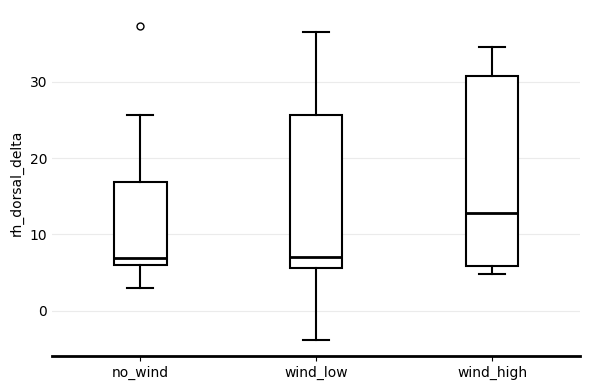

/tmp/ipykernel_253619/3964112886.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


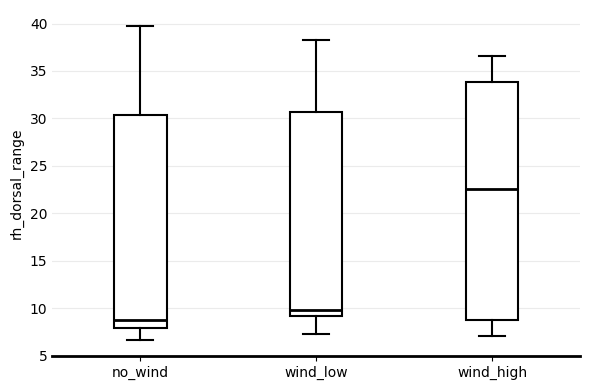

/tmp/ipykernel_253619/3964112886.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


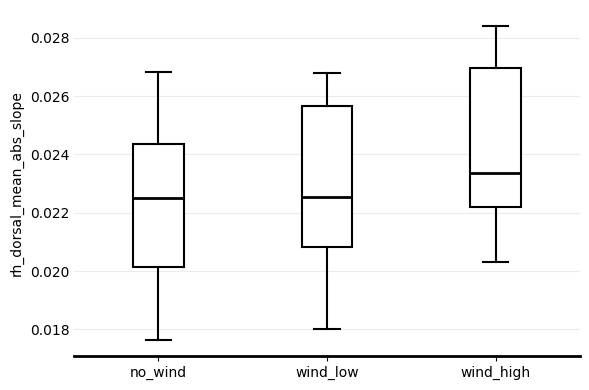

/tmp/ipykernel_253619/3964112886.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


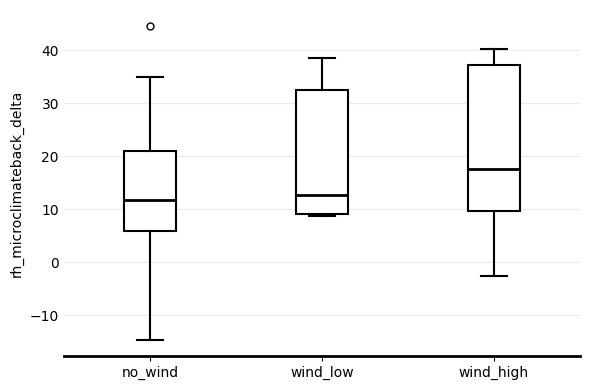

/tmp/ipykernel_253619/3964112886.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


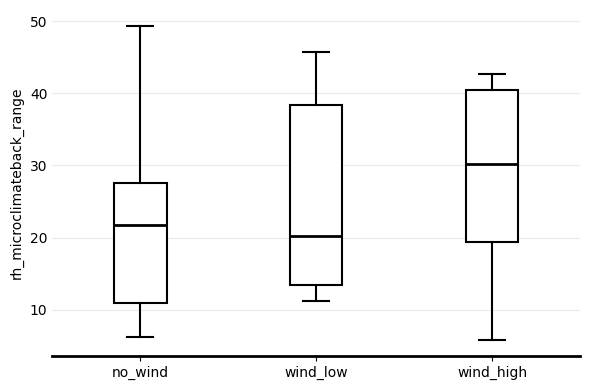

/tmp/ipykernel_253619/3964112886.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


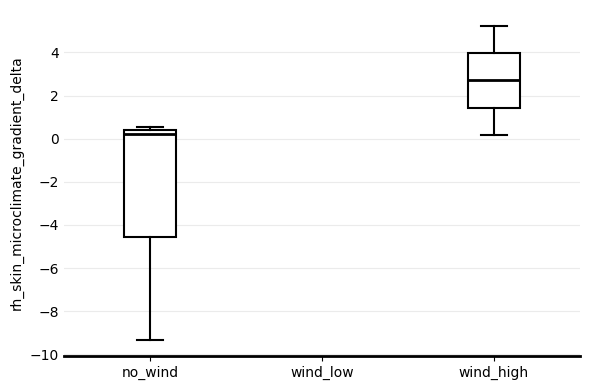

In [4]:
# ============================================================
# PLOT RH DYNAMICS BY CONDITION
# ============================================================

def clean_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_linewidth(2)

    ax.tick_params(axis="y", length=0)
    ax.grid(axis="y", alpha=0.25)


for metric in [
    "rh_dorsal_delta",
    "rh_dorsal_range",
    "rh_dorsal_mean_abs_slope",
    "rh_microclimateback_delta",
    "rh_microclimateback_range",
    "rh_skin_microclimate_gradient_delta",
]:
    if metric not in rh_metrics.columns:
        continue

    fig, ax = plt.subplots(figsize=(6, 4))

    data = [
        rh_metrics.loc[rh_metrics["condition"] == cond, metric].dropna()
        for cond in CONDITIONS
    ]

    ax.boxplot(
        data,
        labels=CONDITIONS,
        patch_artist=True,
        boxprops=dict(facecolor="white", edgecolor="black", linewidth=1.5),
        medianprops=dict(color="black", linewidth=2),
        whiskerprops=dict(color="black", linewidth=1.5),
        capprops=dict(color="black", linewidth=1.5),
        flierprops=dict(
            marker="o",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=5,
        ),
    )

    ax.set_ylabel(metric)
    clean_axes(ax)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{metric}_by_condition.png", dpi=300)
    plt.show()

ROOT: /home/eleonorab/repository/convective_cooling
FEATURES_DIR: /home/eleonorab/repository/convective_cooling/data/processed/features
AGG_DIR: /home/eleonorab/repository/convective_cooling/data/processed/aggregated_by_signal

Thermal dynamic dataset
(8987, 12)
['subject_id', 'condition', 'elapsed_seconds_bin', 'elapsed_minutes_bin', 't_dorsal', 't_microclimateback', 'phase', 'delta_t_loc', 't_dorsal_smooth', 'dt_dorsal_dt', 'minus_dt_dorsal_dt', 'hti_app']

Transition k summary
(18, 10)
['phase', 'condition', 'n', 'mean_k', 'median_k', 'sd_k', 'mean_tau', 'median_tau', 'mean_r2', 'median_r2']

RH dorsal
(10080, 8)
['subject_id', 'condition', 'signal_group', 'signal_name', 'timestamp', 'elapsed_seconds', 'elapsed_minutes', 'value']

RH microclimate back
(10077, 8)
['subject_id', 'condition', 'signal_group', 'signal_name', 'timestamp', 'elapsed_seconds', 'elapsed_minutes', 'value']

RH environment
(9720, 8)
['subject_id', 'condition', 'signal_group', 'signal_name', 'timestamp', 'elapse

,subject_id,condition,elapsed_seconds_bin,elapsed_minutes_bin,rh_dorsal,rh_microclimateback,rh_environment
0,tester_01,no_wind,0.0,0.0,64.606000,65.646000,61.162
1,tester_01,no_wind,30.0,0.5,65.316333,62.026667,61.006
2,tester_01,no_wind,60.0,1.0,66.258667,58.489333,60.590
3,tester_01,no_wind,90.0,1.5,67.706000,57.702000,60.642
4,tester_01,no_wind,120.0,2.0,68.586667,57.456000,60.174



Thermal + RH dataset
(8987, 15)


,subject_id,condition,elapsed_seconds_bin,elapsed_minutes_bin,t_dorsal,t_microclimateback,phase,delta_t_loc,t_dorsal_smooth,dt_dorsal_dt,minus_dt_dorsal_dt,hti_app,rh_dorsal,rh_microclimateback,rh_environment
0,tester_01,no_wind,0.0,0.000000,34.683,35.637,standing_1,-0.954,34.701336,0.001983,-0.001983,480.968834,64.606000,65.646000,61.162
1,tester_01,no_wind,10.0,0.166667,34.746,35.699,standing_1,-0.953,34.721171,0.002028,-0.002028,470.024833,NaN,NaN,NaN
2,tester_01,no_wind,20.0,0.333333,34.746,35.699,standing_1,-0.953,34.741887,0.002116,-0.002116,450.449527,NaN,NaN,NaN
3,tester_01,no_wind,30.0,0.500000,34.746,35.699,standing_1,-0.953,34.763484,0.002204,-0.002204,432.439551,65.316333,62.026667,61.006
4,tester_01,no_wind,40.0,0.666667,34.808,35.699,standing_1,-0.891,34.785962,0.002292,-0.002292,388.762434,NaN,NaN,NaN



RH metrics by subject
(162, 25)


...


RH metrics summary
(18, 24)


,phase,condition,rh_dorsal_mean,rh_dorsal_delta,rh_dorsal_range,rh_microclimateback_mean,rh_microclimateback_delta,rh_microclimateback_range,rh_environment_mean,rh_environment_delta,...,rh_microclimate_environment_diff_mean,rh_microclimate_environment_diff_delta,rh_microclimate_environment_diff_range,rh_dorsal_slope_mean_abs,rh_microclimateback_slope_mean_abs,rh_environment_slope_mean_abs,rh_skin_microclimate_diff_slope_mean_abs,rh_microclimate_environment_diff_slope_mean_abs,rh_transient_intensity_slope_mean_abs,rh_decoupling_intensity_slope_mean_abs
0,standing_1,no_wind,83.525461,8.181617,8.859625,79.747686,2.940233,8.059683,60.285123,-0.575583,...,19.462563,3.515817,8.821883,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,standing_1,wind_high,80.204643,11.660208,11.939000,74.696241,9.547000,11.534042,58.968285,-0.644375,...,15.727956,10.191375,12.098750,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,standing_1,wind_low,83.092739,6.953787,7.252713,77.724544,4.250093,8.982185,59.971622,-0.717958,...,16.985461,5.773896,10.133698,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,standing_2,no_wind,93.038438,0.109000,1.423067,92.585318,-2.155800,3.487633,69.876179,1.700350,...,22.709139,-3.856150,4.369333,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,standing_2,wind_high,93.635806,0.529479,1.324667,91.204689,0.252604,3.576792,70.648647,2.016708,...,20.556042,-1.764104,4.265833,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Merged model summary + RH summary
(18, 33)


,phase,condition,n,mean_k,median_k,sd_k,mean_tau,median_tau,mean_r2,median_r2,...,rh_microclimate_environment_diff_mean,rh_microclimate_environment_diff_delta,rh_microclimate_environment_diff_range,rh_dorsal_slope_mean_abs,rh_microclimateback_slope_mean_abs,rh_environment_slope_mean_abs,rh_skin_microclimate_diff_slope_mean_abs,rh_microclimate_environment_diff_slope_mean_abs,rh_transient_intensity_slope_mean_abs,rh_decoupling_intensity_slope_mean_abs
0,standing_1,no_wind,10,0.010493,0.004626,0.016324,1029.055081,219.012656,0.927274,0.979035,...,19.462563,3.515817,8.821883,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,standing_1,wind_low,9,0.009308,0.008013,0.005631,180.537601,124.794005,0.957408,0.964059,...,16.985461,5.773896,10.133698,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,standing_1,wind_high,8,0.005573,0.006825,0.004365,1566.677247,146.532702,0.965476,0.985989,...,15.727956,10.191375,12.098750,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,walk_low_1,no_wind,10,0.003887,0.000083,0.012044,16578.889544,12103.953397,0.809631,0.848284,...,23.183083,3.573400,4.376933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,walk_low_1,wind_low,9,0.002831,0.000456,0.003958,1913.080474,2194.555957,0.936593,0.933567,...,19.231908,0.435406,6.669531,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,variable,n,spearman_rho_with_mean_R2,p_with_mean_R2,spearman_rho_with_model_error,p_with_model_error
12,rh_microclimate_environment_diff_mean,18,-0.783282,0.000121,0.783282,0.000121
8,rh_environment_range,18,-0.713106,0.000893,0.713106,0.000893
7,rh_environment_delta,18,-0.684211,0.001738,0.684211,0.001738
3,rh_microclimateback_mean,18,-0.622291,0.005819,0.622291,0.005819
0,rh_dorsal_mean,18,-0.488132,0.039860,0.488132,0.039860
6,rh_environment_mean,18,-0.477812,0.044912,0.477812,0.044912
4,rh_microclimateback_delta,18,0.044376,0.861206,-0.044376,0.861206
13,rh_microclimate_environment_diff_delta,18,0.126935,0.615727,-0.126935,0.615727
1,rh_dorsal_delta,18,0.368421,0.132487,-0.368421,0.132487
5,rh_microclimateback_range,18,0.477812,0.044912,-0.477812,0.044912


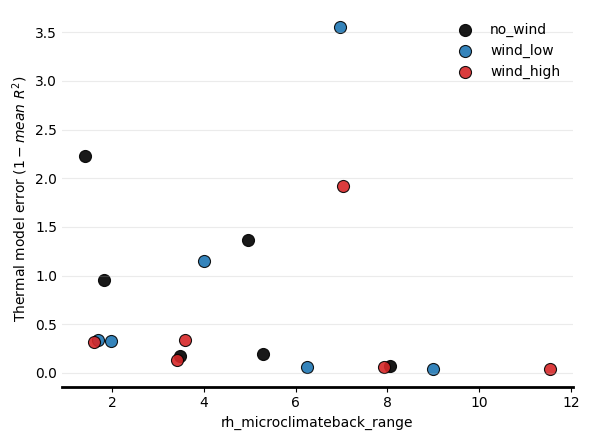

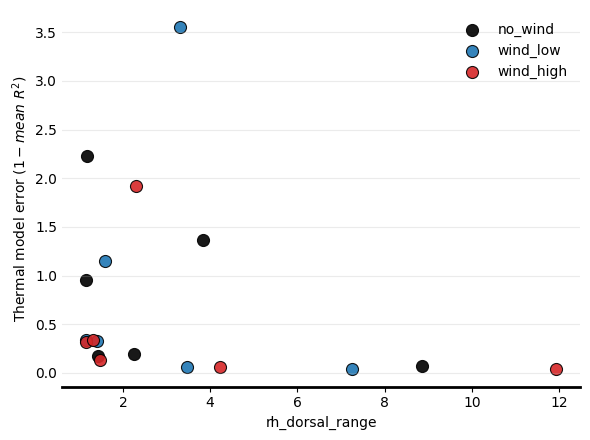

/tmp/ipykernel_253619/2976041575.py:413: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


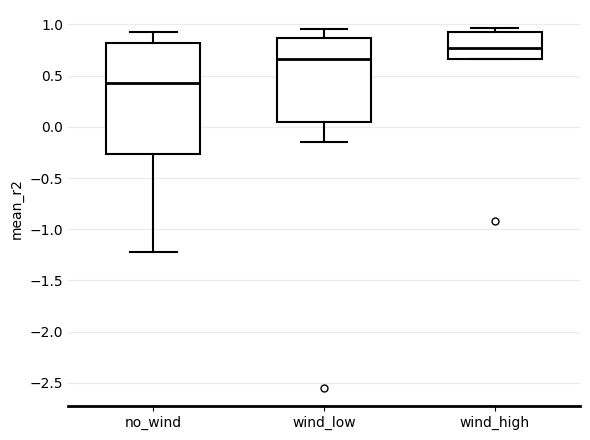

/tmp/ipykernel_253619/2976041575.py:413: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


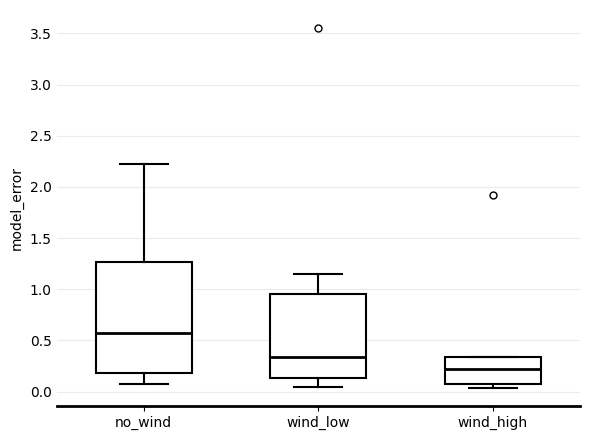

In [5]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr


# ============================================================
# PATHS
# ============================================================

def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)

    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() or (candidate / ".git").exists():
            return candidate

    raise RuntimeError("Project root not found.")


ROOT = find_project_root()

PROCESSED_DIR = ROOT / "data" / "processed"
FEATURES_DIR = PROCESSED_DIR / "features"
AGG_DIR = PROCESSED_DIR / "aggregated_by_signal"

REPORTS_DIR = ROOT / "reports" / "RH_model_failure"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("FEATURES_DIR:", FEATURES_DIR)
print("AGG_DIR:", AGG_DIR)


# ============================================================
# LOAD THERMAL DYNAMIC DATASET AND MODEL RESULTS
# ============================================================

df = pd.read_csv(FEATURES_DIR / "analysis_dataset_dynamic.csv")
k = pd.read_csv(FEATURES_DIR / "transition_k_summary.csv")

print("\nThermal dynamic dataset")
print(df.shape)
print(df.columns.tolist())

print("\nTransition k summary")
print(k.shape)
print(k.columns.tolist())


# ============================================================
# LOAD RH SIGNALS
# ============================================================

rh_dorsal = pd.read_csv(AGG_DIR / "rh_dorsal.csv")
rh_micro = pd.read_csv(AGG_DIR / "rh_microclimateback.csv")
rh_env = pd.read_csv(AGG_DIR / "rh_environment.csv")

print("\nRH dorsal")
print(rh_dorsal.shape)
print(rh_dorsal.columns.tolist())

print("\nRH microclimate back")
print(rh_micro.shape)
print(rh_micro.columns.tolist())

print("\nRH environment")
print(rh_env.shape)
print(rh_env.columns.tolist())


# ============================================================
# BUILD RH WIDE DATASET
# ============================================================

def bin_rh_signal(data, new_name, bin_seconds=30):
    data = data.copy()

    data["elapsed_seconds_bin"] = (
        data["elapsed_seconds"] / bin_seconds
    ).round() * bin_seconds

    data["elapsed_minutes_bin"] = data["elapsed_seconds_bin"] / 60

    out = (
        data
        .groupby(
            ["subject_id", "condition", "elapsed_seconds_bin", "elapsed_minutes_bin"],
            as_index=False
        )["value"]
        .mean()
        .rename(columns={"value": new_name})
    )

    return out


rh = bin_rh_signal(rh_dorsal, "rh_dorsal")

rh = rh.merge(
    bin_rh_signal(rh_micro, "rh_microclimateback"),
    on=["subject_id", "condition", "elapsed_seconds_bin", "elapsed_minutes_bin"],
    how="outer",
)

rh = rh.merge(
    bin_rh_signal(rh_env, "rh_environment"),
    on=["subject_id", "condition", "elapsed_seconds_bin", "elapsed_minutes_bin"],
    how="outer",
)

print("\nRH wide")
print(rh.shape)
display(rh.head())


# ============================================================
# MERGE THERMAL DATASET WITH RH
# ============================================================

keys = [
    "subject_id",
    "condition",
    "elapsed_seconds_bin",
    "elapsed_minutes_bin",
]

df_rh = df.merge(
    rh,
    on=keys,
    how="left",
)

print("\nThermal + RH dataset")
print(df_rh.shape)
display(df_rh.head())

df_rh.to_csv(REPORTS_DIR / "thermal_dataset_with_RH.csv", index=False)


# ============================================================
# COMPUTE RH LOCAL DESCRIPTORS
# ============================================================

df_rh = df_rh.sort_values(
    ["subject_id", "condition", "phase", "elapsed_seconds_bin"]
).copy()

df_rh["rh_skin_microclimate_diff"] = (
    df_rh["rh_dorsal"] - df_rh["rh_microclimateback"]
)

df_rh["rh_microclimate_environment_diff"] = (
    df_rh["rh_microclimateback"] - df_rh["rh_environment"]
)

group_cols_subject = ["subject_id", "condition", "phase"]

for col in [
    "rh_dorsal",
    "rh_microclimateback",
    "rh_environment",
    "rh_skin_microclimate_diff",
    "rh_microclimate_environment_diff",
]:
    df_rh[f"{col}_slope"] = (
        df_rh.groupby(group_cols_subject)[col].diff()
        /
        df_rh.groupby(group_cols_subject)["elapsed_seconds_bin"].diff()
    )

df_rh["rh_transient_intensity_slope"] = (
    df_rh["rh_dorsal_slope"].abs()
    + df_rh["rh_microclimateback_slope"].abs()
)

df_rh["rh_decoupling_intensity_slope"] = (
    df_rh["rh_skin_microclimate_diff_slope"].abs()
)


# ============================================================
# SUMMARIZE RH METRICS BY SUBJECT, CONDITION, PHASE
# ============================================================

def summarize_group(g):
    out = {}

    for col in [
        "rh_dorsal",
        "rh_microclimateback",
        "rh_environment",
        "rh_skin_microclimate_diff",
        "rh_microclimate_environment_diff",
    ]:
        y = g[col].dropna()

        if len(y) < 3:
            out[f"{col}_mean"] = np.nan
            out[f"{col}_delta"] = np.nan
            out[f"{col}_range"] = np.nan
        else:
            out[f"{col}_mean"] = y.mean()
            out[f"{col}_delta"] = y.iloc[-1] - y.iloc[0]
            out[f"{col}_range"] = y.max() - y.min()

    for col in [
        "rh_dorsal_slope",
        "rh_microclimateback_slope",
        "rh_environment_slope",
        "rh_skin_microclimate_diff_slope",
        "rh_microclimate_environment_diff_slope",
        "rh_transient_intensity_slope",
        "rh_decoupling_intensity_slope",
    ]:
        y = g[col].dropna()

        if len(y) < 3:
            out[f"{col}_mean_abs"] = np.nan
        else:
            out[f"{col}_mean_abs"] = y.abs().mean()

    return pd.Series(out)


rh_metrics_subject = (
    df_rh
    .groupby(group_cols_subject)
    .apply(summarize_group)
    .reset_index()
)

rh_metrics_subject.to_csv(
    REPORTS_DIR / "RH_dynamic_metrics_by_subject_condition_phase.csv",
    index=False,
)

print("\nRH metrics by subject")
print(rh_metrics_subject.shape)
display(rh_metrics_subject.head())


# ============================================================
# AGGREGATE RH METRICS LIKE transition_k_summary.csv
# condition + phase
# ============================================================

metric_cols = [
    c for c in rh_metrics_subject.columns
    if c not in ["subject_id", "condition", "phase"]
]

rh_metrics_summary = (
    rh_metrics_subject
    .groupby(["phase", "condition"], as_index=False)[metric_cols]
    .mean()
)

rh_metrics_summary.to_csv(
    REPORTS_DIR / "RH_dynamic_metrics_summary_by_condition_phase.csv",
    index=False,
)

print("\nRH metrics summary")
print(rh_metrics_summary.shape)
display(rh_metrics_summary.head())


# ============================================================
# MERGE MODEL SUMMARY WITH RH SUMMARY
# ============================================================

model = k.copy()

if "mean_r2" not in model.columns:
    raise ValueError(
        f"transition_k_summary.csv non contiene mean_r2. "
        f"Colonne disponibili: {model.columns.tolist()}"
    )

model["model_error"] = 1 - model["mean_r2"]

merged = model.merge(
    rh_metrics_summary,
    on=["phase", "condition"],
    how="left",
)

merged.to_csv(REPORTS_DIR / "thermal_model_RH_merged_summary.csv", index=False)

print("\nMerged model summary + RH summary")
print(merged.shape)
display(merged.head())


# ============================================================
# CORRELATION ANALYSIS
# ============================================================

from scipy.stats import spearmanr

rh_predictors = [
    col for col in merged.columns
    if col.startswith("rh_")
]

rows = []

for var in rh_predictors:
    tmp = merged[["mean_r2", "model_error", var]].dropna()

    if len(tmp) < 5:
        continue

    rho_r2, p_r2 = spearmanr(tmp[var], tmp["mean_r2"])
    rho_err, p_err = spearmanr(tmp[var], tmp["model_error"])

    rows.append({
        "variable": var,
        "n": len(tmp),
        "spearman_rho_with_mean_R2": rho_r2,
        "p_with_mean_R2": p_r2,
        "spearman_rho_with_model_error": rho_err,
        "p_with_model_error": p_err,
    })

corr = pd.DataFrame(rows)

if len(corr) > 0:
    corr = corr.sort_values("spearman_rho_with_model_error", ascending=False)
    corr.to_csv(REPORTS_DIR / "RH_vs_model_error_spearman_summary.csv", index=False)
    display(corr)
else:
    print("Nessuna correlazione calcolabile.")


# ============================================================
# PLOTS
# ============================================================

CONDITIONS = ["no_wind", "wind_low", "wind_high"]

CONDITION_COLORS = {
    "no_wind": "black",
    "wind_low": "tab:blue",
    "wind_high": "tab:red",
}


def clean_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_linewidth(2)
    ax.tick_params(axis="y", length=0)
    ax.grid(axis="y", alpha=0.25)


def scatter_failure_metric(data, x, y="model_error"):
    fig, ax = plt.subplots(figsize=(6, 4.5))

    for condition in CONDITIONS:
        g = data.loc[data["condition"] == condition]

        ax.scatter(
            g[x],
            g[y],
            label=condition,
            color=CONDITION_COLORS.get(condition, None),
            edgecolor="black",
            linewidth=0.8,
            s=75,
            alpha=0.9,
        )

    ax.set_xlabel(x)
    ax.set_ylabel(r"Thermal model error $(1 - mean\ R^2)$")
    ax.legend(frameon=False)
    clean_axes(ax)

    plt.tight_layout()
    plt.savefig(REPORTS_DIR / f"summary_model_error_vs_{x}.png", dpi=300)
    plt.show()


main_predictors = [
    "rh_microclimateback_range",
    "rh_dorsal_range",
]

for x in main_predictors:
    if x in merged.columns:
        scatter_failure_metric(merged, x=x)


metrics_to_plot = [
    "mean_r2",
    "model_error",
]

for metric in metrics_to_plot:
    if metric not in merged.columns:
        continue

    fig, ax = plt.subplots(figsize=(6, 4.5))

    data = [
        merged.loc[merged["condition"] == cond, metric].dropna()
        for cond in CONDITIONS
    ]

    ax.boxplot(
        data,
        labels=CONDITIONS,
        patch_artist=True,
        widths=0.55,
        boxprops=dict(facecolor="white", edgecolor="black", linewidth=1.5),
        medianprops=dict(color="black", linewidth=2),
        whiskerprops=dict(color="black", linewidth=1.5),
        capprops=dict(color="black", linewidth=1.5),
        flierprops=dict(
            marker="o",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=5,
        ),
    )

    ax.set_ylabel(metric)
    clean_axes(ax)

    plt.tight_layout()
    plt.savefig(REPORTS_DIR / f"summary_{metric}_by_condition.png", dpi=300)
    plt.show()

In [6]:
# ============================================================
# INTEGRATION WITH PROCESSED ANALYSIS
# Sensible and latent thermo-hygrometric driving forces
# ============================================================

analysis_wide_path = (
    ROOT
    / "data"
    / "processed"
    / "analysis"
    / "analysis_dataset_wide.csv"
)

if not analysis_wide_path.exists():
    raise FileNotFoundError(
        f"Analysis dataset not found: {analysis_wide_path}"
    )

print(f"Loading analysis dataset from: {analysis_wide_path}")

df_wide = pd.read_csv(analysis_wide_path)


# ============================================================
# Basic cleaning
# ============================================================

df_wide["subject_id"] = (
    df_wide["subject_id"]
    .astype(str)
    .str.strip()
)

df_wide["condition"] = (
    df_wide["condition"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df_wide["elapsed_seconds"] = pd.to_numeric(
    df_wide["elapsed_seconds"],
    errors="coerce",
)

df_wide = (
    df_wide
    .dropna(
        subset=[
            "subject_id",
            "condition",
            "elapsed_seconds",
        ]
    )
    .sort_values(
        [
            "subject_id",
            "condition",
            "elapsed_seconds",
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# Check conditions
# ============================================================

print("\nConditions found:")

print(
    df_wide["condition"]
    .value_counts(dropna=False)
)


# ============================================================
# Variables needed for thermodynamic calculations
# ============================================================

thermodynamic_columns = [
    "t_dorsal",
    "t_microclimateback",
    "rh_microclimateback",
]

for column in thermodynamic_columns:

    if column not in df_wide.columns:
        raise KeyError(
            f"Required column not found: {column}"
        )

    df_wide[column] = pd.to_numeric(
        df_wide[column],
        errors="coerce",
    )


# ============================================================
# Temporal interpolation within each experimental session
# ============================================================

def interpolate_session(group):
    """
    Interpolate temperature and humidity measurements onto the
    common sequence of timestamps already present in the wide
    dataset.

    Interpolation is performed separately for each subject and
    experimental condition, preventing information from leaking
    across participants or sessions.
    """

    group = (
        group
        .sort_values("elapsed_seconds")
        .copy()
    )

    # Use elapsed time as interpolation coordinate.
    group = group.set_index("elapsed_seconds")

    for column in thermodynamic_columns:

        group[column] = (
            group[column]
            .interpolate(
                method="index",
                limit_area="inside",
            )
        )

    return group.reset_index()


df_thermo = (
    df_wide
    .groupby(
        [
            "subject_id",
            "condition",
        ],
        group_keys=False,
        observed=True,
    )
    .apply(interpolate_session)
    .reset_index(drop=True)
)


# ============================================================
# Optional regular time grid
# ============================================================

# The original table contains the union of timestamps from
# several sensors. To avoid giving excessive weight to periods
# with denser timestamp coverage, aggregate everything onto a
# regular 10-second grid.

TIME_BIN_SECONDS = 10

df_thermo["elapsed_seconds_bin"] = (
    np.round(
        df_thermo["elapsed_seconds"]
        / TIME_BIN_SECONDS
    )
    * TIME_BIN_SECONDS
)

df_thermo["elapsed_minutes_bin"] = (
    df_thermo["elapsed_seconds_bin"]
    / 60.0
)


# One observation per subject, condition and time bin
aggregation_dict = {
    "t_dorsal": "mean",
    "t_microclimateback": "mean",
    "rh_microclimateback": "mean",
}

# Retain phase when available
if "phase" in df_thermo.columns:
    aggregation_dict["phase"] = "first"

df_thermo_regular = (
    df_thermo
    .groupby(
        [
            "subject_id",
            "condition",
            "elapsed_seconds_bin",
            "elapsed_minutes_bin",
        ],
        observed=True,
        as_index=False,
    )
    .agg(aggregation_dict)
)


# ============================================================
# Vapor pressure
# ============================================================

def calculate_vapor_pressure(
    temperature,
    rh,
):
    """
    Calculate partial water-vapor pressure using the
    Tetens equation.

    Parameters
    ----------
    temperature : array-like
        Temperature in degrees Celsius.
    rh : array-like or float
        Relative humidity in percent.

    Returns
    -------
    array-like
        Partial water-vapor pressure in kPa.
    """

    saturation_pressure = (
        0.61078
        * np.exp(
            (17.27 * temperature)
            / (temperature + 237.3)
        )
    )

    return (
        saturation_pressure
        * rh
        / 100.0
    )


# Skin surface assumed saturated
df_thermo_regular["p_v_skin"] = (
    calculate_vapor_pressure(
        df_thermo_regular["t_dorsal"],
        100.0,
    )
)

# Back microclimate vapor pressure
df_thermo_regular["p_v_mc_back"] = (
    calculate_vapor_pressure(
        df_thermo_regular["t_microclimateback"],
        df_thermo_regular["rh_microclimateback"],
    )
)


# ============================================================
# Thermodynamic driving forces
# ============================================================

# Sensible heat-transfer driving force
df_thermo_regular["delta_T_loc"] = (
    df_thermo_regular["t_dorsal"]
    - df_thermo_regular["t_microclimateback"]
)

# Latent heat-transfer driving force
df_thermo_regular["delta_pv_loc"] = (
    df_thermo_regular["p_v_skin"]
    - df_thermo_regular["p_v_mc_back"]
)


# ============================================================
# Skin-temperature derivative
# ============================================================

def calculate_temperature_derivative(group):
    """
    Calculate the local skin-temperature derivative for one
    subject and condition.

    A centred rolling mean is used before differentiation to
    reduce amplification of measurement noise.
    """

    group = (
        group
        .sort_values("elapsed_seconds_bin")
        .copy()
    )

    # Five samples correspond to approximately 50 seconds
    # with the current 10-second temporal grid.
    group["t_dorsal_smooth"] = (
        group["t_dorsal"]
        .rolling(
            window=5,
            center=True,
            min_periods=3,
        )
        .mean()
    )

    time_seconds = (
        group["elapsed_seconds_bin"]
        .to_numpy(dtype=float)
    )

    temperature = (
        group["t_dorsal_smooth"]
        .to_numpy(dtype=float)
    )

    derivative = np.full(
        len(group),
        np.nan,
        dtype=float,
    )

    valid = (
        np.isfinite(time_seconds)
        & np.isfinite(temperature)
    )

    if valid.sum() >= 3:

        derivative[valid] = np.gradient(
            temperature[valid],
            time_seconds[valid],
        )

    group["dT_dorsal_dt"] = derivative

    return group


df_thermo_regular = (
    df_thermo_regular
    .groupby(
        [
            "subject_id",
            "condition",
        ],
        group_keys=False,
        observed=True,
    )
    .apply(calculate_temperature_derivative)
    .reset_index(drop=True)
)


# ============================================================
# Diagnostics
# ============================================================

print("\nValid observations by condition:")

diagnostic_counts = (
    df_thermo_regular
    .groupby(
        "condition",
        observed=True,
    )[
        [
            "t_dorsal",
            "t_microclimateback",
            "rh_microclimateback",
            "delta_T_loc",
            "delta_pv_loc",
            "dT_dorsal_dt",
        ]
    ]
    .count()
)

print(diagnostic_counts)


print("\nSubjects contributing to delta_T_loc:")

print(
    df_thermo_regular
    .dropna(subset=["delta_T_loc"])
    .groupby(
        "condition",
        observed=True,
    )["subject_id"]
    .nunique()
)


print("\nSubjects contributing to delta_pv_loc:")

print(
    df_thermo_regular
    .dropna(subset=["delta_pv_loc"])
    .groupby(
        "condition",
        observed=True,
    )["subject_id"]
    .nunique()
)


# ============================================================
# Save enriched dataset
# ============================================================

# Save it where the plotting and analysis scripts expect it.
extended_output_path = (
    ROOT
    / "data"
    / "processed"
    / "analysis"
    / "analysis_wide_thermodynamics.csv"
)

extended_output_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

df_thermo_regular.to_csv(
    extended_output_path,
    index=False,
)

print(
    "\nThermodynamic dataset successfully saved to:"
)

print(extended_output_path)

Loading analysis dataset from: /home/eleonorab/repository/convective_cooling/data/processed/analysis/analysis_dataset_wide.csv

Conditions found:
condition
wind_low     22319
no_wind      21960
wind_high    18360
Name: count, dtype: int64

Valid observations by condition:
           t_dorsal  t_microclimateback  rh_microclimateback  delta_T_loc  \
condition                                                                   
no_wind        3602                3600                 3600         3598   
wind_high      2880                2880                 2880         2874   
wind_low       3601                3241                 3601         3235   

           delta_pv_loc  dT_dorsal_dt  
condition                              
no_wind            3598          3602  
wind_high          2874          2880  
wind_low           3235          3601  

Subjects contributing to delta_T_loc:
condition
no_wind      10
wind_high     8
wind_low      9
Name: subject_id, dtype: int64

Subjects con

/tmp/ipykernel_253619/3257507923.py:148: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(interpolate_session)
/tmp/ipykernel_253619/3257507923.py:353: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_temperature_derivative)


Loading thermodynamic dataset from: /home/eleonorab/repository/convective_cooling/data/processed/analysis/analysis_wide_thermodynamics.csv

Conditions found:
condition
no_wind      3600
wind_low     3600
wind_high    2880
Name: count, dtype: int64

Subjects contributing to each condition:
condition
no_wind      10
wind_high     8
wind_low     10
Name: subject_id, dtype: int64

Subjects contributing to delta_T_loc:
condition
no_wind      10
wind_high     8
wind_low      9
Name: subject_id, dtype: int64

Subjects contributing to delta_pv_loc:
condition
no_wind      10
wind_high     8
wind_low      9
Name: subject_id, dtype: int64

Figure saved to: /home/eleonorab/repository/convective_cooling/reports/9_humidity/paper_thermohygrometric_driving_forces_sd.png


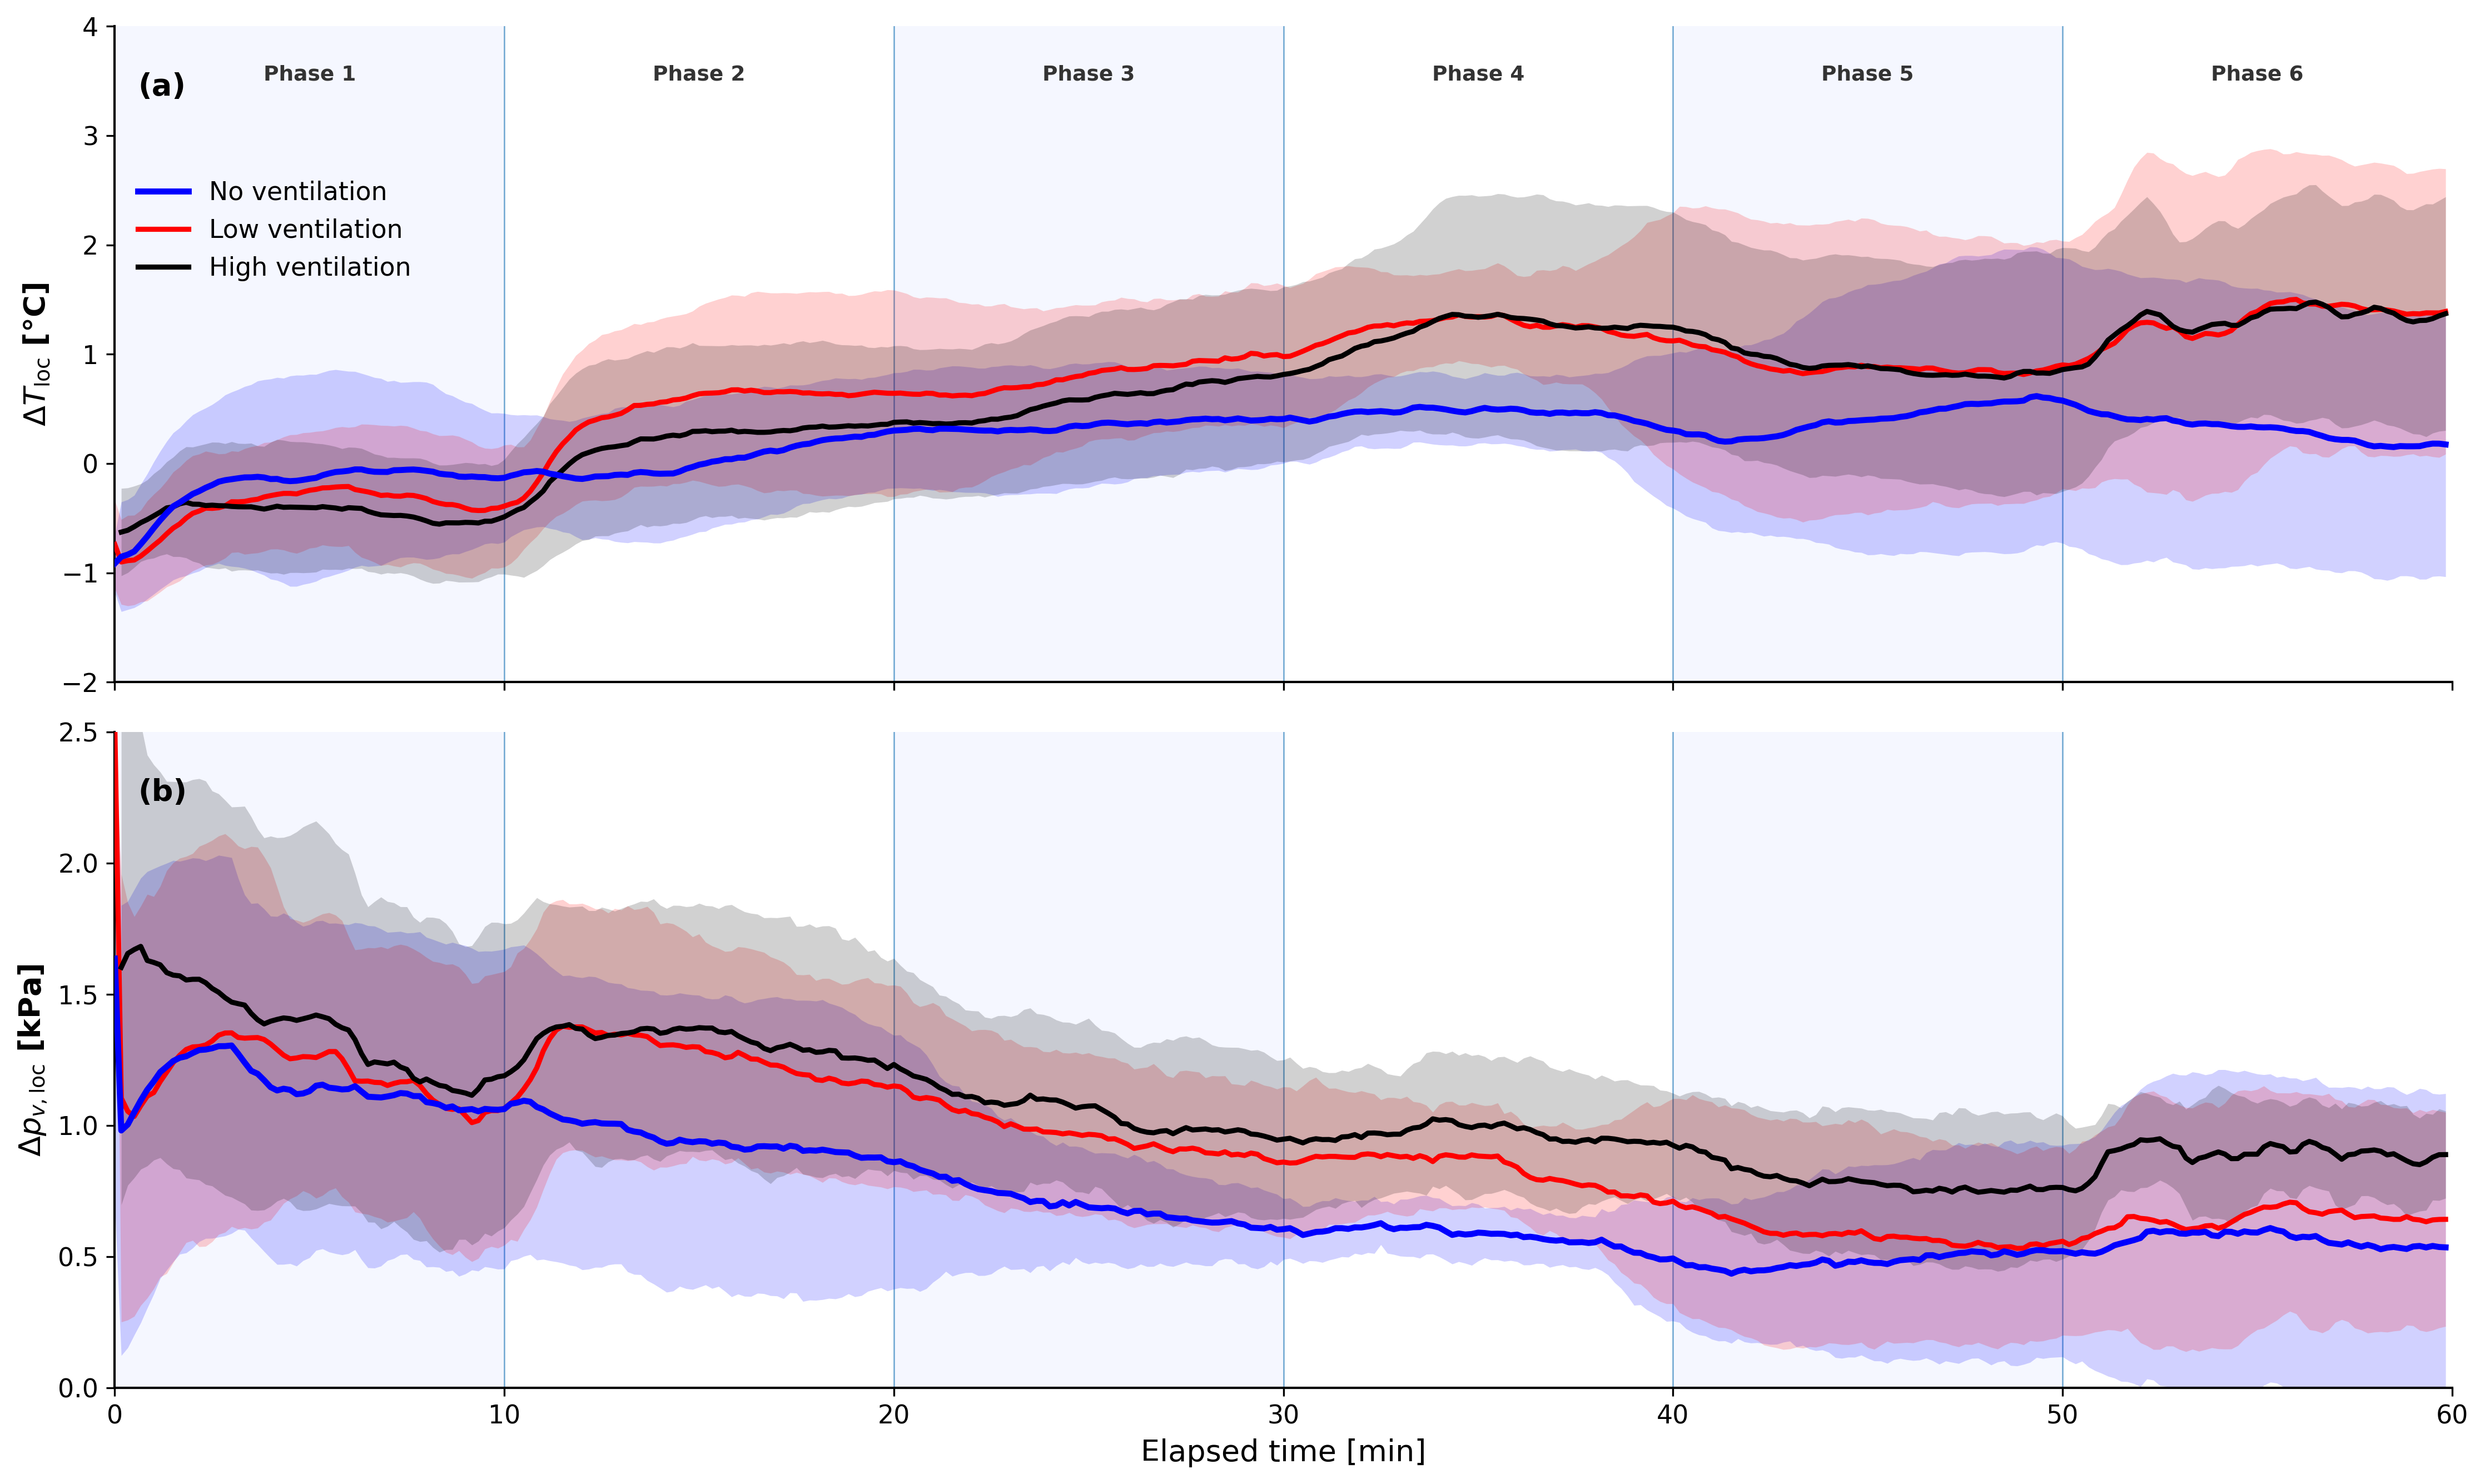

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# PATHS
# ============================================================

INPUT_PATH = (
    ROOT
    / "data"
    / "processed"
    / "analysis"
    / "analysis_wide_thermodynamics.csv"
)

OUTPUT_DIR = ROOT / "reports" / "9_humidity"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not INPUT_PATH.exists():
    raise FileNotFoundError(
        f"Thermodynamic dataset not found: {INPUT_PATH}\n"
        "Run the previous cell before generating the figure."
    )

print(f"Loading thermodynamic dataset from: {INPUT_PATH}")


# ============================================================
# LOAD AND CLEAN
# ============================================================

df = pd.read_csv(INPUT_PATH)

df["subject_id"] = (
    df["subject_id"]
    .astype(str)
    .str.strip()
)

df["condition"] = (
    df["condition"]
    .astype(str)
    .str.strip()
    .str.lower()
)

required_columns = [
    "subject_id",
    "condition",
    "elapsed_minutes_bin",
    "delta_T_loc",
    "delta_pv_loc",
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise KeyError(
        "Missing required columns in the thermodynamic dataset: "
        f"{missing_columns}"
    )

for column in [
    "elapsed_minutes_bin",
    "delta_T_loc",
    "delta_pv_loc",
]:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce",
    )


# ============================================================
# REMOVE INVALID OR TERMINAL TIME POINTS
# ============================================================

# Keep the experimental interval in the form [0, 60).
# The point exactly at 60 min is excluded because it lies outside
# the nominal acquisition window and may produce artificial spikes.
df = df.loc[
    (df["elapsed_minutes_bin"] >= 0)
    & (df["elapsed_minutes_bin"] < 60)
].copy()


# ============================================================
# DIAGNOSTICS
# ============================================================

print("\nConditions found:")

print(
    df["condition"]
    .value_counts(dropna=False)
)

print("\nSubjects contributing to each condition:")

print(
    df
    .groupby("condition")["subject_id"]
    .nunique()
)

print("\nSubjects contributing to delta_T_loc:")

print(
    df
    .dropna(subset=["delta_T_loc"])
    .groupby("condition")["subject_id"]
    .nunique()
)

print("\nSubjects contributing to delta_pv_loc:")

print(
    df
    .dropna(subset=["delta_pv_loc"])
    .groupby("condition")["subject_id"]
    .nunique()
)


# ============================================================
# SUBJECT-LEVEL TEMPORAL DATA
# ============================================================

# Average repeated observations within each subject, condition,
# and temporal bin before calculating across-subject statistics.
subject_time = (
    df
    .groupby(
        [
            "subject_id",
            "condition",
            "elapsed_minutes_bin",
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        delta_T_loc=(
            "delta_T_loc",
            "mean",
        ),
        delta_pv_loc=(
            "delta_pv_loc",
            "mean",
        ),
    )
)


# ============================================================
# ACROSS-SUBJECT MEAN AND STANDARD DEVIATION
# ============================================================

def calculate_time_statistics(data, variable):
    """
    Calculate the across-subject mean and standard deviation
    at each temporal bin.

    The ribbon limits are defined as mean +/- 1 standard deviation.
    """

    stats = (
        data
        .dropna(subset=[variable])
        .groupby(
            "elapsed_minutes_bin",
            observed=True,
        )[variable]
        .agg(
            mean="mean",
            std="std",
            n="count",
        )
        .reset_index()
        .sort_values("elapsed_minutes_bin")
    )

    if stats.empty:
        return stats

    # Standard deviation is undefined for fewer than two subjects.
    stats.loc[
        stats["n"] < 2,
        "std",
    ] = np.nan

    stats["lower_sd"] = (
        stats["mean"]
        - stats["std"]
    )

    stats["upper_sd"] = (
        stats["mean"]
        + stats["std"]
    )

    return stats


# ============================================================
# PLOT SETTINGS
# ============================================================

condition_order = [
    "no_wind",
    "wind_low",
    "wind_high",
]

condition_style = {
    "no_wind": {
        "color": "blue",
        "label": "No ventilation",
    },
    "wind_low": {
        "color": "red",
        "label": "Low ventilation",
    },
    "wind_high": {
        "color": "black",
        "label": "High ventilation",
    },
}

phases_info = [
    {
        "start": 0,
        "end": 10,
        "label": "Phase 1",
        "fill": True,
    },
    {
        "start": 10,
        "end": 20,
        "label": "Phase 2",
        "fill": False,
    },
    {
        "start": 20,
        "end": 30,
        "label": "Phase 3",
        "fill": True,
    },
    {
        "start": 30,
        "end": 40,
        "label": "Phase 4",
        "fill": False,
    },
    {
        "start": 40,
        "end": 50,
        "label": "Phase 5",
        "fill": True,
    },
    {
        "start": 50,
        "end": 60,
        "label": "Phase 6",
        "fill": False,
    },
]

plot_variables = [
    {
        "column": "delta_T_loc",
        "ylabel": r"$\Delta T_{\mathrm{loc}}$ [°C]",
        "panel_label": "(a)",
    },
    {
        "column": "delta_pv_loc",
        "ylabel": r"$\Delta p_{v,\mathrm{loc}}$ [kPa]",
        "panel_label": "(b)",
    },
]


# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(15, 9),
    dpi=300,
    sharex=True,
)


# ============================================================
# PHASE BACKGROUND
# ============================================================

for ax in axes:

    for phase in phases_info:

        if phase["fill"]:
            ax.axvspan(
                phase["start"],
                phase["end"],
                facecolor="#eff3ff",
                alpha=0.6,
                zorder=0,
            )

        if phase["end"] < 60:
            ax.axvline(
                phase["end"],
                color="#3182bd",
                linewidth=0.6,
                alpha=0.7,
                zorder=1,
            )


# ============================================================
# MEAN TRAJECTORIES AND +/- 1 STANDARD DEVIATION
# ============================================================

for ax, plot_info in zip(
    axes,
    plot_variables,
):

    variable = plot_info["column"]

    for condition in condition_order:

        condition_data = subject_time.loc[
            subject_time["condition"] == condition
        ].copy()

        stats = calculate_time_statistics(
            condition_data,
            variable,
        )

        if stats.empty:
            print(
                f"WARNING: no valid data for condition "
                f"'{condition}' and variable '{variable}'."
            )
            continue

        x = stats[
            "elapsed_minutes_bin"
        ].to_numpy(dtype=float)

        mean = stats[
            "mean"
        ].to_numpy(dtype=float)

        lower = stats[
            "lower_sd"
        ].to_numpy(dtype=float)

        upper = stats[
            "upper_sd"
        ].to_numpy(dtype=float)

        valid_sd = (
            np.isfinite(lower)
            & np.isfinite(upper)
        )

        if valid_sd.any():
            ax.fill_between(
                x,
                lower,
                upper,
                where=valid_sd,
                color=condition_style[condition]["color"],
                alpha=0.18,
                linewidth=0,
                interpolate=True,
                zorder=2,
            )

        line_zorder = (
            5
            if condition == "no_wind"
            else 4
        )

        line_width = (
            2.6
            if condition == "no_wind"
            else 2.2
        )

        ax.plot(
            x,
            mean,
            color=condition_style[condition]["color"],
            label=condition_style[condition]["label"],
            linewidth=line_width,
            zorder=line_zorder,
        )

    ax.set_ylabel(
        plot_info["ylabel"],
        fontsize=13,
        fontweight="bold",
    )

    ax.text(
        0.01,
        0.93,
        plot_info["panel_label"],
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold",
        va="top",
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(1.0)
    ax.spines["bottom"].set_linewidth(1.0)

    ax.tick_params(
        axis="both",
        labelsize=11,
    )


# ============================================================
# MANUAL AXIS LIMITS
# ============================================================

# Panel (a): local temperature difference
axes[0].set_ylim(
    -2.0,
    4.0,
)

axes[0].set_yticks(
    np.arange(
        -2.0,
        4.1,
        1.0,
    )
)

# Panel (b): local vapour-pressure difference
axes[1].set_ylim(
    0.0,
    2.5,
)

axes[1].set_yticks(
    np.arange(
        0.0,
        2.51,
        0.5,
    )
)


# ============================================================
# PHASE LABELS
# ============================================================

top_ax = axes[0]

# Position labels inside the manually defined axis range.
phase_label_y = 3.65

for phase in phases_info:

    x_center = (
        phase["start"]
        + phase["end"]
    ) / 2

    top_ax.text(
        x_center,
        phase_label_y,
        phase["label"],
        ha="center",
        va="top",
        fontsize=9,
        fontweight="bold",
        color="#333333",
    )


# ============================================================
# FINAL FORMATTING
# ============================================================

axes[-1].set_xlabel(
    "Elapsed time [min]",
    fontsize=13,
)

axes[-1].set_xlim(
    0,
    60,
)

axes[-1].set_xticks(
    np.arange(
        0,
        61,
        10,
    )
)


# ============================================================
# LEGEND
# ============================================================

handles, labels = (
    axes[0]
    .get_legend_handles_labels()
)

legend_order = [
    labels.index(
        condition_style[condition]["label"]
    )
    for condition in condition_order
    if condition_style[condition]["label"] in labels
]

axes[0].legend(
    [
        handles[index]
        for index in legend_order
    ],
    [
        labels[index]
        for index in legend_order
    ],
    loc="upper left",
    bbox_to_anchor=(0, 0.8),
    frameon=False,
    fontsize=11,
    ncol=1,
)


# ============================================================
# SAVE
# ============================================================

plt.tight_layout()

output_path = (
    OUTPUT_DIR
    / "paper_thermohygrometric_driving_forces_sd.png"
)

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

print(f"\nFigure saved to: {output_path}")

plt.show()

Loading dataset from: /home/eleonorab/repository/convective_cooling/data/processed/analysis/analysis_wide_thermodynamics.csv

Subjects by condition:
condition
no_wind      10
wind_high     8
wind_low     10
Name: subject_id, dtype: int64

Valid observations:
delta_T_loc     9699
delta_pv_loc    9699
dT_dorsal_dt    9846
dtype: int64

Common outcome window within each phase: 300–600 s

Lagged OLS results saved to:
/home/eleonorab/repository/convective_cooling/reports/9_humidity/lagged_regression/lagged_ols_results_common_window.csv

Sample-size consistency check:
analysis_level analysis_group  minimum_n  maximum_n  minimum_subjects  maximum_subjects  constant_n
     condition        no_wind       1781       1787                10                10       False
     condition      wind_high       1423       1431                 8                 8       False
     condition       wind_low       1602       1609                 9                 9       False
       overall            all  

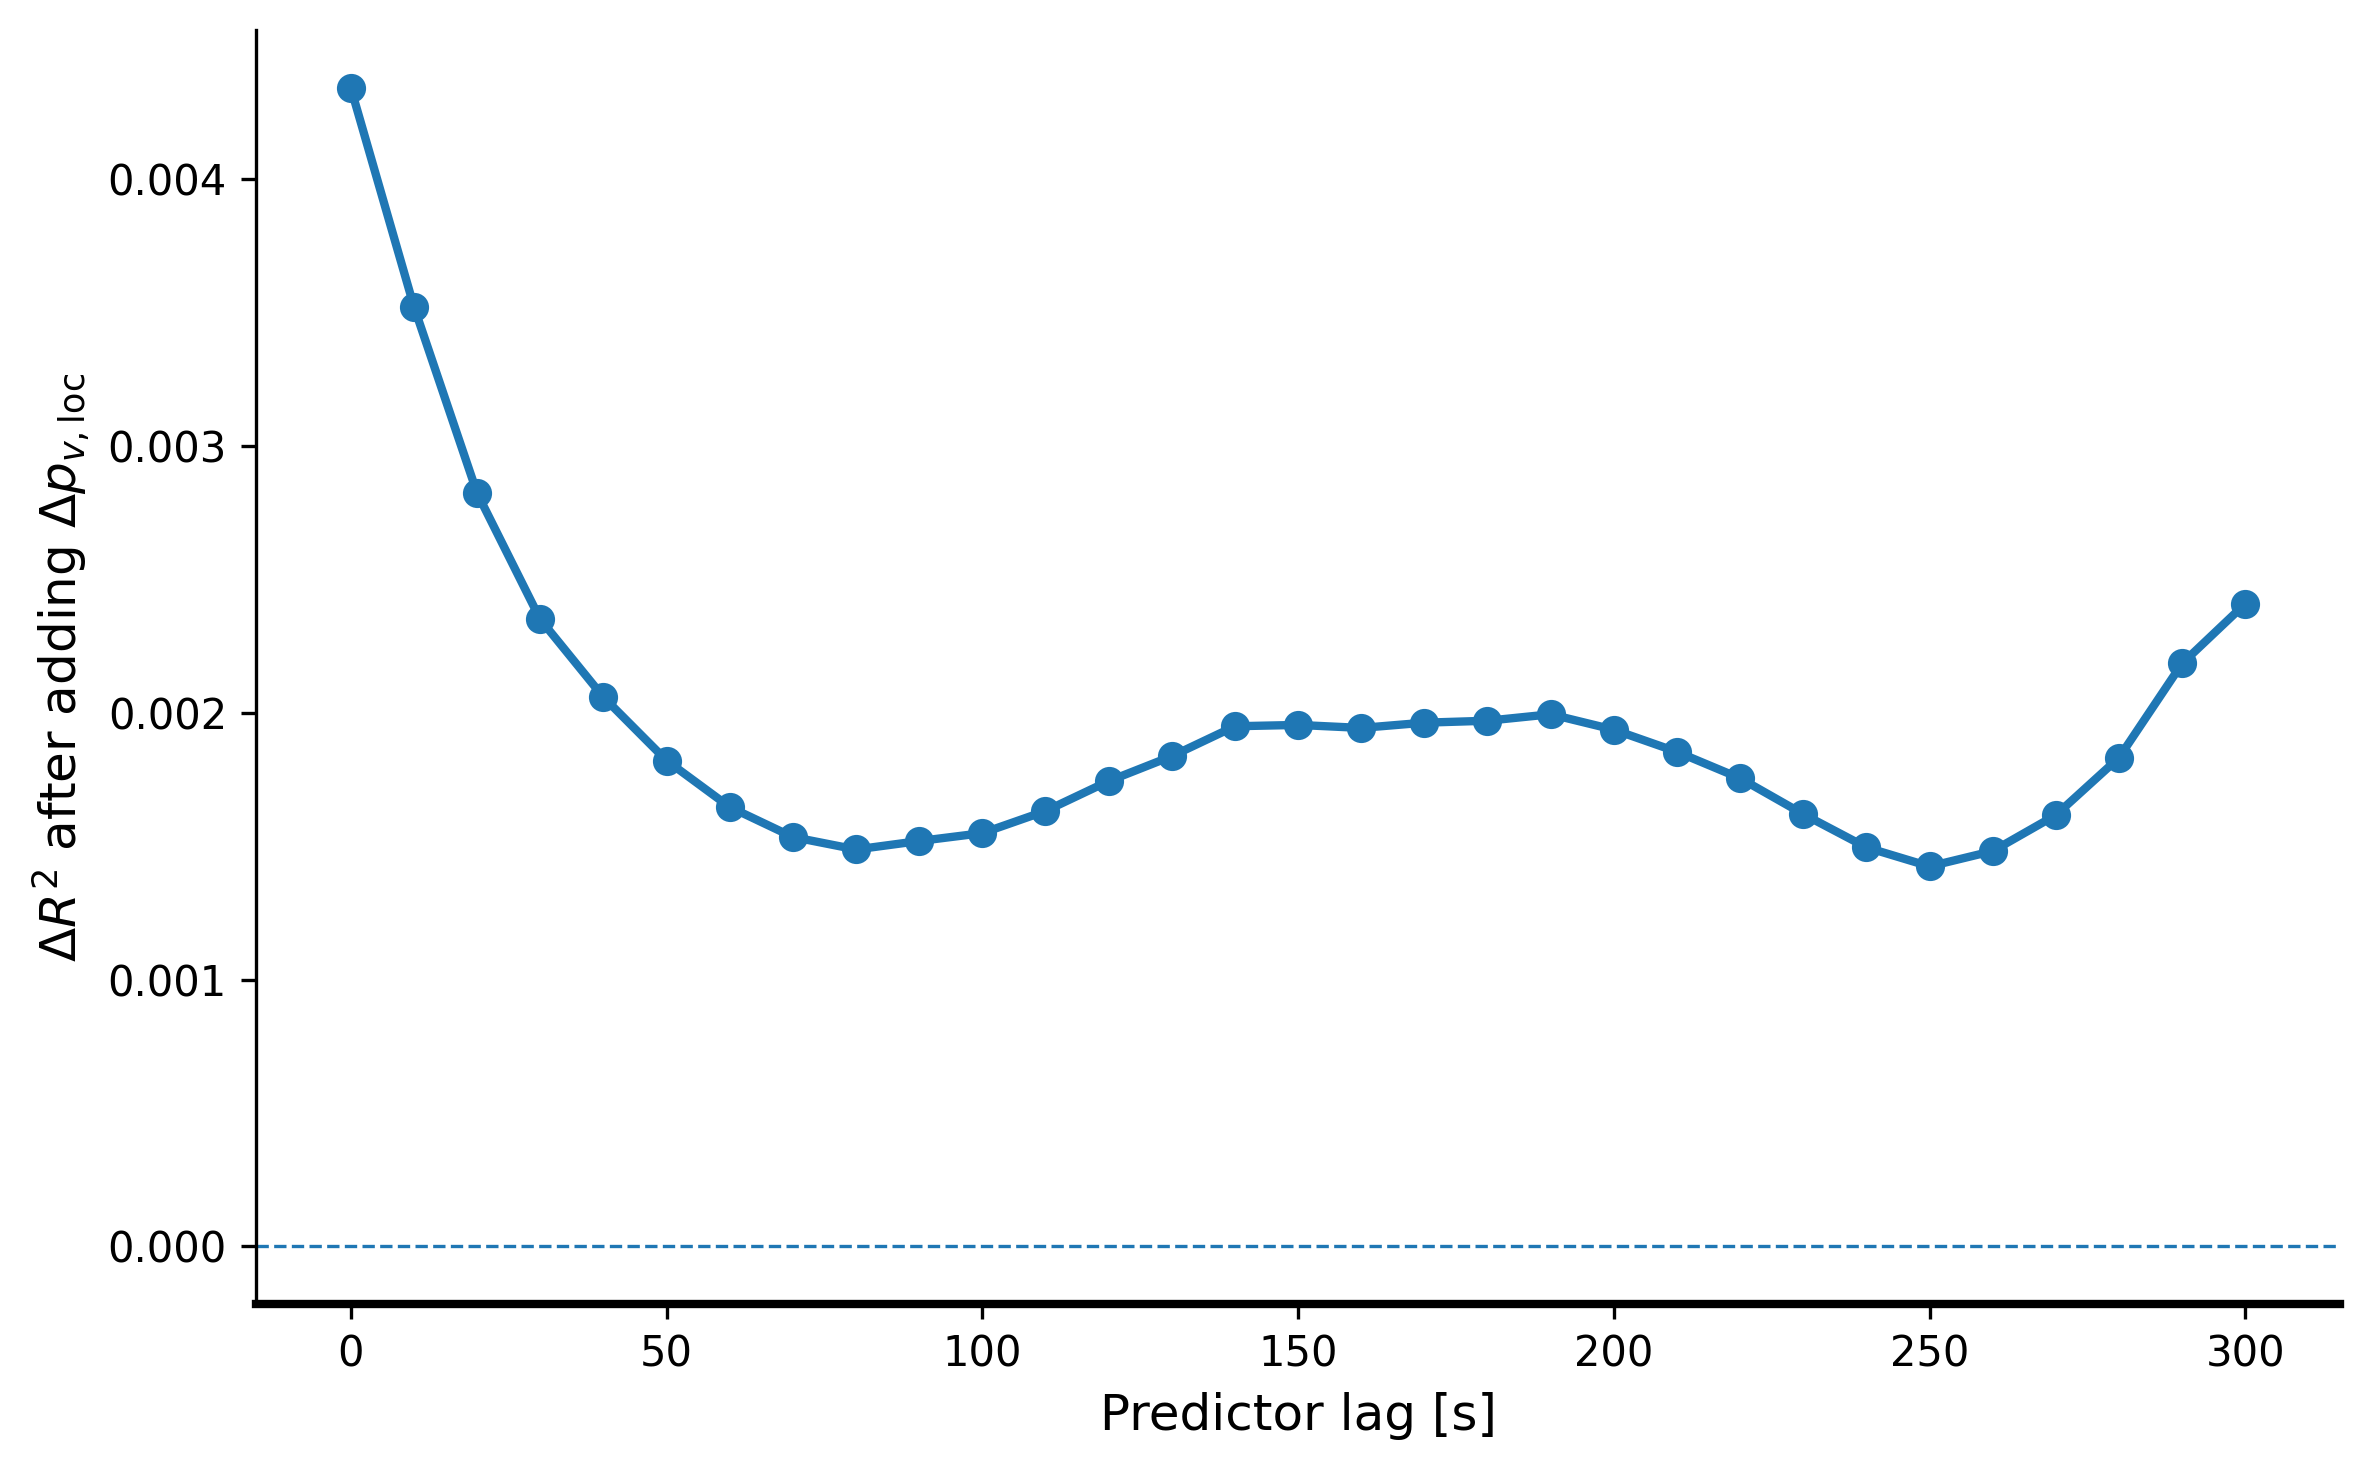

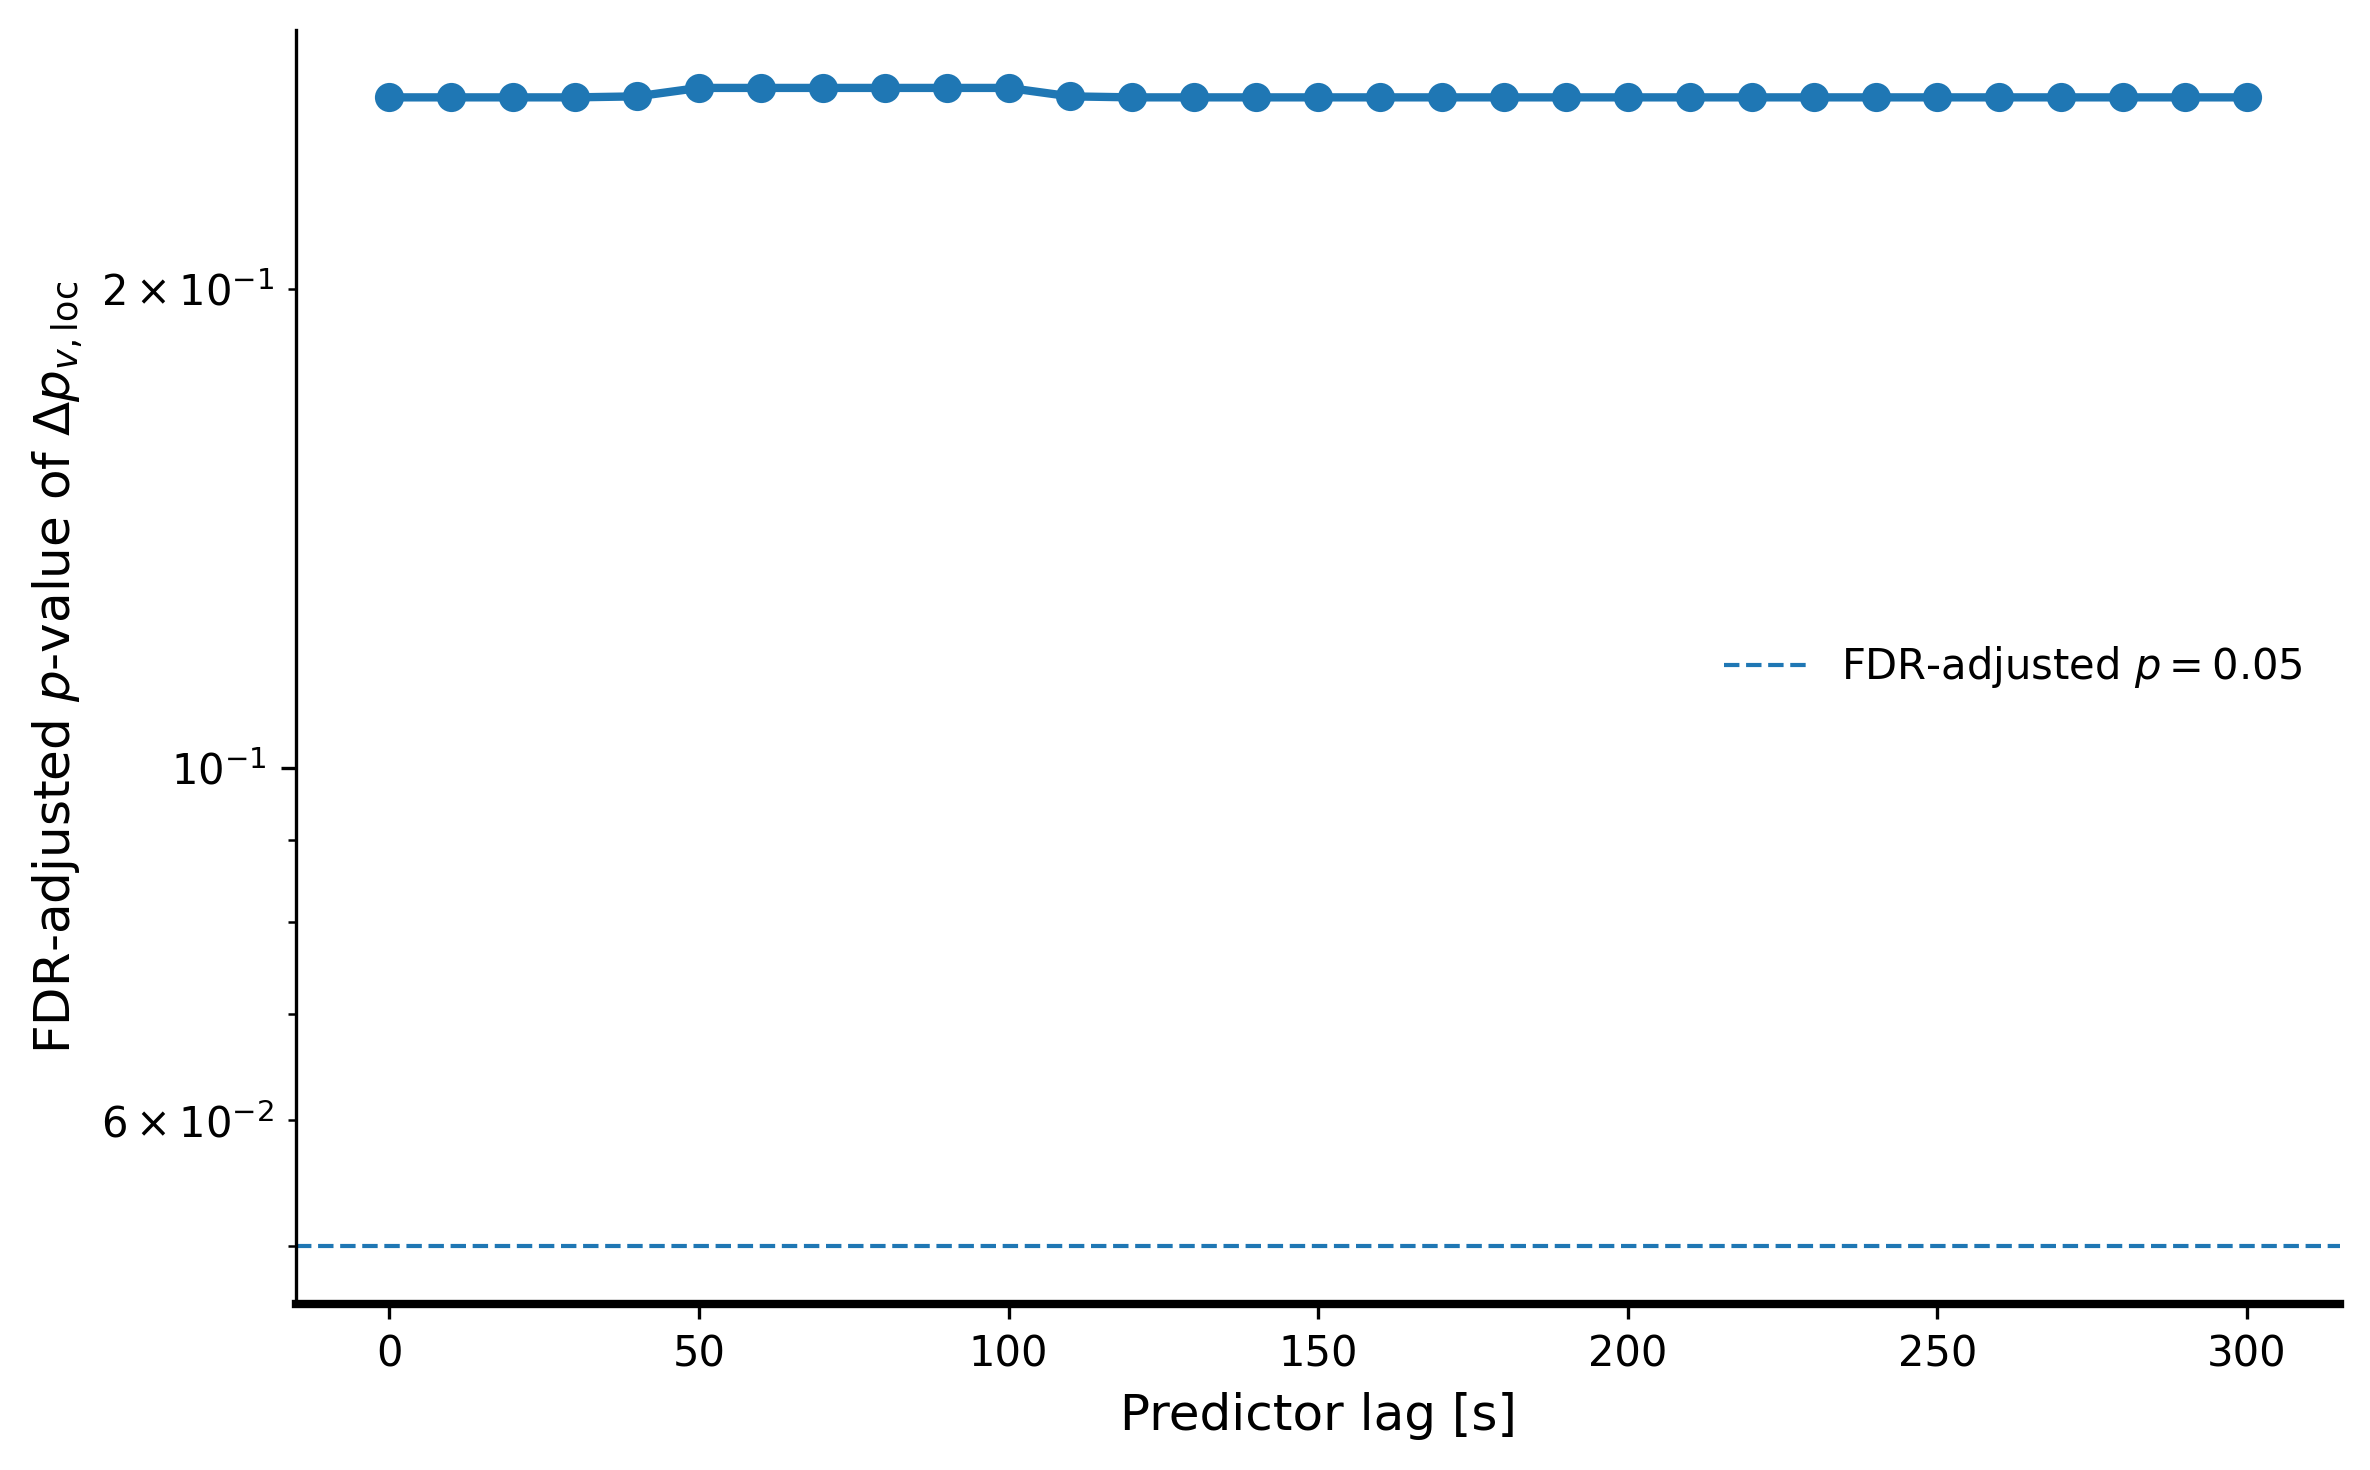

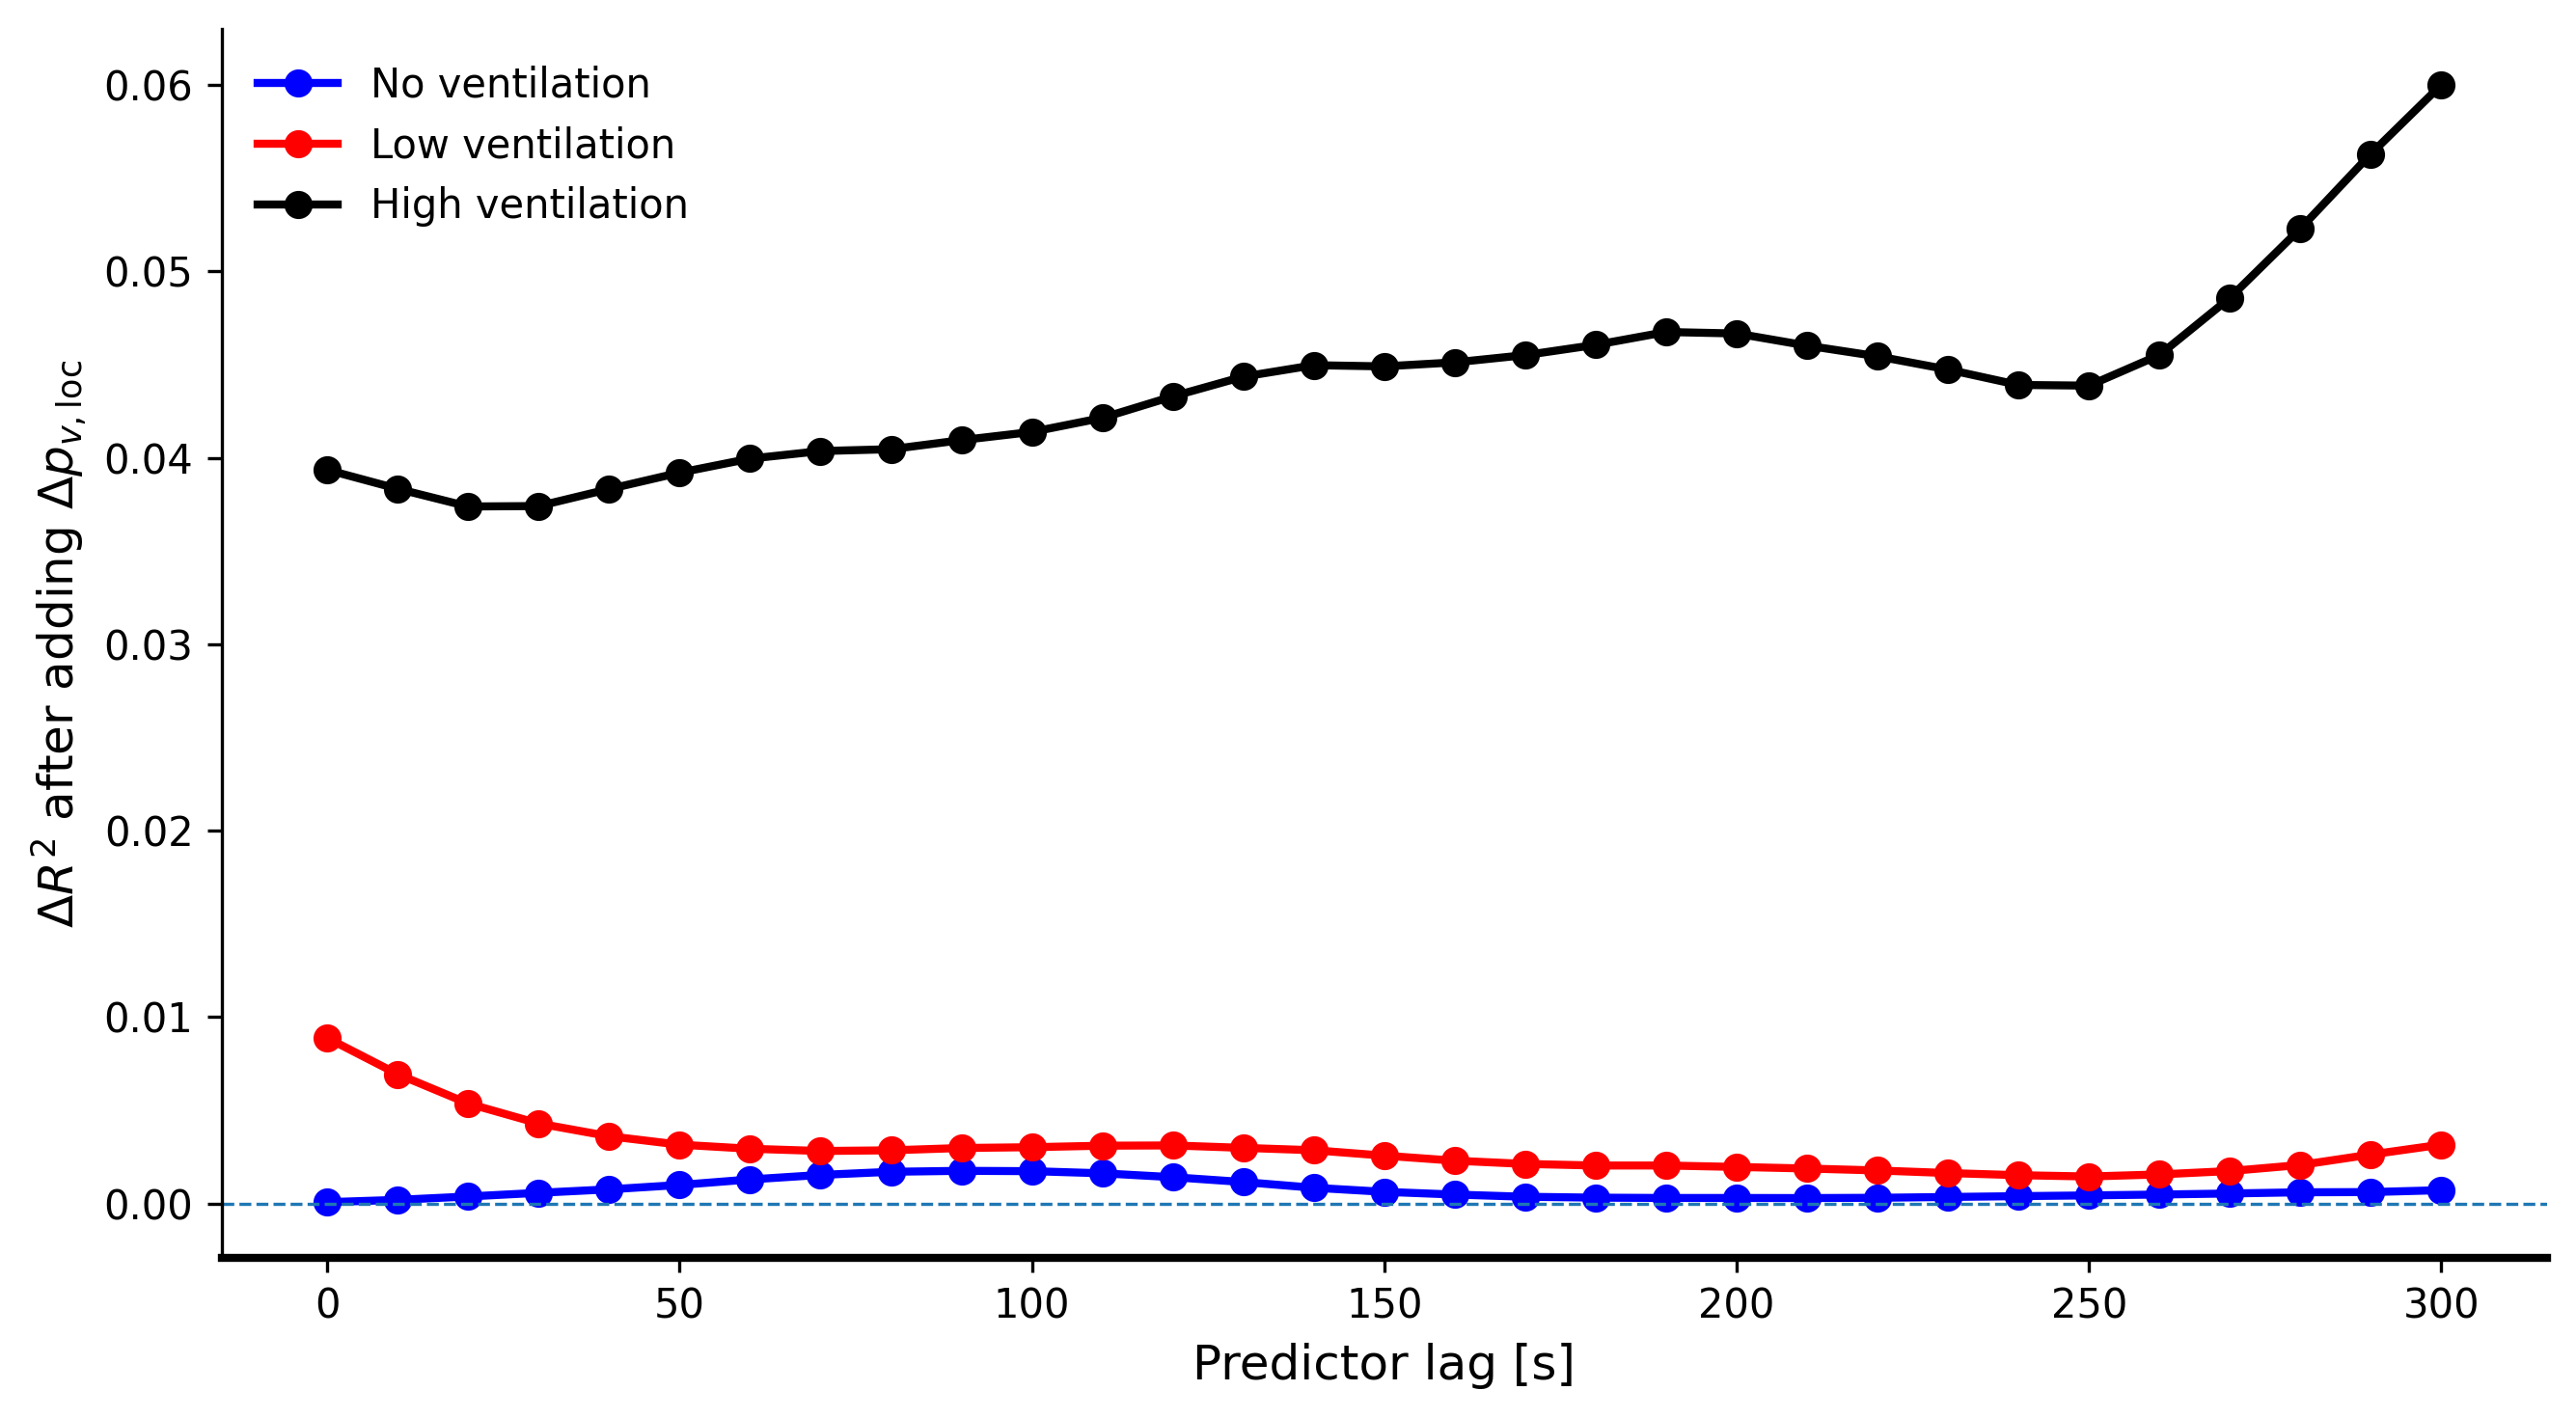

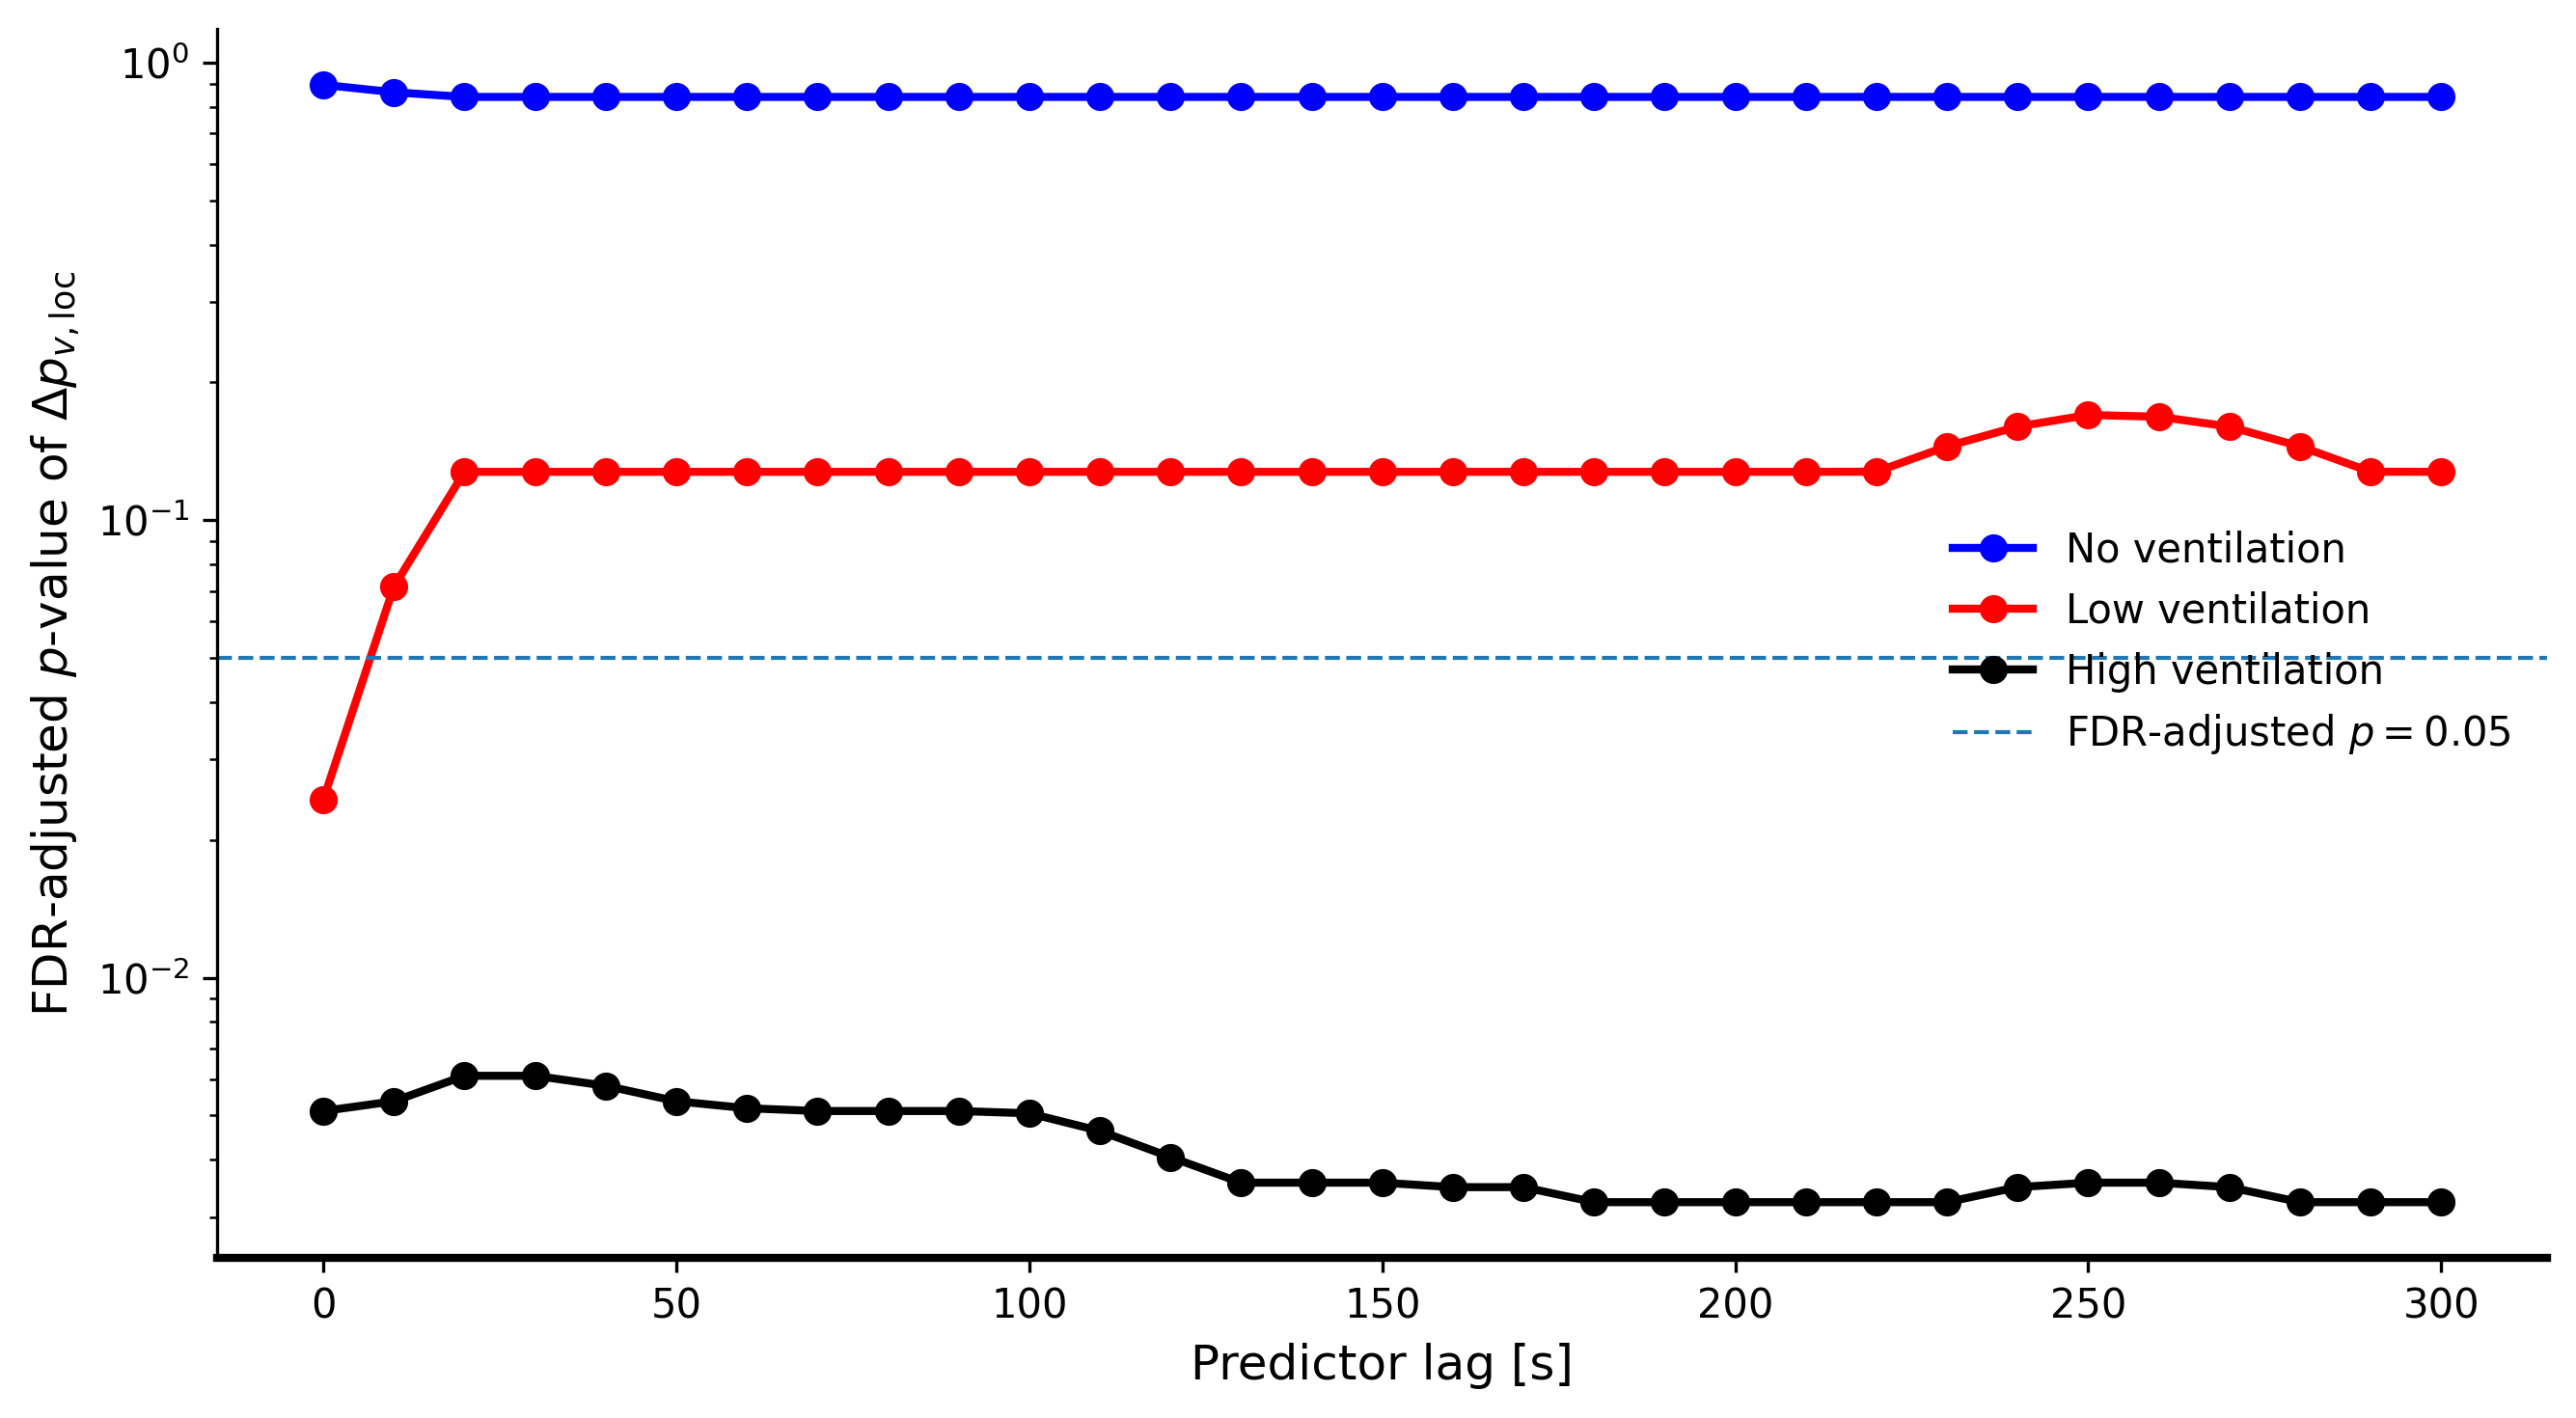

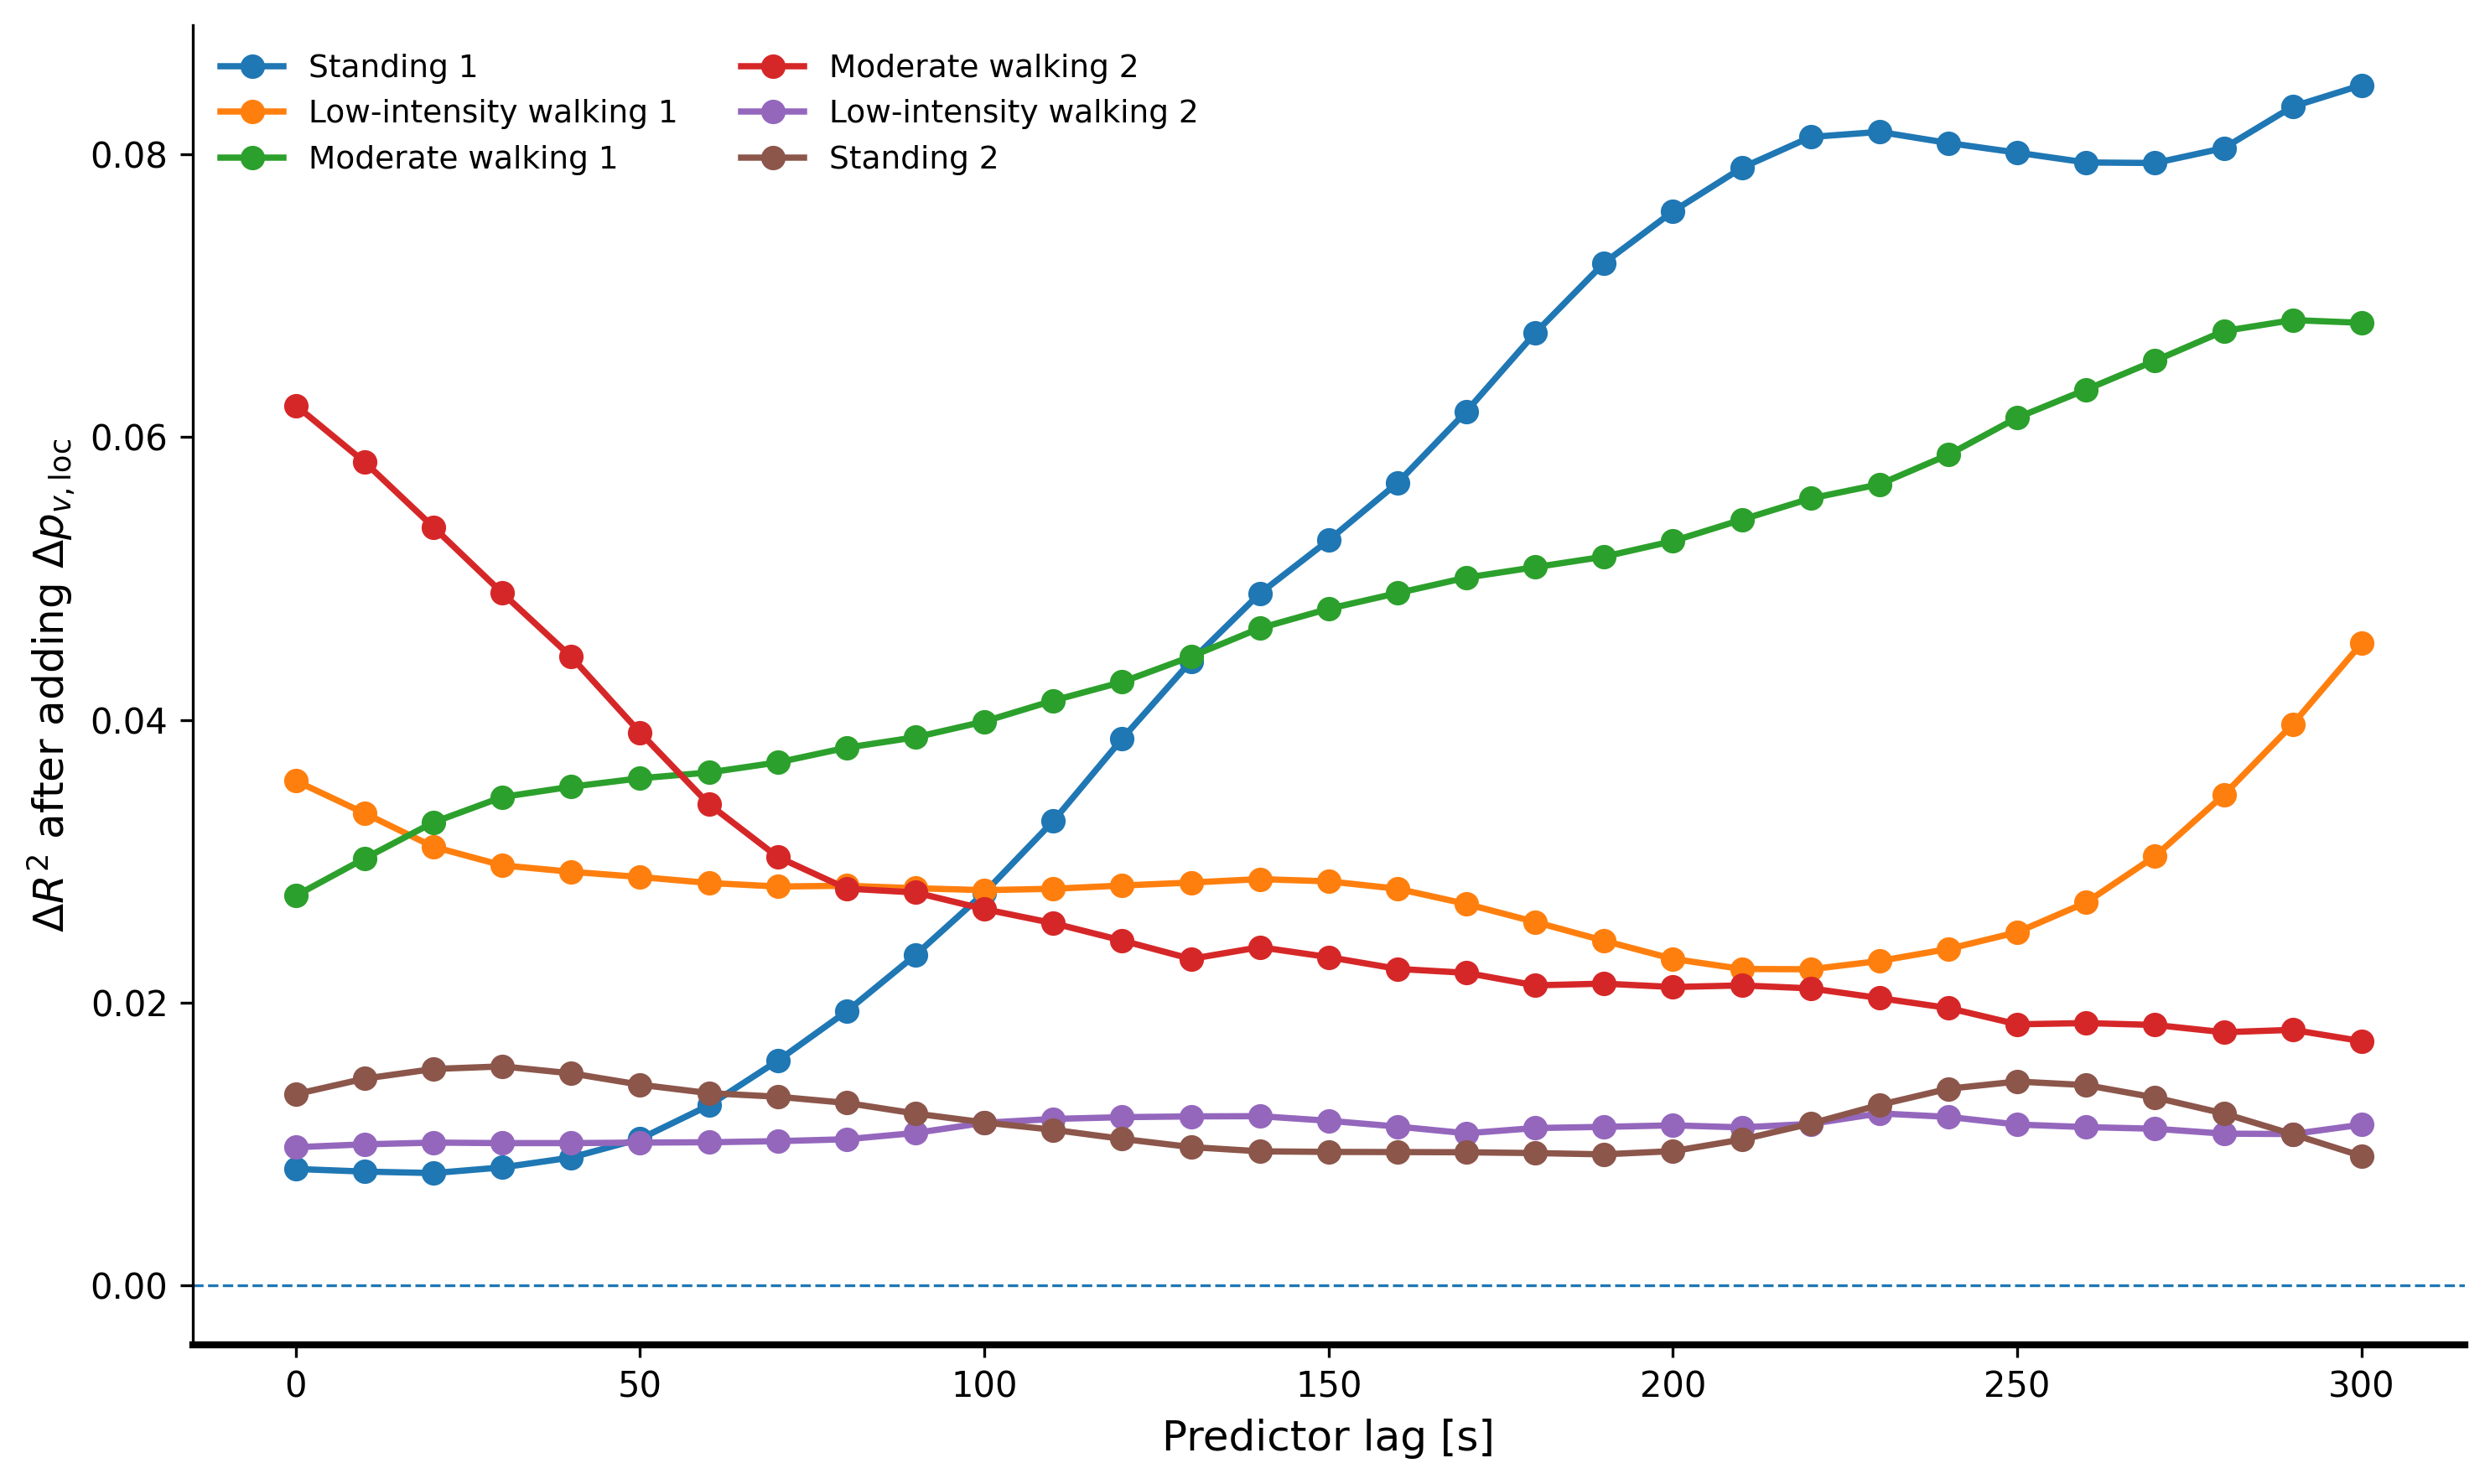

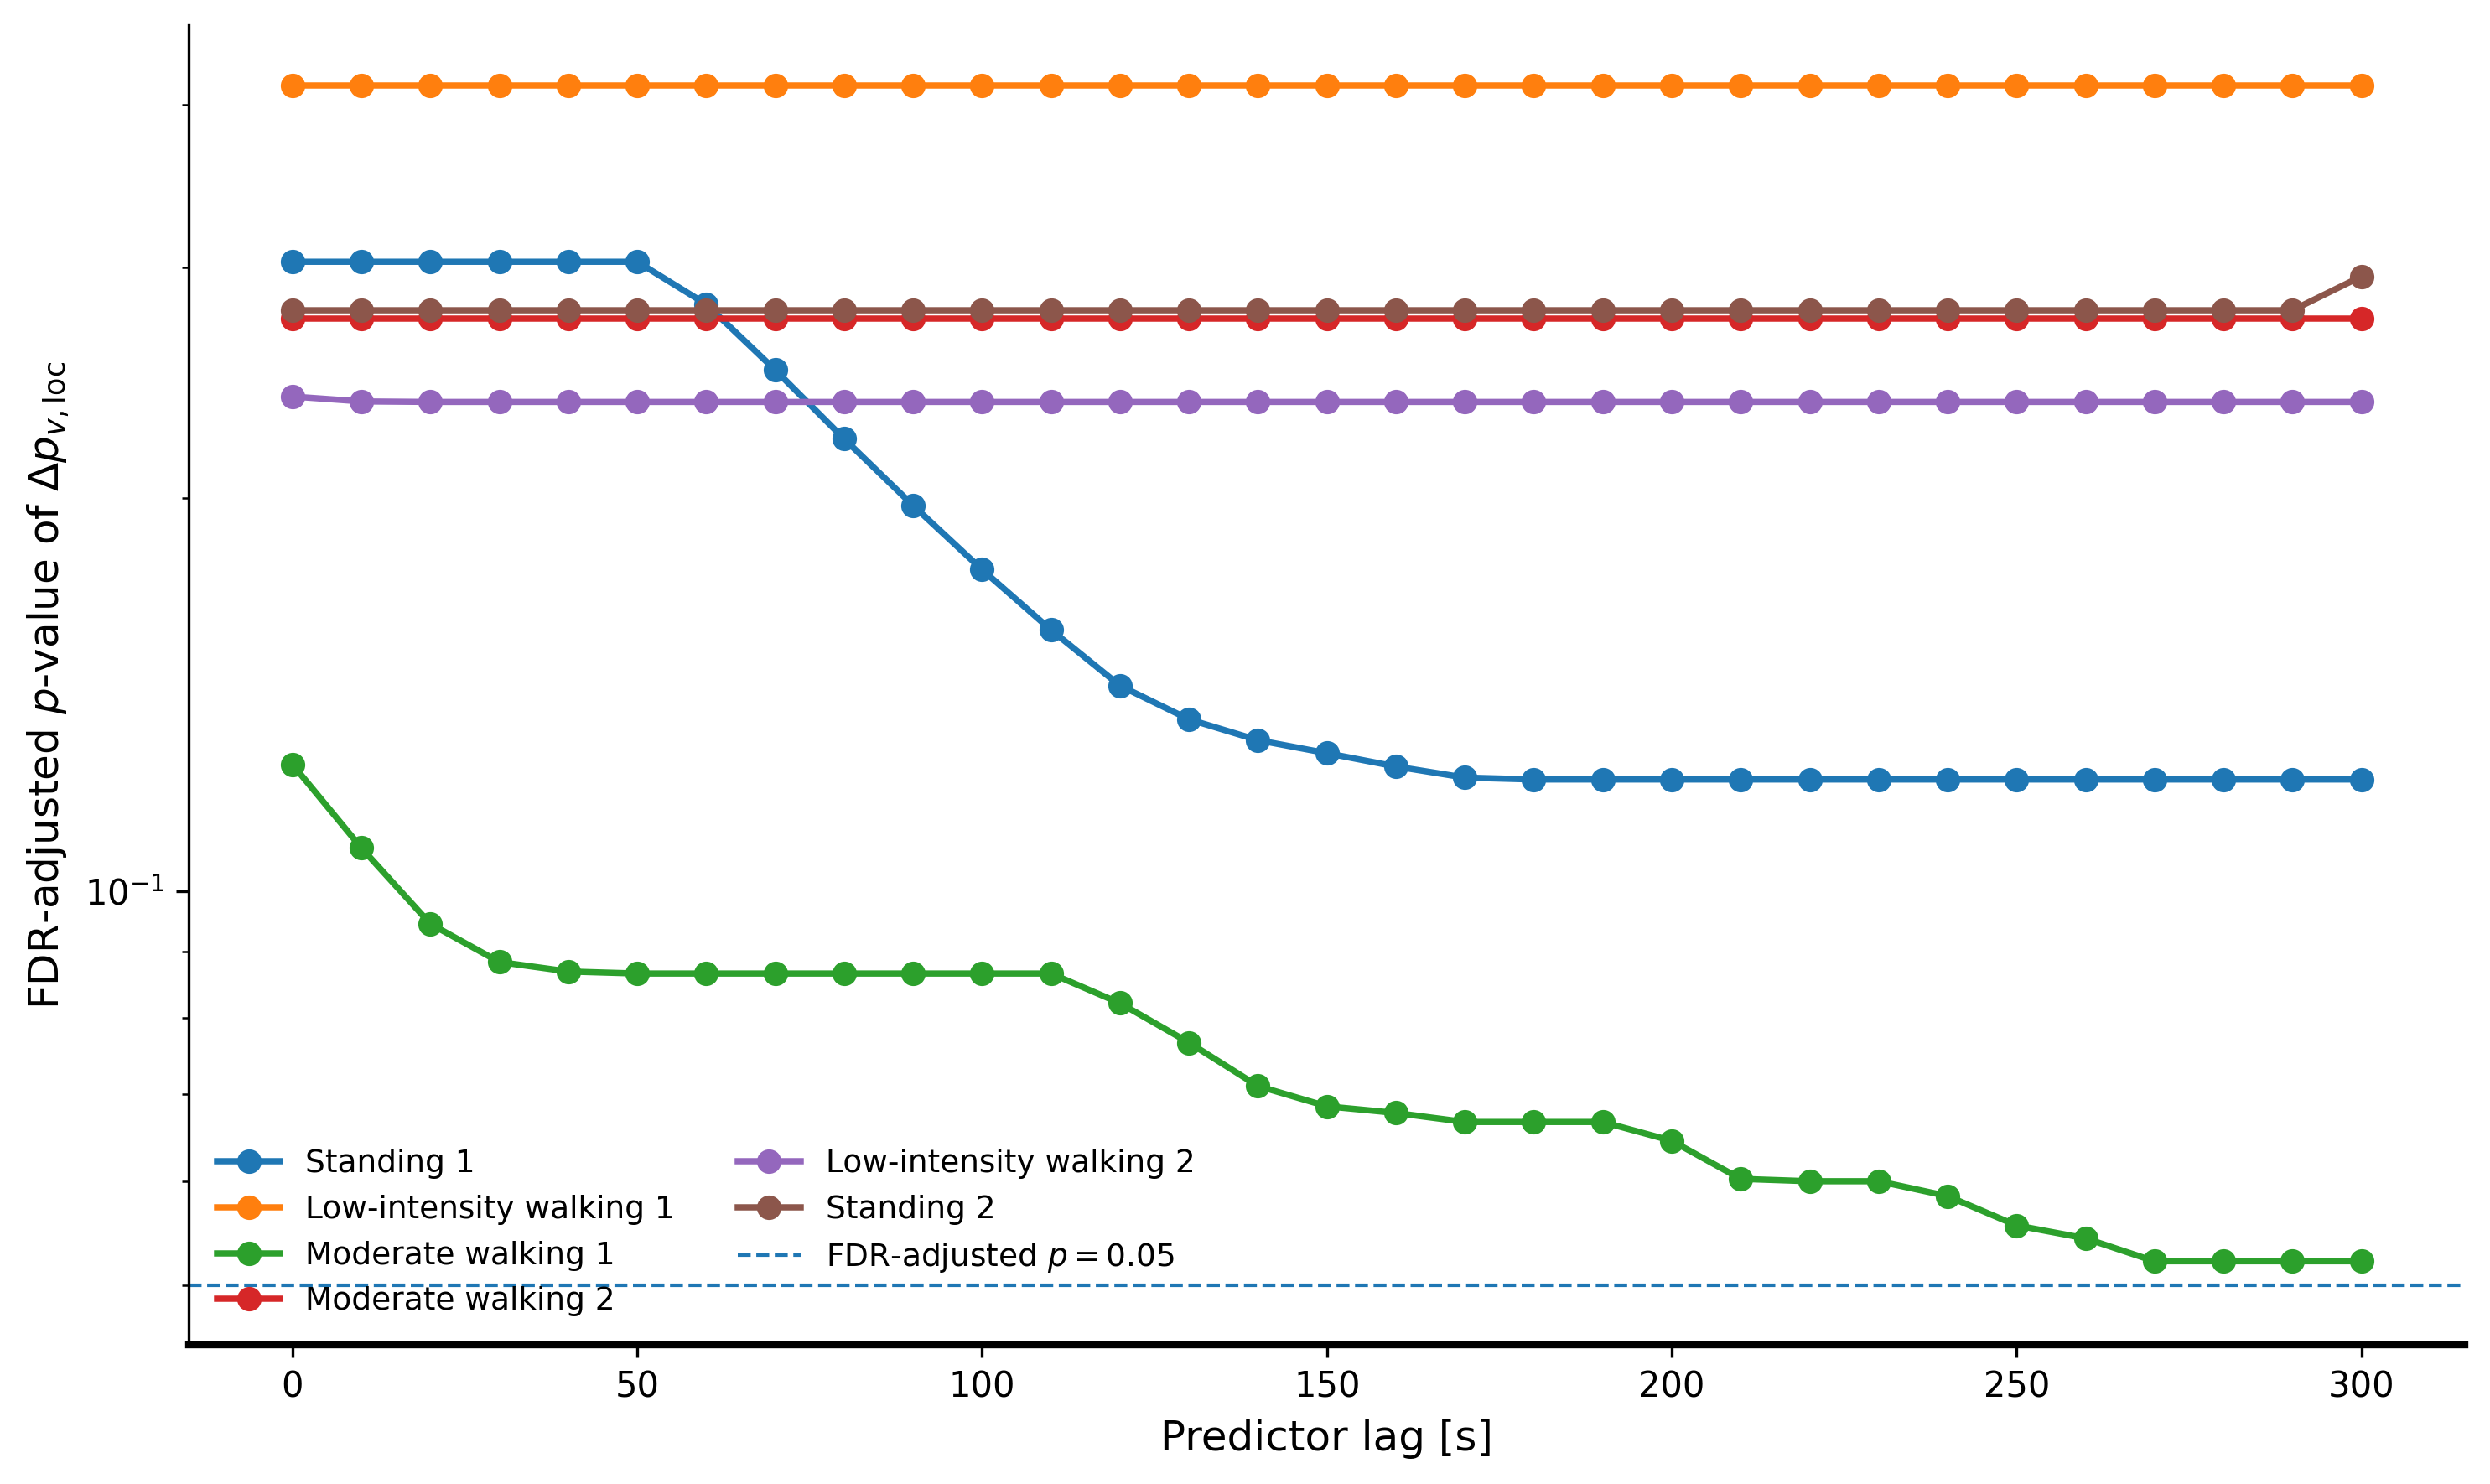

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.stats.multitest import multipletests


# ============================================================
# PATHS
# ============================================================

INPUT_PATH = (
    ROOT
    / "data"
    / "processed"
    / "analysis"
    / "analysis_wide_thermodynamics.csv"
)

OUTPUT_DIR = (
    ROOT
    / "reports"
    / "9_humidity"
    / "lagged_regression"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

if not INPUT_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {INPUT_PATH}"
    )

print(f"Loading dataset from: {INPUT_PATH}")


# ============================================================
# SETTINGS
# ============================================================

# Temporal resolution of the regularized dataset
TIME_STEP_SECONDS = 10

# Tested predictor delays: 0–300 s
LAGS_SECONDS = np.arange(
    0,
    301,
    TIME_STEP_SECONDS,
)

MAX_LAG_SECONDS = int(
    LAGS_SECONDS.max()
)

CONDITION_ORDER = [
    "no_wind",
    "wind_low",
    "wind_high",
]

CONDITION_LABELS = {
    "no_wind": "No ventilation",
    "wind_low": "Low ventilation",
    "wind_high": "High ventilation",
}

CONDITION_COLORS = {
    "no_wind": "blue",
    "wind_low": "red",
    "wind_high": "black",
}

PHASE_ORDER = [
    "phase_1",
    "phase_2",
    "phase_3",
    "phase_4",
    "phase_5",
    "phase_6",
]

PHASE_LABELS = {
    "phase_1": "Standing 1",
    "phase_2": "Low-intensity walking 1",
    "phase_3": "Moderate walking 1",
    "phase_4": "Moderate walking 2",
    "phase_5": "Low-intensity walking 2",
    "phase_6": "Standing 2",
}

PHASE_START_SECONDS = {
    "phase_1": 0,
    "phase_2": 600,
    "phase_3": 1200,
    "phase_4": 1800,
    "phase_5": 2400,
    "phase_6": 3000,
}


# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(INPUT_PATH)

required_columns = [
    "subject_id",
    "condition",
    "elapsed_seconds_bin",
    "elapsed_minutes_bin",
    "delta_T_loc",
    "delta_pv_loc",
    "dT_dorsal_dt",
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise KeyError(
        "Missing required columns: "
        f"{missing_columns}"
    )


# ============================================================
# BASIC CLEANING
# ============================================================

df["subject_id"] = (
    df["subject_id"]
    .astype(str)
    .str.strip()
)

df["condition"] = (
    df["condition"]
    .astype(str)
    .str.strip()
    .str.lower()
)

numeric_columns = [
    "elapsed_seconds_bin",
    "elapsed_minutes_bin",
    "delta_T_loc",
    "delta_pv_loc",
    "dT_dorsal_dt",
]

for column in numeric_columns:

    df[column] = pd.to_numeric(
        df[column],
        errors="coerce",
    )

# Keep the experimental window [0, 60 min)
df = df.loc[
    (df["elapsed_minutes_bin"] >= 0)
    & (df["elapsed_minutes_bin"] < 60)
].copy()

df = (
    df
    .sort_values(
        [
            "subject_id",
            "condition",
            "elapsed_seconds_bin",
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# PHASE ASSIGNMENT
# ============================================================

def assign_phase(elapsed_minutes):

    if 0 <= elapsed_minutes < 10:
        return "phase_1"

    if 10 <= elapsed_minutes < 20:
        return "phase_2"

    if 20 <= elapsed_minutes < 30:
        return "phase_3"

    if 30 <= elapsed_minutes < 40:
        return "phase_4"

    if 40 <= elapsed_minutes < 50:
        return "phase_5"

    if 50 <= elapsed_minutes < 60:
        return "phase_6"

    return np.nan


df["phase"] = (
    df["elapsed_minutes_bin"]
    .apply(assign_phase)
)

df["phase_start_seconds"] = (
    df["phase"]
    .map(PHASE_START_SECONDS)
)

df["seconds_from_phase_start"] = (
    df["elapsed_seconds_bin"]
    - df["phase_start_seconds"]
)


# ============================================================
# REMOVE NON-FINITE VALUES
# ============================================================

for column in [
    "delta_T_loc",
    "delta_pv_loc",
    "dT_dorsal_dt",
]:

    df.loc[
        ~np.isfinite(df[column]),
        column,
    ] = np.nan


# ============================================================
# DERIVATIVE OUTLIER FILTER
# ============================================================

def filter_derivative_outliers(group):
    """
    Remove the extreme 1% tails of dT/dt separately for each
    subject and experimental condition.
    """

    group = group.copy()

    valid = (
        group["dT_dorsal_dt"]
        .dropna()
    )

    if len(valid) < 20:
        return group

    lower = valid.quantile(0.01)
    upper = valid.quantile(0.99)

    outlier_mask = (
        (group["dT_dorsal_dt"] < lower)
        | (group["dT_dorsal_dt"] > upper)
    )

    group.loc[
        outlier_mask,
        "dT_dorsal_dt",
    ] = np.nan

    return group


# Explicit loop avoids DataFrameGroupBy.apply deprecation warnings.
filtered_groups = []

for _, group in df.groupby(
    [
        "subject_id",
        "condition",
    ],
    observed=True,
    sort=False,
):

    filtered_groups.append(
        filter_derivative_outliers(group)
    )

df = (
    pd.concat(
        filtered_groups,
        ignore_index=True,
    )
    .sort_values(
        [
            "subject_id",
            "condition",
            "elapsed_seconds_bin",
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# DIAGNOSTICS
# ============================================================

print("\nSubjects by condition:")

print(
    df.groupby(
        "condition",
        observed=True,
    )["subject_id"]
    .nunique()
)

print("\nValid observations:")

print(
    df[
        [
            "delta_T_loc",
            "delta_pv_loc",
            "dT_dorsal_dt",
        ]
    ]
    .count()
)

print(
    "\nCommon outcome window within each phase: "
    f"{MAX_LAG_SECONDS}–600 s"
)


# ============================================================
# CREATE LAGGED PREDICTORS
# ============================================================

def create_lagged_dataset(
    data,
    lag_seconds,
    preserve_phase=True,
    common_window_seconds=None,
):
    """
    Create lagged predictors such that values measured at
    t - lag predict dT/dt at time t.

    Lagged variables are created before the common-window filter,
    ensuring that observations from the first part of each phase
    remain available as predictors.

    Parameters
    ----------
    data : pandas.DataFrame
        Temporal dataset.

    lag_seconds : int
        Predictor delay in seconds.

    preserve_phase : bool
        Prevent lagged predictors from crossing phase boundaries.

    common_window_seconds : int or None
        Earliest outcome time retained within each phase.
        Setting this to the maximum tested lag ensures that every
        lag is evaluated on the same outcome timestamps.
    """

    if lag_seconds % TIME_STEP_SECONDS != 0:
        raise ValueError(
            "lag_seconds must be a multiple of "
            f"{TIME_STEP_SECONDS}."
        )

    lag_steps = (
        lag_seconds
        // TIME_STEP_SECONDS
    )

    lagged = (
        data
        .sort_values(
            [
                "subject_id",
                "condition",
                "elapsed_seconds_bin",
            ]
        )
        .copy()
    )

    group_columns = [
        "subject_id",
        "condition",
    ]

    if preserve_phase:
        group_columns.append("phase")

    lagged["delta_T_loc_lagged"] = (
        lagged
        .groupby(
            group_columns,
            observed=True,
            sort=False,
        )["delta_T_loc"]
        .shift(lag_steps)
    )

    lagged["delta_pv_loc_lagged"] = (
        lagged
        .groupby(
            group_columns,
            observed=True,
            sort=False,
        )["delta_pv_loc"]
        .shift(lag_steps)
    )

    lagged["lag_seconds"] = lag_seconds

    # Apply the common outcome window only after creating lagged
    # predictors.
    if common_window_seconds is not None:

        lagged = lagged.loc[
            lagged["seconds_from_phase_start"]
            >= common_window_seconds
        ].copy()

    return lagged


# ============================================================
# FIT NESTED OLS MODELS
# ============================================================

def fit_nested_models(
    data,
    lag_seconds,
    analysis_level,
    analysis_group,
):
    """
    Fit two nested models:

    Model 1:
        dT/dt ~ delta_T

    Model 2:
        dT/dt ~ delta_T + delta_pv

    Standard errors are clustered by subject.
    """

    regression_data = (
        data
        .dropna(
            subset=[
                "subject_id",
                "dT_dorsal_dt",
                "delta_T_loc_lagged",
                "delta_pv_loc_lagged",
            ]
        )
        .copy()
    )

    n_observations = len(
        regression_data
    )

    n_subjects = (
        regression_data["subject_id"]
        .nunique()
    )

    empty_result = {
        "analysis_level": analysis_level,
        "analysis_group": analysis_group,
        "lag_seconds": lag_seconds,
        "n_observations": n_observations,
        "n_subjects": n_subjects,
        "r2_sensible": np.nan,
        "r2_coupled": np.nan,
        "delta_r2": np.nan,
        "aic_sensible": np.nan,
        "aic_coupled": np.nan,
        "delta_aic": np.nan,
        "beta_delta_T": np.nan,
        "p_delta_T": np.nan,
        "beta_delta_pv": np.nan,
        "p_delta_pv": np.nan,
    }

    if (
        n_observations < 20
        or n_subjects < 2
    ):
        return empty_result

    y = regression_data[
        "dT_dorsal_dt"
    ]

    X_sensible = sm.add_constant(
        regression_data[
            [
                "delta_T_loc_lagged",
            ]
        ],
        has_constant="add",
    )

    X_coupled = sm.add_constant(
        regression_data[
            [
                "delta_T_loc_lagged",
                "delta_pv_loc_lagged",
            ]
        ],
        has_constant="add",
    )

    try:

        model_sensible = sm.OLS(
            y,
            X_sensible,
        ).fit(
            cov_type="cluster",
            cov_kwds={
                "groups":
                    regression_data["subject_id"],
            },
        )

        model_coupled = sm.OLS(
            y,
            X_coupled,
        ).fit(
            cov_type="cluster",
            cov_kwds={
                "groups":
                    regression_data["subject_id"],
            },
        )

    except Exception as error:

        print(
            f"WARNING: model failed for "
            f"{analysis_level}={analysis_group}, "
            f"lag={lag_seconds} s: {error}"
        )

        return empty_result

    return {
        "analysis_level": analysis_level,
        "analysis_group": analysis_group,
        "lag_seconds": lag_seconds,
        "n_observations": n_observations,
        "n_subjects": n_subjects,

        "r2_sensible":
            model_sensible.rsquared,

        "r2_coupled":
            model_coupled.rsquared,

        "delta_r2": (
            model_coupled.rsquared
            - model_sensible.rsquared
        ),

        "aic_sensible":
            model_sensible.aic,

        "aic_coupled":
            model_coupled.aic,

        "delta_aic": (
            model_coupled.aic
            - model_sensible.aic
        ),

        "beta_delta_T":
            model_coupled.params[
                "delta_T_loc_lagged"
            ],

        "p_delta_T":
            model_coupled.pvalues[
                "delta_T_loc_lagged"
            ],

        "beta_delta_pv":
            model_coupled.params[
                "delta_pv_loc_lagged"
            ],

        "p_delta_pv":
            model_coupled.pvalues[
                "delta_pv_loc_lagged"
            ],
    }


# ============================================================
# HELPER FOR RUNNING A COMPLETE LAG SERIES
# ============================================================

def run_lag_series(
    data,
    analysis_level,
    analysis_group,
):
    """
    Run all tested lags for one dataset subset.
    """

    group_results = []

    for lag_seconds in LAGS_SECONDS:

        lagged_data = create_lagged_dataset(
            data=data,
            lag_seconds=lag_seconds,
            preserve_phase=True,
            common_window_seconds=MAX_LAG_SECONDS,
        )

        result = fit_nested_models(
            data=lagged_data,
            lag_seconds=lag_seconds,
            analysis_level=analysis_level,
            analysis_group=analysis_group,
        )

        group_results.append(result)

    return group_results


# ============================================================
# RUN ALL ANALYSES
# ============================================================

results = []


# Overall analysis
results.extend(
    run_lag_series(
        data=df,
        analysis_level="overall",
        analysis_group="all",
    )
)


# Analysis by condition
for condition in CONDITION_ORDER:

    condition_data = df.loc[
        df["condition"] == condition
    ].copy()

    results.extend(
        run_lag_series(
            data=condition_data,
            analysis_level="condition",
            analysis_group=condition,
        )
    )


# Analysis by phase
for phase in PHASE_ORDER:

    phase_data = df.loc[
        df["phase"] == phase
    ].copy()

    results.extend(
        run_lag_series(
            data=phase_data,
            analysis_level="phase",
            analysis_group=phase,
        )
    )


# ============================================================
# RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(
    results
)


# ============================================================
# FDR CORRECTION WITHIN EACH ANALYSIS SERIES
# ============================================================

results_df["p_delta_pv_fdr"] = np.nan

for (
    analysis_level,
    analysis_group,
), group in results_df.groupby(
    [
        "analysis_level",
        "analysis_group",
    ],
    observed=True,
):

    valid_indices = group.index[
        group["p_delta_pv"].notna()
    ]

    if len(valid_indices) == 0:
        continue

    corrected_pvalues = multipletests(
        results_df.loc[
            valid_indices,
            "p_delta_pv",
        ],
        alpha=0.05,
        method="fdr_bh",
    )[1]

    results_df.loc[
        valid_indices,
        "p_delta_pv_fdr",
    ] = corrected_pvalues


# Save after adding FDR-adjusted p-values
results_path = (
    OUTPUT_DIR
    / "lagged_ols_results_common_window.csv"
)

results_df.to_csv(
    results_path,
    index=False,
)

print(
    "\nLagged OLS results saved to:"
)

print(results_path)


# ============================================================
# CHECK WHETHER SAMPLE SIZE IS CONSTANT ACROSS LAGS
# ============================================================

sample_size_check = (
    results_df
    .groupby(
        [
            "analysis_level",
            "analysis_group",
        ],
        observed=True,
    )
    .agg(
        minimum_n=("n_observations", "min"),
        maximum_n=("n_observations", "max"),
        minimum_subjects=("n_subjects", "min"),
        maximum_subjects=("n_subjects", "max"),
    )
    .reset_index()
)

sample_size_check["constant_n"] = (
    sample_size_check["minimum_n"]
    == sample_size_check["maximum_n"]
)

sample_size_check_path = (
    OUTPUT_DIR
    / "sample_size_check_common_window.csv"
)

sample_size_check.to_csv(
    sample_size_check_path,
    index=False,
)

print("\nSample-size consistency check:")

print(
    sample_size_check.to_string(
        index=False
    )
)

non_constant = sample_size_check.loc[
    ~sample_size_check["constant_n"]
]

if not non_constant.empty:

    print(
        "\nWARNING: some analyses still have different "
        "numbers of valid observations across lags."
    )

    print(
        "This may be caused by missing predictor values, "
        "not by the common time window."
    )


# ============================================================
# BEST-LAG EXTRACTION
# ============================================================

def extract_best_lag(group):

    valid = (
        group
        .dropna(
            subset=[
                "delta_r2",
                "p_delta_pv",
            ]
        )
        .copy()
    )

    if valid.empty:

        return {
            "best_lag_by_delta_r2": np.nan,
            "maximum_delta_r2": np.nan,
            "r2_sensible_at_best_r2": np.nan,
            "r2_coupled_at_best_r2": np.nan,
            "p_delta_pv_at_best_r2": np.nan,
            "p_delta_pv_fdr_at_best_r2": np.nan,
            "beta_delta_pv_at_best_r2": np.nan,
            "best_lag_by_pvalue": np.nan,
            "minimum_p_delta_pv": np.nan,
            "minimum_p_delta_pv_fdr": np.nan,
            "delta_r2_at_best_pvalue": np.nan,
            "n_observations": np.nan,
            "n_subjects": np.nan,
        }

    best_r2_row = valid.loc[
        valid["delta_r2"].idxmax()
    ]

    best_p_row = valid.loc[
        valid["p_delta_pv"].idxmin()
    ]

    return {
        "best_lag_by_delta_r2":
            best_r2_row["lag_seconds"],

        "maximum_delta_r2":
            best_r2_row["delta_r2"],

        "r2_sensible_at_best_r2":
            best_r2_row["r2_sensible"],

        "r2_coupled_at_best_r2":
            best_r2_row["r2_coupled"],

        "p_delta_pv_at_best_r2":
            best_r2_row["p_delta_pv"],

        "p_delta_pv_fdr_at_best_r2":
            best_r2_row["p_delta_pv_fdr"],

        "beta_delta_pv_at_best_r2":
            best_r2_row["beta_delta_pv"],

        "best_lag_by_pvalue":
            best_p_row["lag_seconds"],

        "minimum_p_delta_pv":
            best_p_row["p_delta_pv"],

        "minimum_p_delta_pv_fdr":
            best_p_row["p_delta_pv_fdr"],

        "delta_r2_at_best_pvalue":
            best_p_row["delta_r2"],

        "n_observations":
            best_r2_row["n_observations"],

        "n_subjects":
            best_r2_row["n_subjects"],
    }


# Explicit loop avoids the groupby.apply FutureWarning.
best_lag_rows = []

for (
    analysis_level,
    analysis_group,
), group in results_df.groupby(
    [
        "analysis_level",
        "analysis_group",
    ],
    observed=True,
):

    summary = extract_best_lag(
        group
    )

    summary["analysis_level"] = (
        analysis_level
    )

    summary["analysis_group"] = (
        analysis_group
    )

    best_lag_rows.append(
        summary
    )

best_lags = pd.DataFrame(
    best_lag_rows
)

best_lag_column_order = [
    "analysis_level",
    "analysis_group",
    "best_lag_by_delta_r2",
    "maximum_delta_r2",
    "r2_sensible_at_best_r2",
    "r2_coupled_at_best_r2",
    "p_delta_pv_at_best_r2",
    "p_delta_pv_fdr_at_best_r2",
    "beta_delta_pv_at_best_r2",
    "best_lag_by_pvalue",
    "minimum_p_delta_pv",
    "minimum_p_delta_pv_fdr",
    "delta_r2_at_best_pvalue",
    "n_observations",
    "n_subjects",
]

best_lags = best_lags[
    best_lag_column_order
]

best_lags = (
    best_lags
    .sort_values(
        [
            "analysis_level",
            "analysis_group",
        ]
    )
    .reset_index(drop=True)
)

best_lags_path = (
    OUTPUT_DIR
    / "best_lags_summary_common_window.csv"
)

best_lags.to_csv(
    best_lags_path,
    index=False,
)

print("\nBest lag summary:")

print(
    best_lags.to_string(
        index=False
    )
)


# ============================================================
# COMMON PLOT FORMATTING FUNCTION
# ============================================================

def clean_axes(ax):

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["bottom"].set_linewidth(2)

    ax.tick_params(
        axis="both",
        labelsize=10,
    )


# ============================================================
# PLOT 1: OVERALL DELTA R-SQUARED
# ============================================================

overall_results = (
    results_df
    .loc[
        results_df["analysis_level"]
        == "overall"
    ]
    .sort_values("lag_seconds")
    .copy()
)

fig, ax = plt.subplots(
    figsize=(8, 5),
    dpi=300,
)

ax.plot(
    overall_results["lag_seconds"],
    overall_results["delta_r2"],
    marker="o",
    linewidth=2,
)

ax.axhline(
    0,
    linewidth=0.8,
    linestyle="--",
)

ax.set_xlabel(
    "Predictor lag [s]",
    fontsize=12,
)

ax.set_ylabel(
    r"$\Delta R^2$ after adding "
    r"$\Delta p_{v,\mathrm{loc}}$",
    fontsize=12,
)

clean_axes(ax)

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR
    / "overall_delta_r2_vs_lag_common_window.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# PLOT 2: OVERALL FDR-ADJUSTED P-VALUE
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 5),
    dpi=300,
)

ax.plot(
    overall_results["lag_seconds"],
    overall_results["p_delta_pv_fdr"],
    marker="o",
    linewidth=2,
)

ax.axhline(
    0.05,
    linewidth=1,
    linestyle="--",
    label=r"FDR-adjusted $p=0.05$",
)

ax.set_xlabel(
    "Predictor lag [s]",
    fontsize=12,
)

ax.set_ylabel(
    r"FDR-adjusted $p$-value of "
    r"$\Delta p_{v,\mathrm{loc}}$",
    fontsize=12,
)

ax.set_yscale("log")

clean_axes(ax)

ax.legend(
    frameon=False,
)

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR
    / "overall_delta_pv_fdr_vs_lag_common_window.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# CONDITION RESULTS
# ============================================================

condition_results = (
    results_df
    .loc[
        results_df["analysis_level"]
        == "condition"
    ]
    .sort_values("lag_seconds")
    .copy()
)


# ============================================================
# PLOT 3: DELTA R-SQUARED BY CONDITION
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 5),
    dpi=300,
)

for condition in CONDITION_ORDER:

    condition_subset = condition_results.loc[
        condition_results["analysis_group"]
        == condition
    ]

    ax.plot(
        condition_subset["lag_seconds"],
        condition_subset["delta_r2"],
        color=CONDITION_COLORS[condition],
        label=CONDITION_LABELS[condition],
        marker="o",
        linewidth=2,
    )

ax.axhline(
    0,
    linewidth=0.8,
    linestyle="--",
)

ax.set_xlabel(
    "Predictor lag [s]",
    fontsize=12,
)

ax.set_ylabel(
    r"$\Delta R^2$ after adding "
    r"$\Delta p_{v,\mathrm{loc}}$",
    fontsize=12,
)

clean_axes(ax)

ax.legend(
    frameon=False,
)

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR
    / "delta_r2_vs_lag_by_condition_common_window.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# PLOT 4: FDR-ADJUSTED P-VALUE BY CONDITION
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 5),
    dpi=300,
)

for condition in CONDITION_ORDER:

    condition_subset = condition_results.loc[
        condition_results["analysis_group"]
        == condition
    ]

    ax.plot(
        condition_subset["lag_seconds"],
        condition_subset["p_delta_pv_fdr"],
        color=CONDITION_COLORS[condition],
        label=CONDITION_LABELS[condition],
        marker="o",
        linewidth=2,
    )

ax.axhline(
    0.05,
    linewidth=1,
    linestyle="--",
    label=r"FDR-adjusted $p=0.05$",
)

ax.set_xlabel(
    "Predictor lag [s]",
    fontsize=12,
)

ax.set_ylabel(
    r"FDR-adjusted $p$-value of "
    r"$\Delta p_{v,\mathrm{loc}}$",
    fontsize=12,
)

ax.set_yscale("log")

clean_axes(ax)

ax.legend(
    frameon=False,
)

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR
    / "delta_pv_fdr_vs_lag_by_condition_common_window.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# PHASE RESULTS
# ============================================================

phase_results = (
    results_df
    .loc[
        results_df["analysis_level"]
        == "phase"
    ]
    .sort_values("lag_seconds")
    .copy()
)


# ============================================================
# PLOT 5: DELTA R-SQUARED BY PHASE
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6),
    dpi=300,
)

for phase in PHASE_ORDER:

    phase_subset = phase_results.loc[
        phase_results["analysis_group"]
        == phase
    ]

    ax.plot(
        phase_subset["lag_seconds"],
        phase_subset["delta_r2"],
        label=PHASE_LABELS[phase],
        marker="o",
        linewidth=1.8,
    )

ax.axhline(
    0,
    linewidth=0.8,
    linestyle="--",
)

ax.set_xlabel(
    "Predictor lag [s]",
    fontsize=12,
)

ax.set_ylabel(
    r"$\Delta R^2$ after adding "
    r"$\Delta p_{v,\mathrm{loc}}$",
    fontsize=12,
)

clean_axes(ax)

ax.legend(
    frameon=False,
    fontsize=9,
    ncol=2,
)

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR
    / "delta_r2_vs_lag_by_phase_common_window.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# PLOT 6: FDR-ADJUSTED P-VALUE BY PHASE
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6),
    dpi=300,
)

for phase in PHASE_ORDER:

    phase_subset = phase_results.loc[
        phase_results["analysis_group"]
        == phase
    ]

    ax.plot(
        phase_subset["lag_seconds"],
        phase_subset["p_delta_pv_fdr"],
        label=PHASE_LABELS[phase],
        marker="o",
        linewidth=1.8,
    )

ax.axhline(
    0.05,
    linewidth=1,
    linestyle="--",
    label=r"FDR-adjusted $p=0.05$",
)

ax.set_xlabel(
    "Predictor lag [s]",
    fontsize=12,
)

ax.set_ylabel(
    r"FDR-adjusted $p$-value of "
    r"$\Delta p_{v,\mathrm{loc}}$",
    fontsize=12,
)

ax.set_yscale("log")

clean_axes(ax)

ax.legend(
    frameon=False,
    fontsize=9,
    ncol=2,
)

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR
    / "delta_pv_fdr_vs_lag_by_phase_common_window.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


Running cumulative latent-driving-force analysis
Tested history windows: [ 10  20  30  40  50  60  70  80  90 100 110 120 130 140 150 160 170 180
 190 200 210 220 230 240 250 260 270 280 290 300]

Cumulative latent OLS results saved to:
/home/eleonorab/repository/convective_cooling/reports/9_humidity/lagged_regression/cumulative_latent_analysis/cumulative_latent_ols_results.csv

Cumulative sample-size consistency check:
analysis_level analysis_group  minimum_n  maximum_n  minimum_subjects  maximum_subjects  constant_n
     condition        no_wind       1781       1787                10                10       False
     condition      wind_high       1423       1431                 8                 8       False
     condition       wind_low       1602       1609                 9                 9       False
       overall            all       4806       4827                10                10       False
         phase        phase_1        782        803                10      

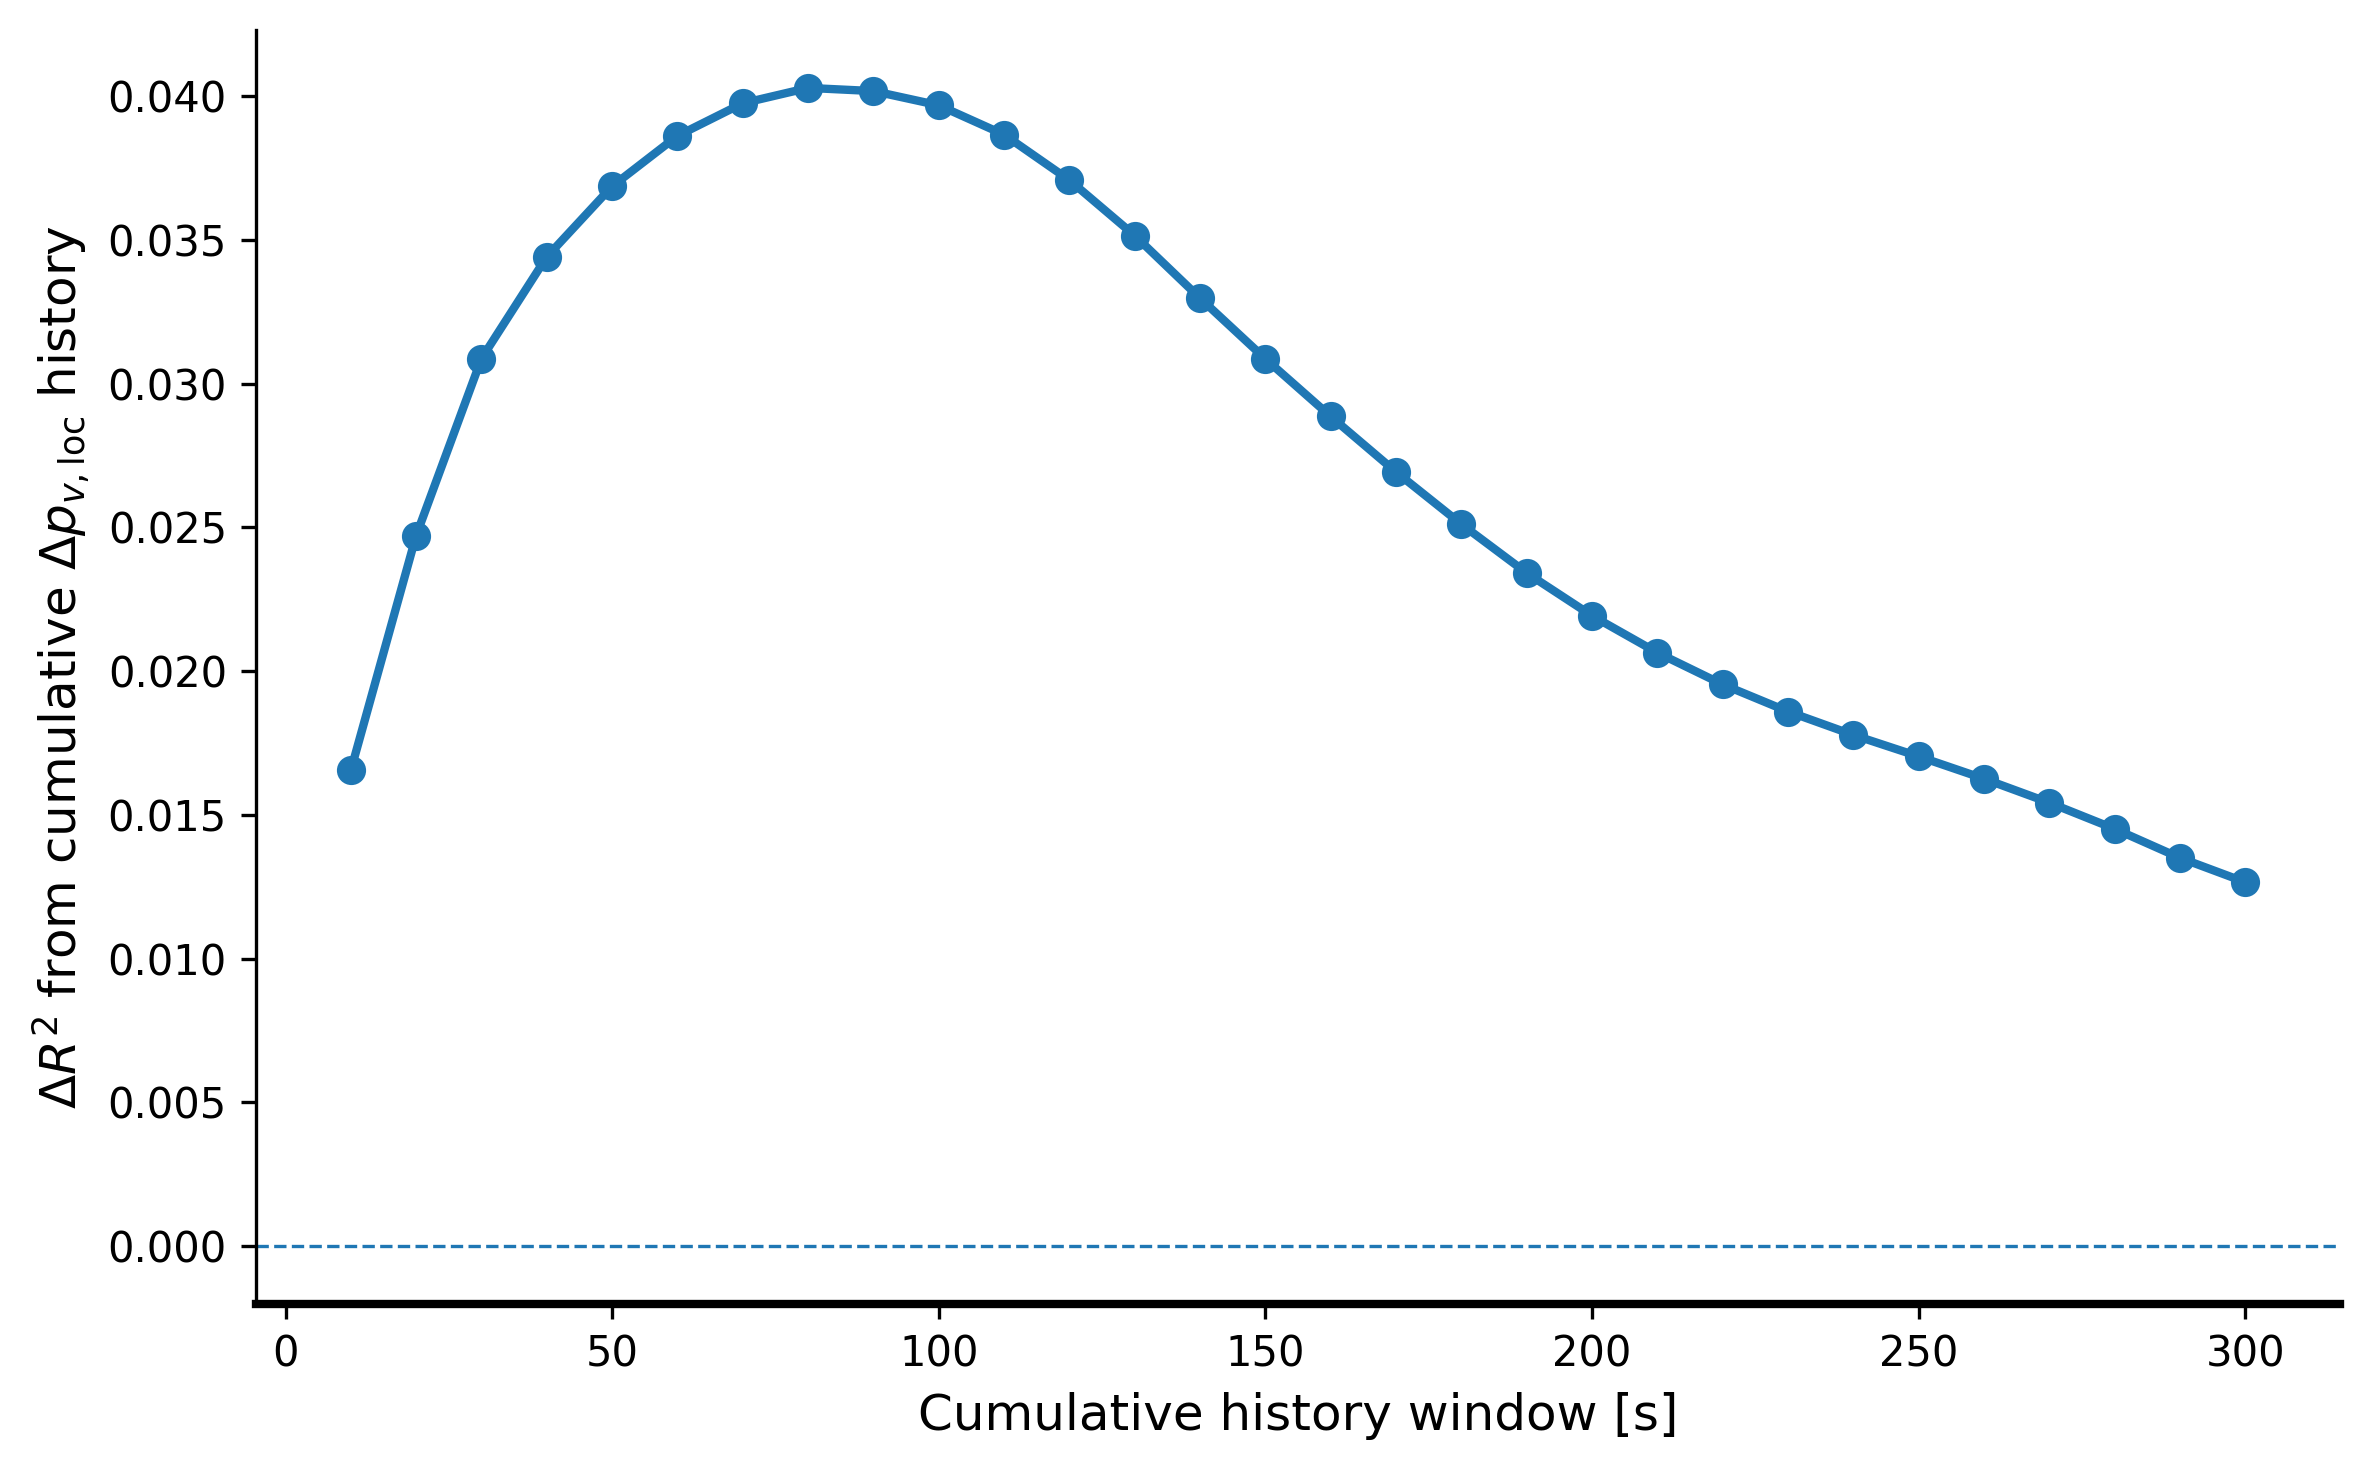

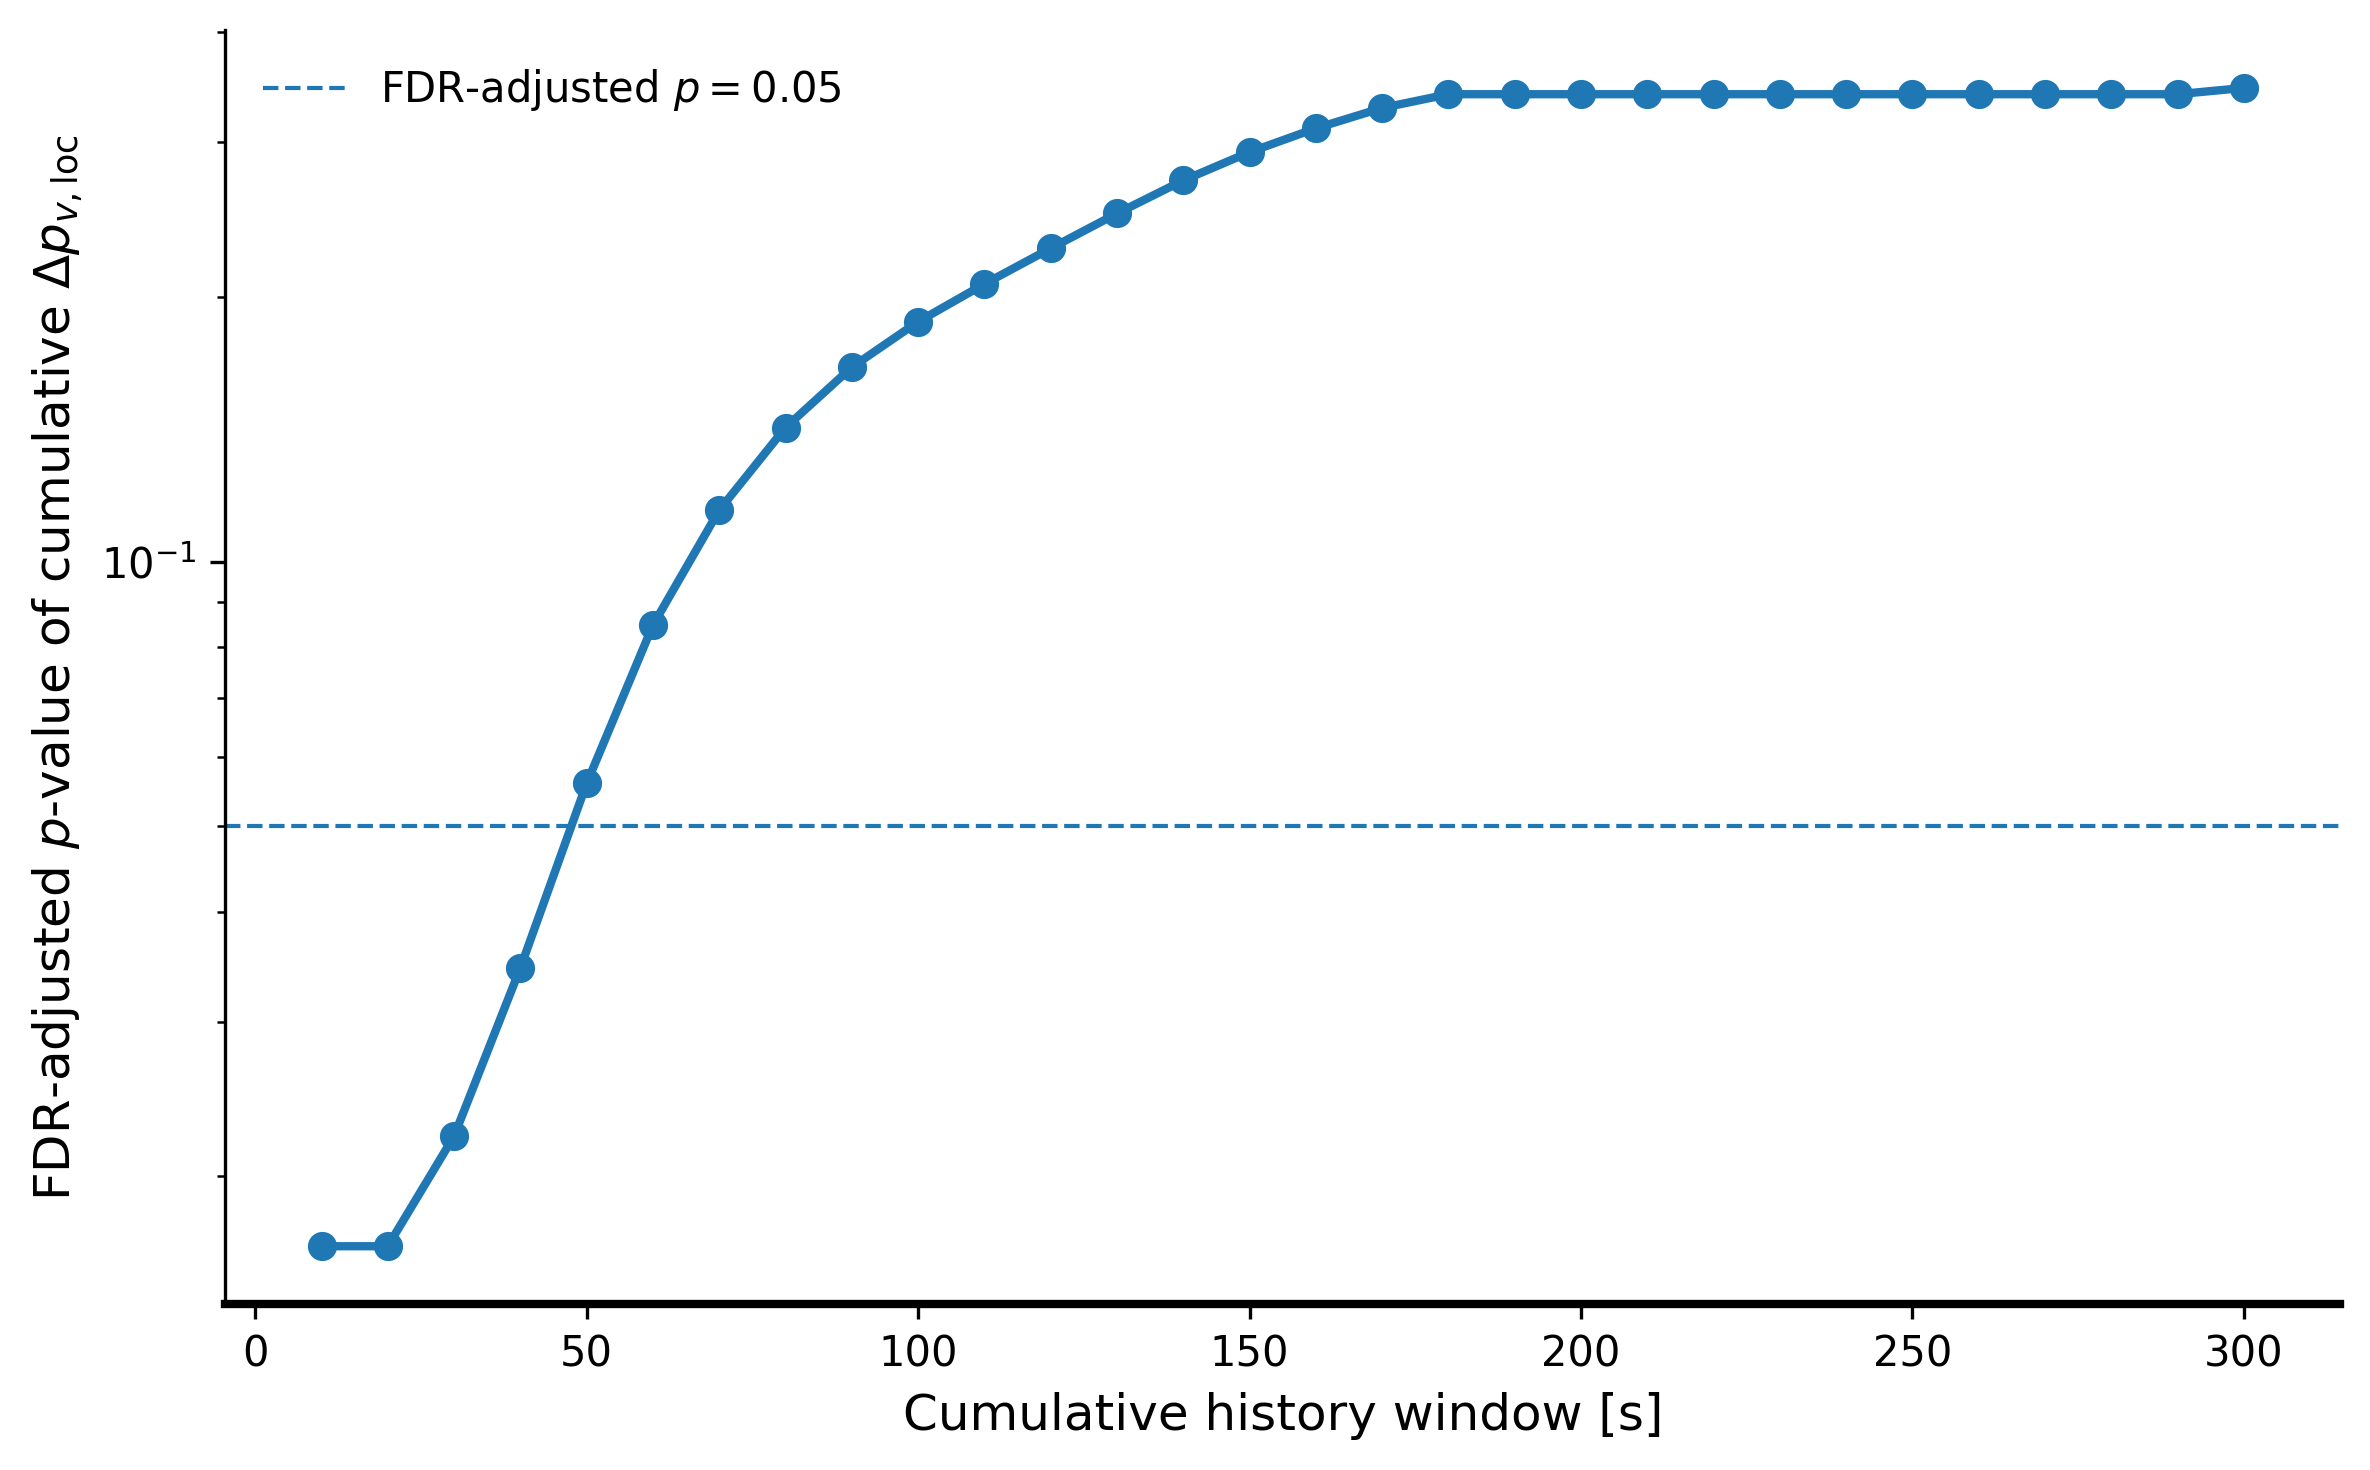

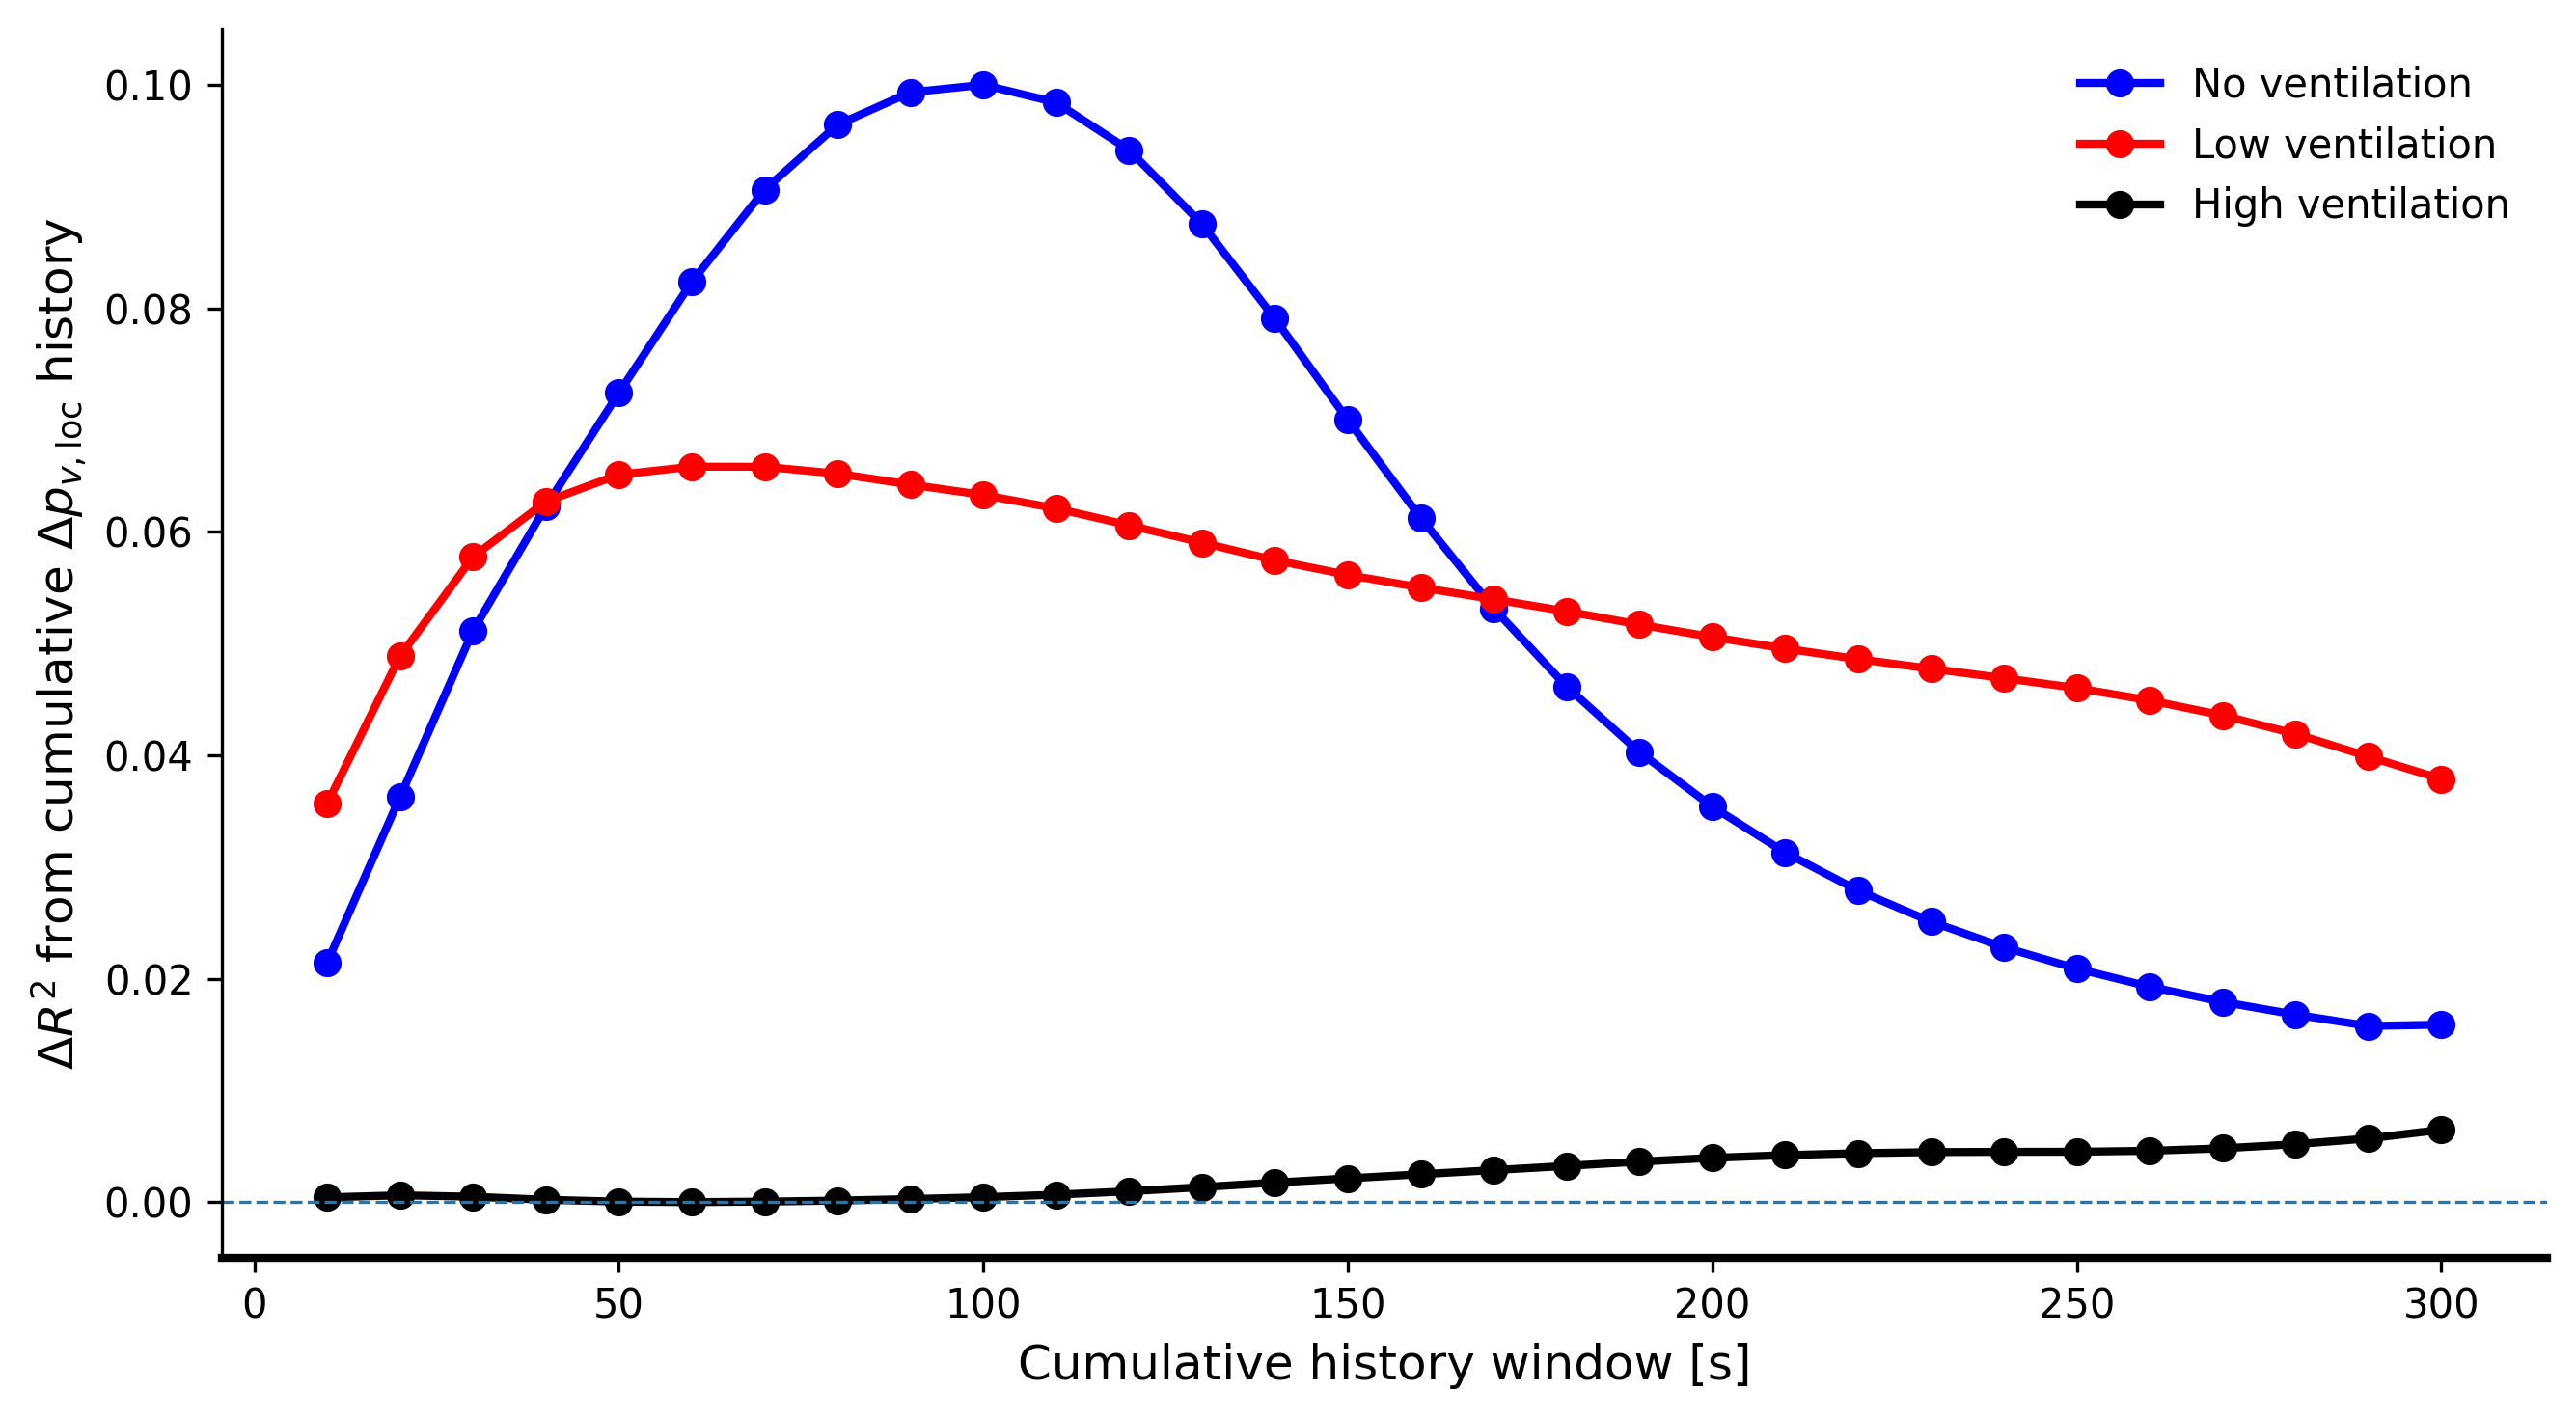

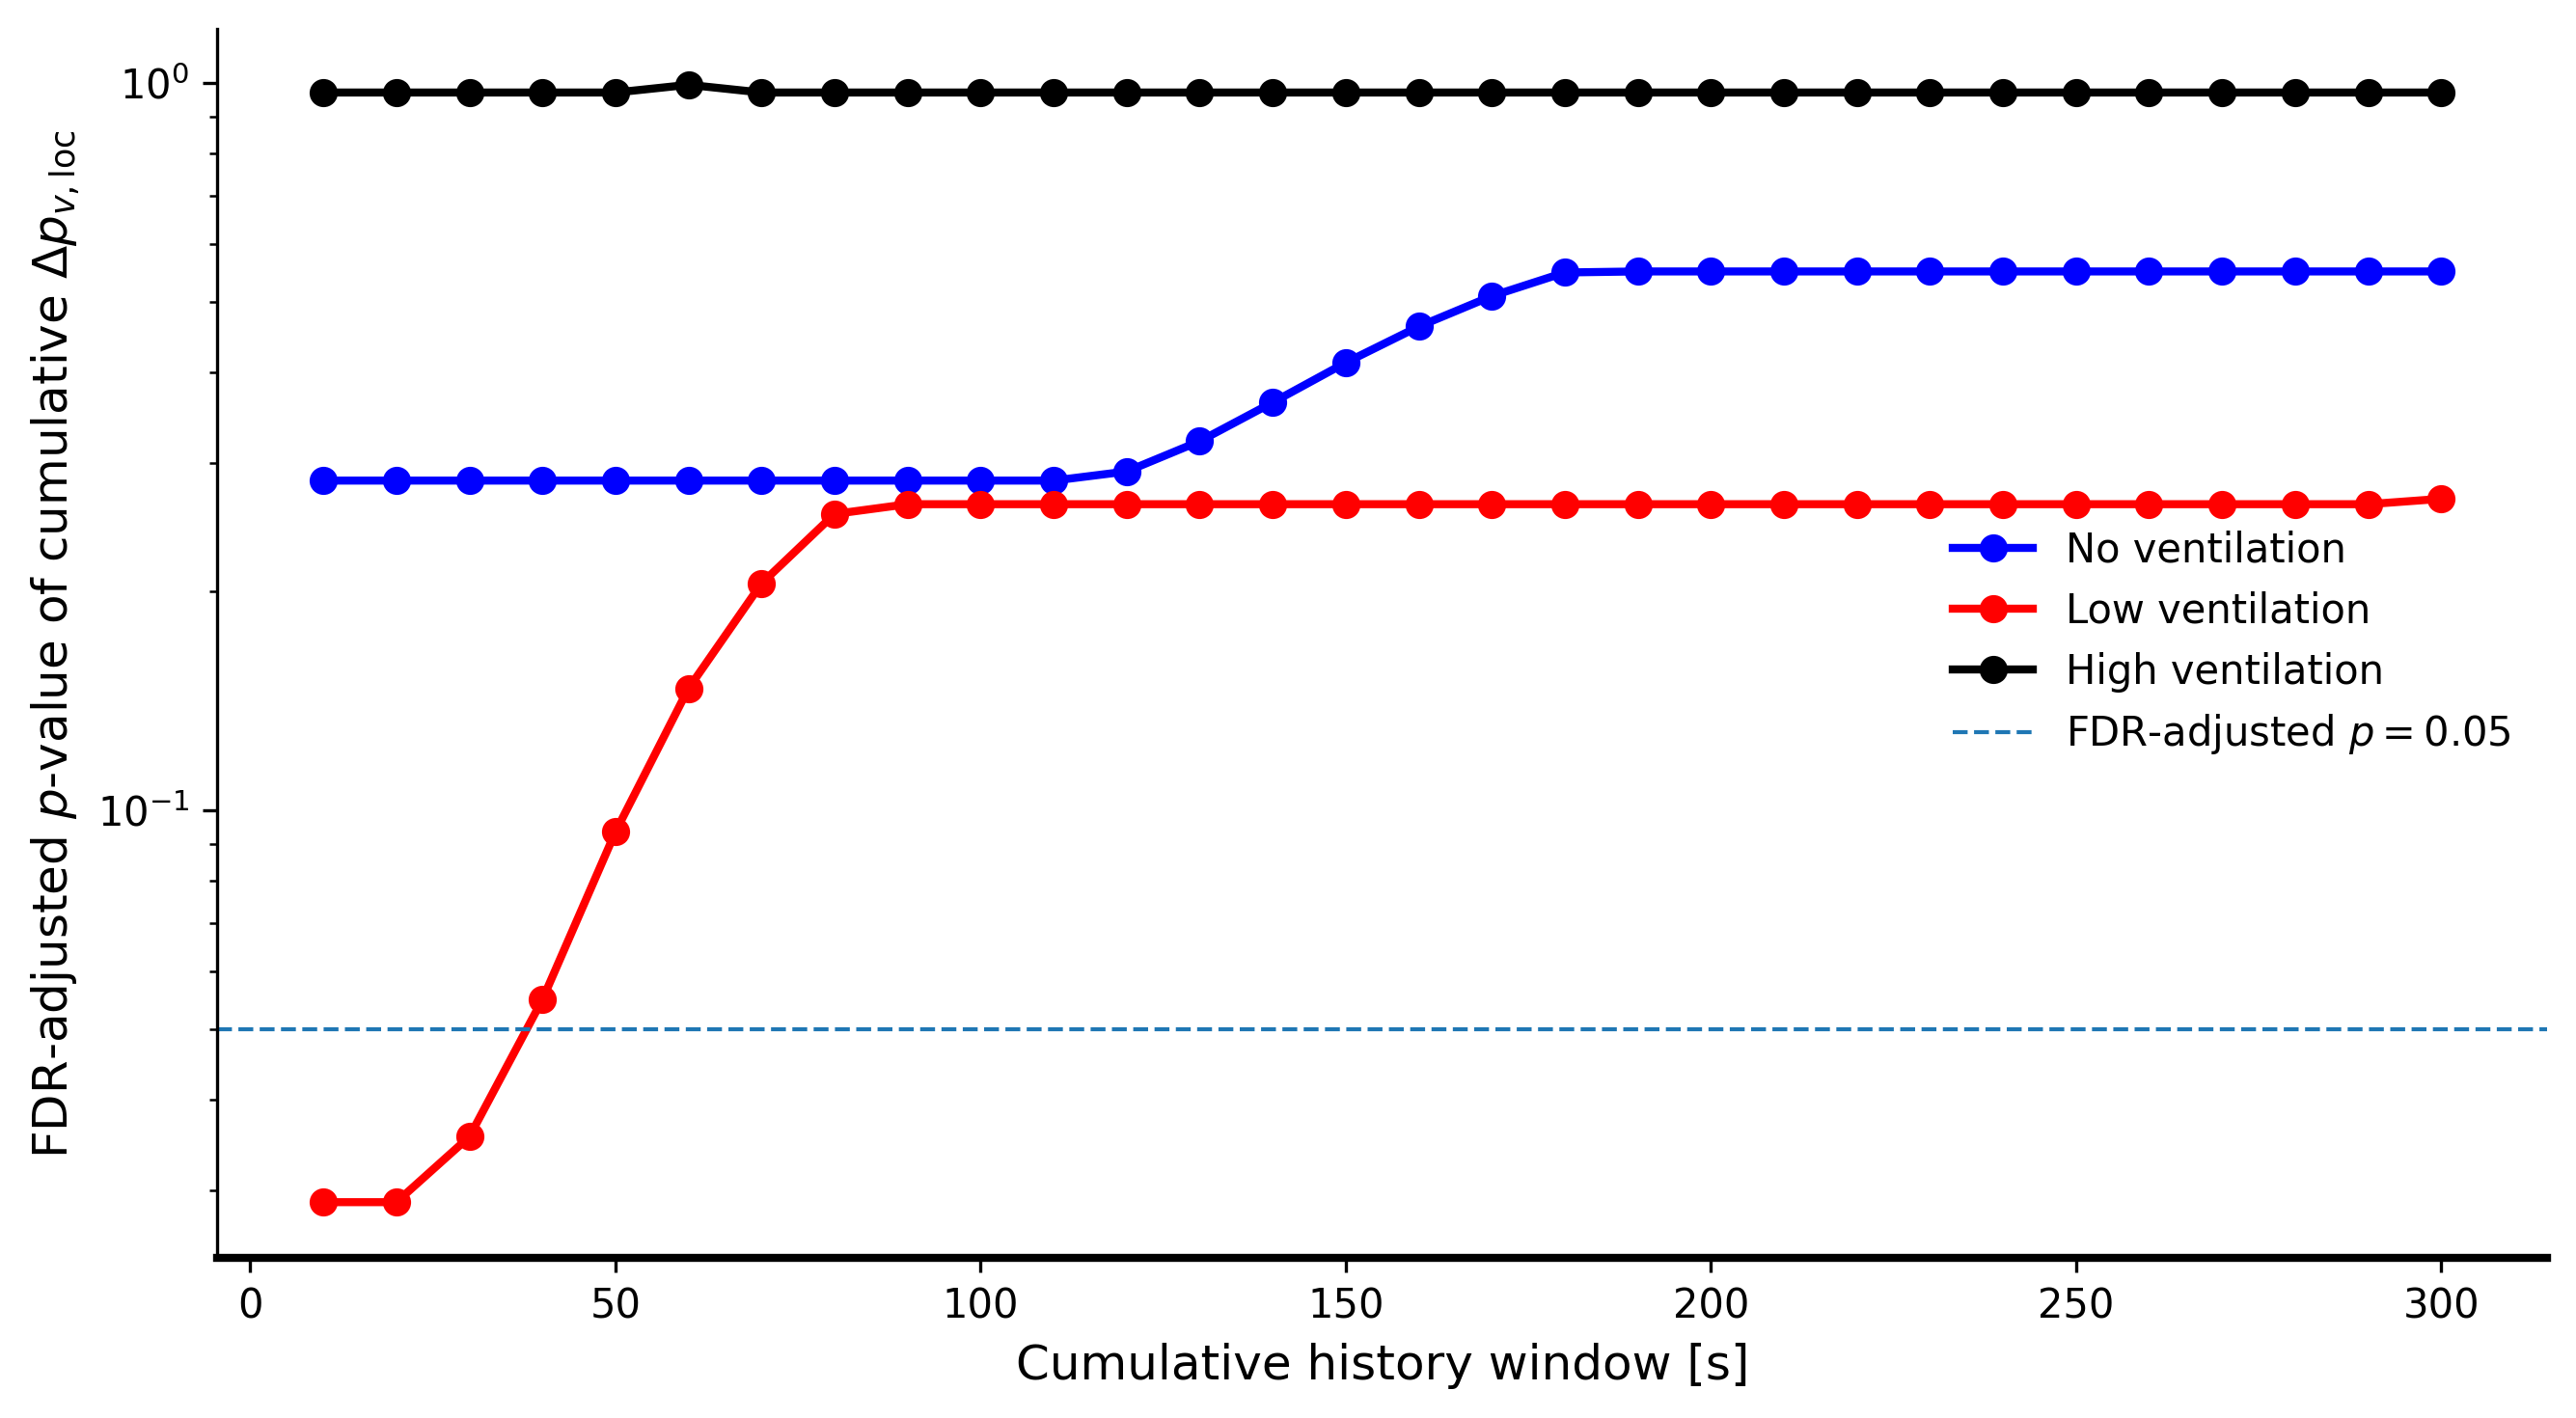

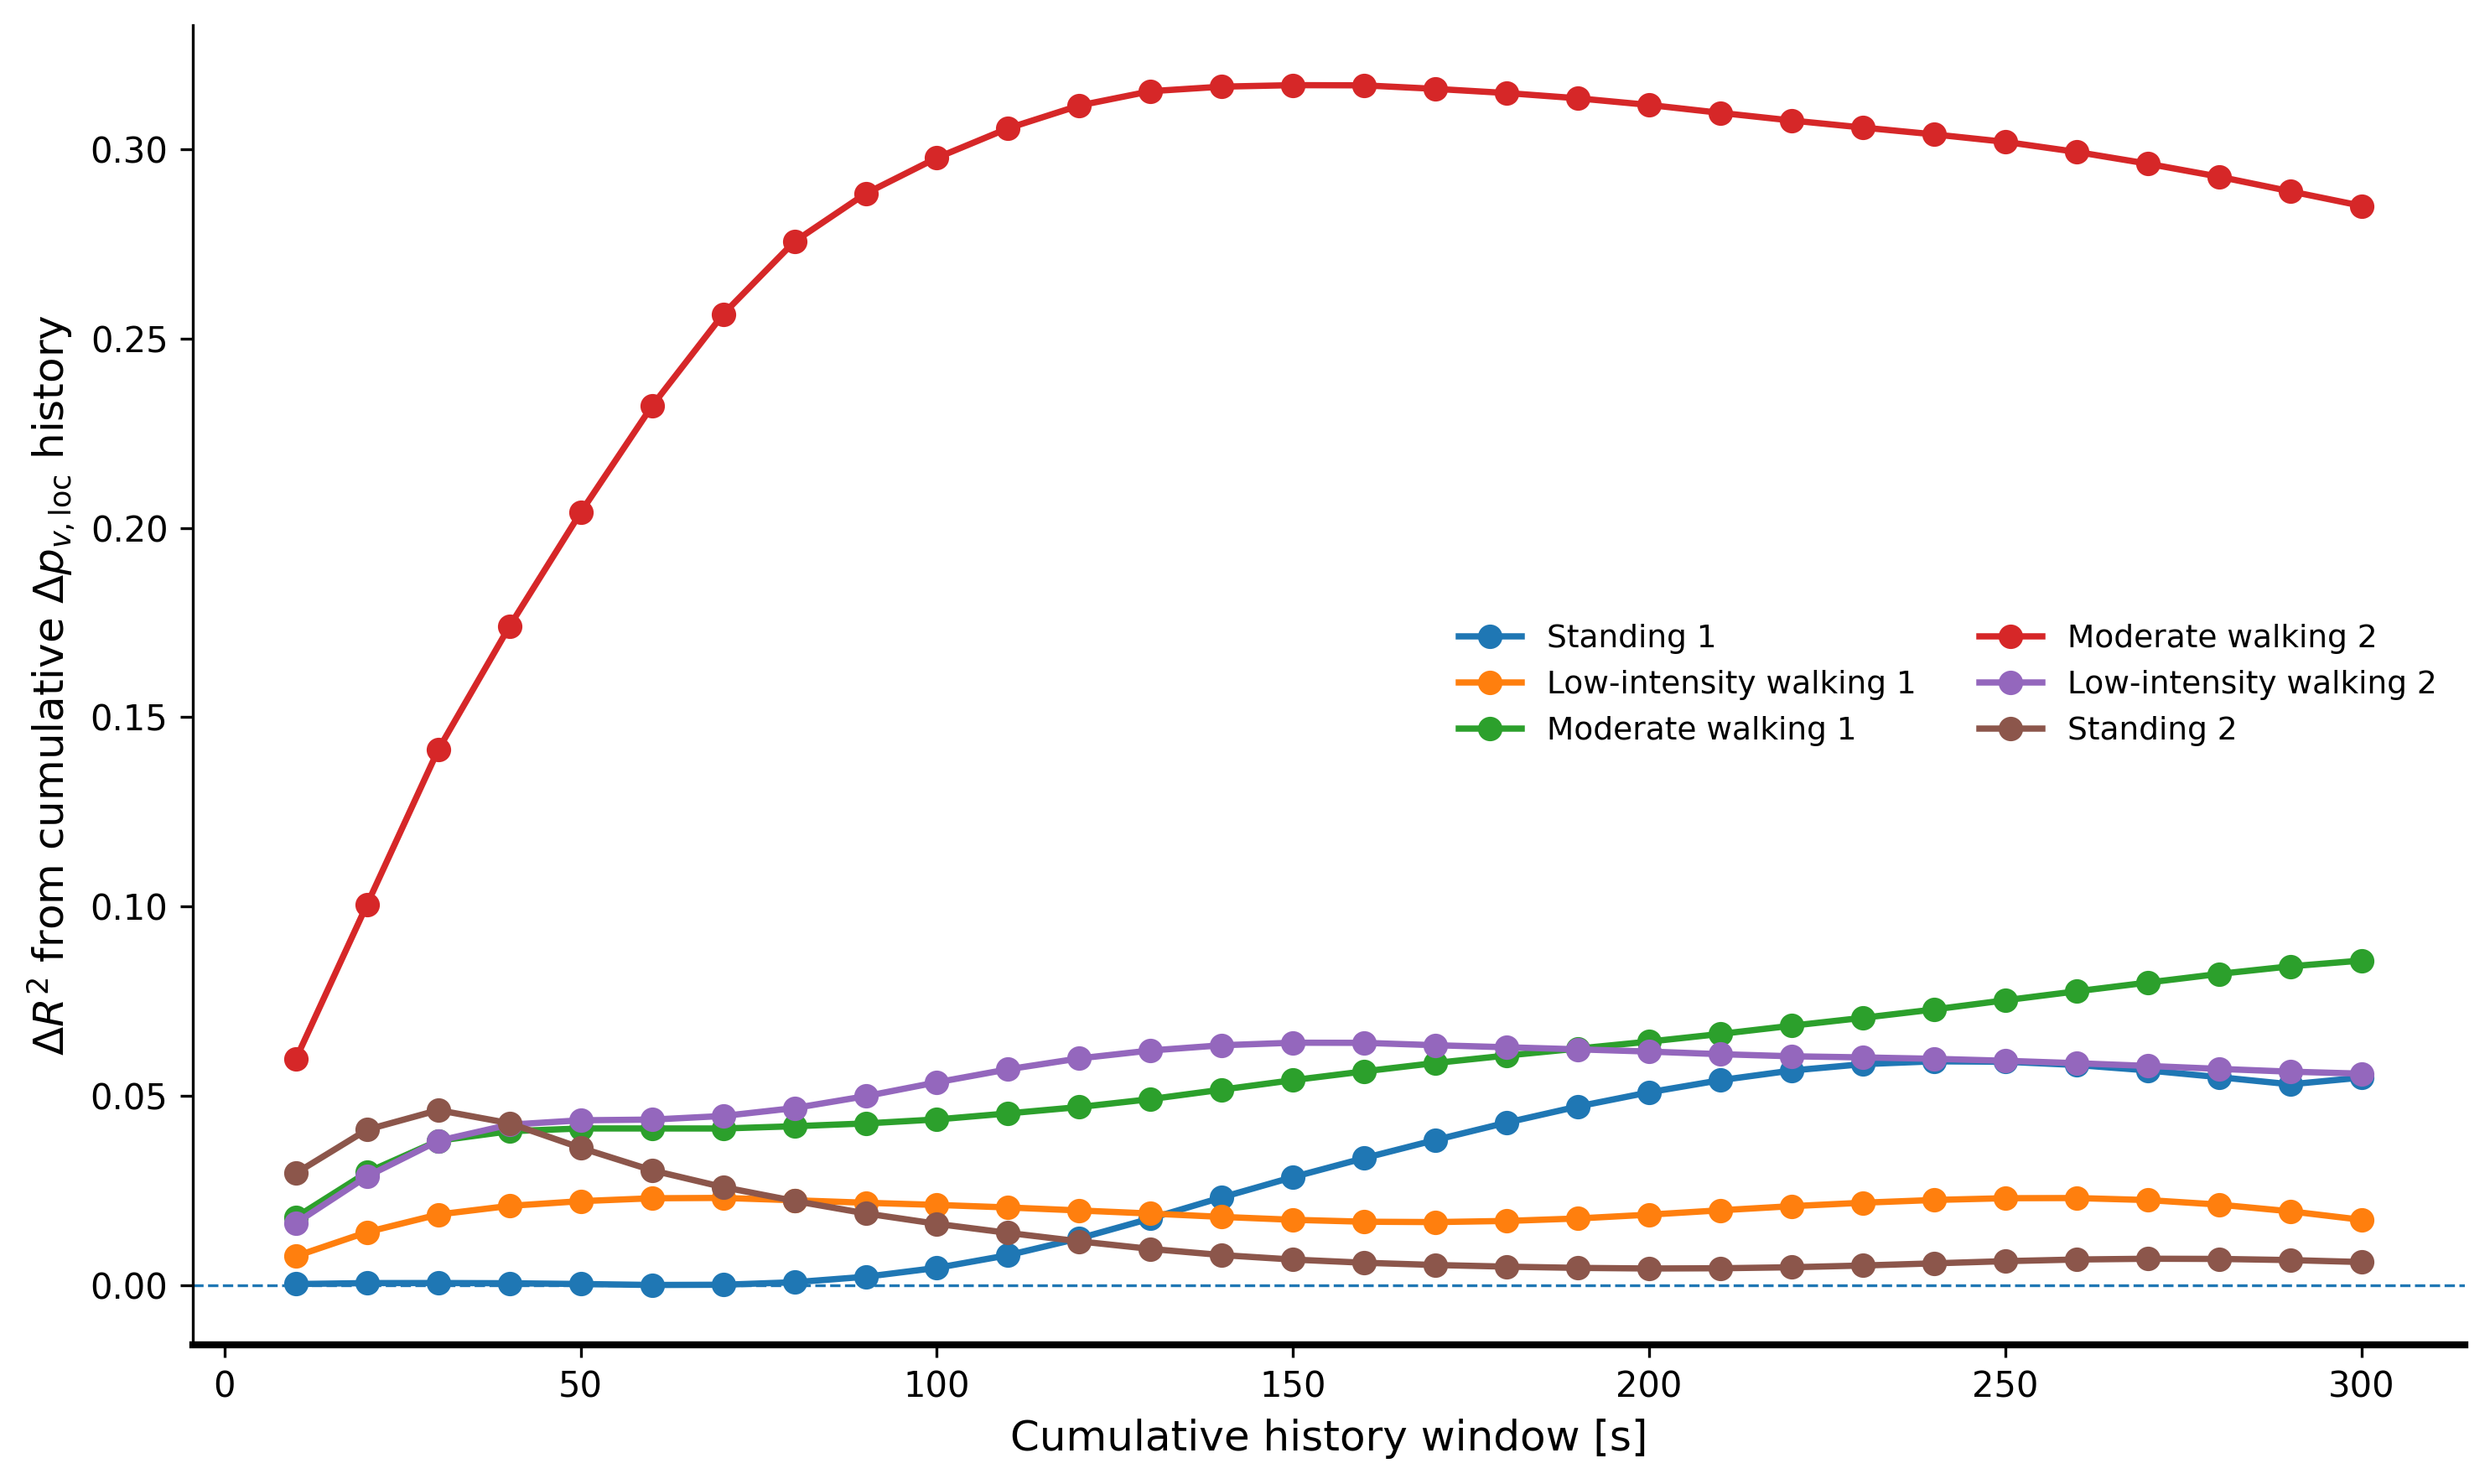

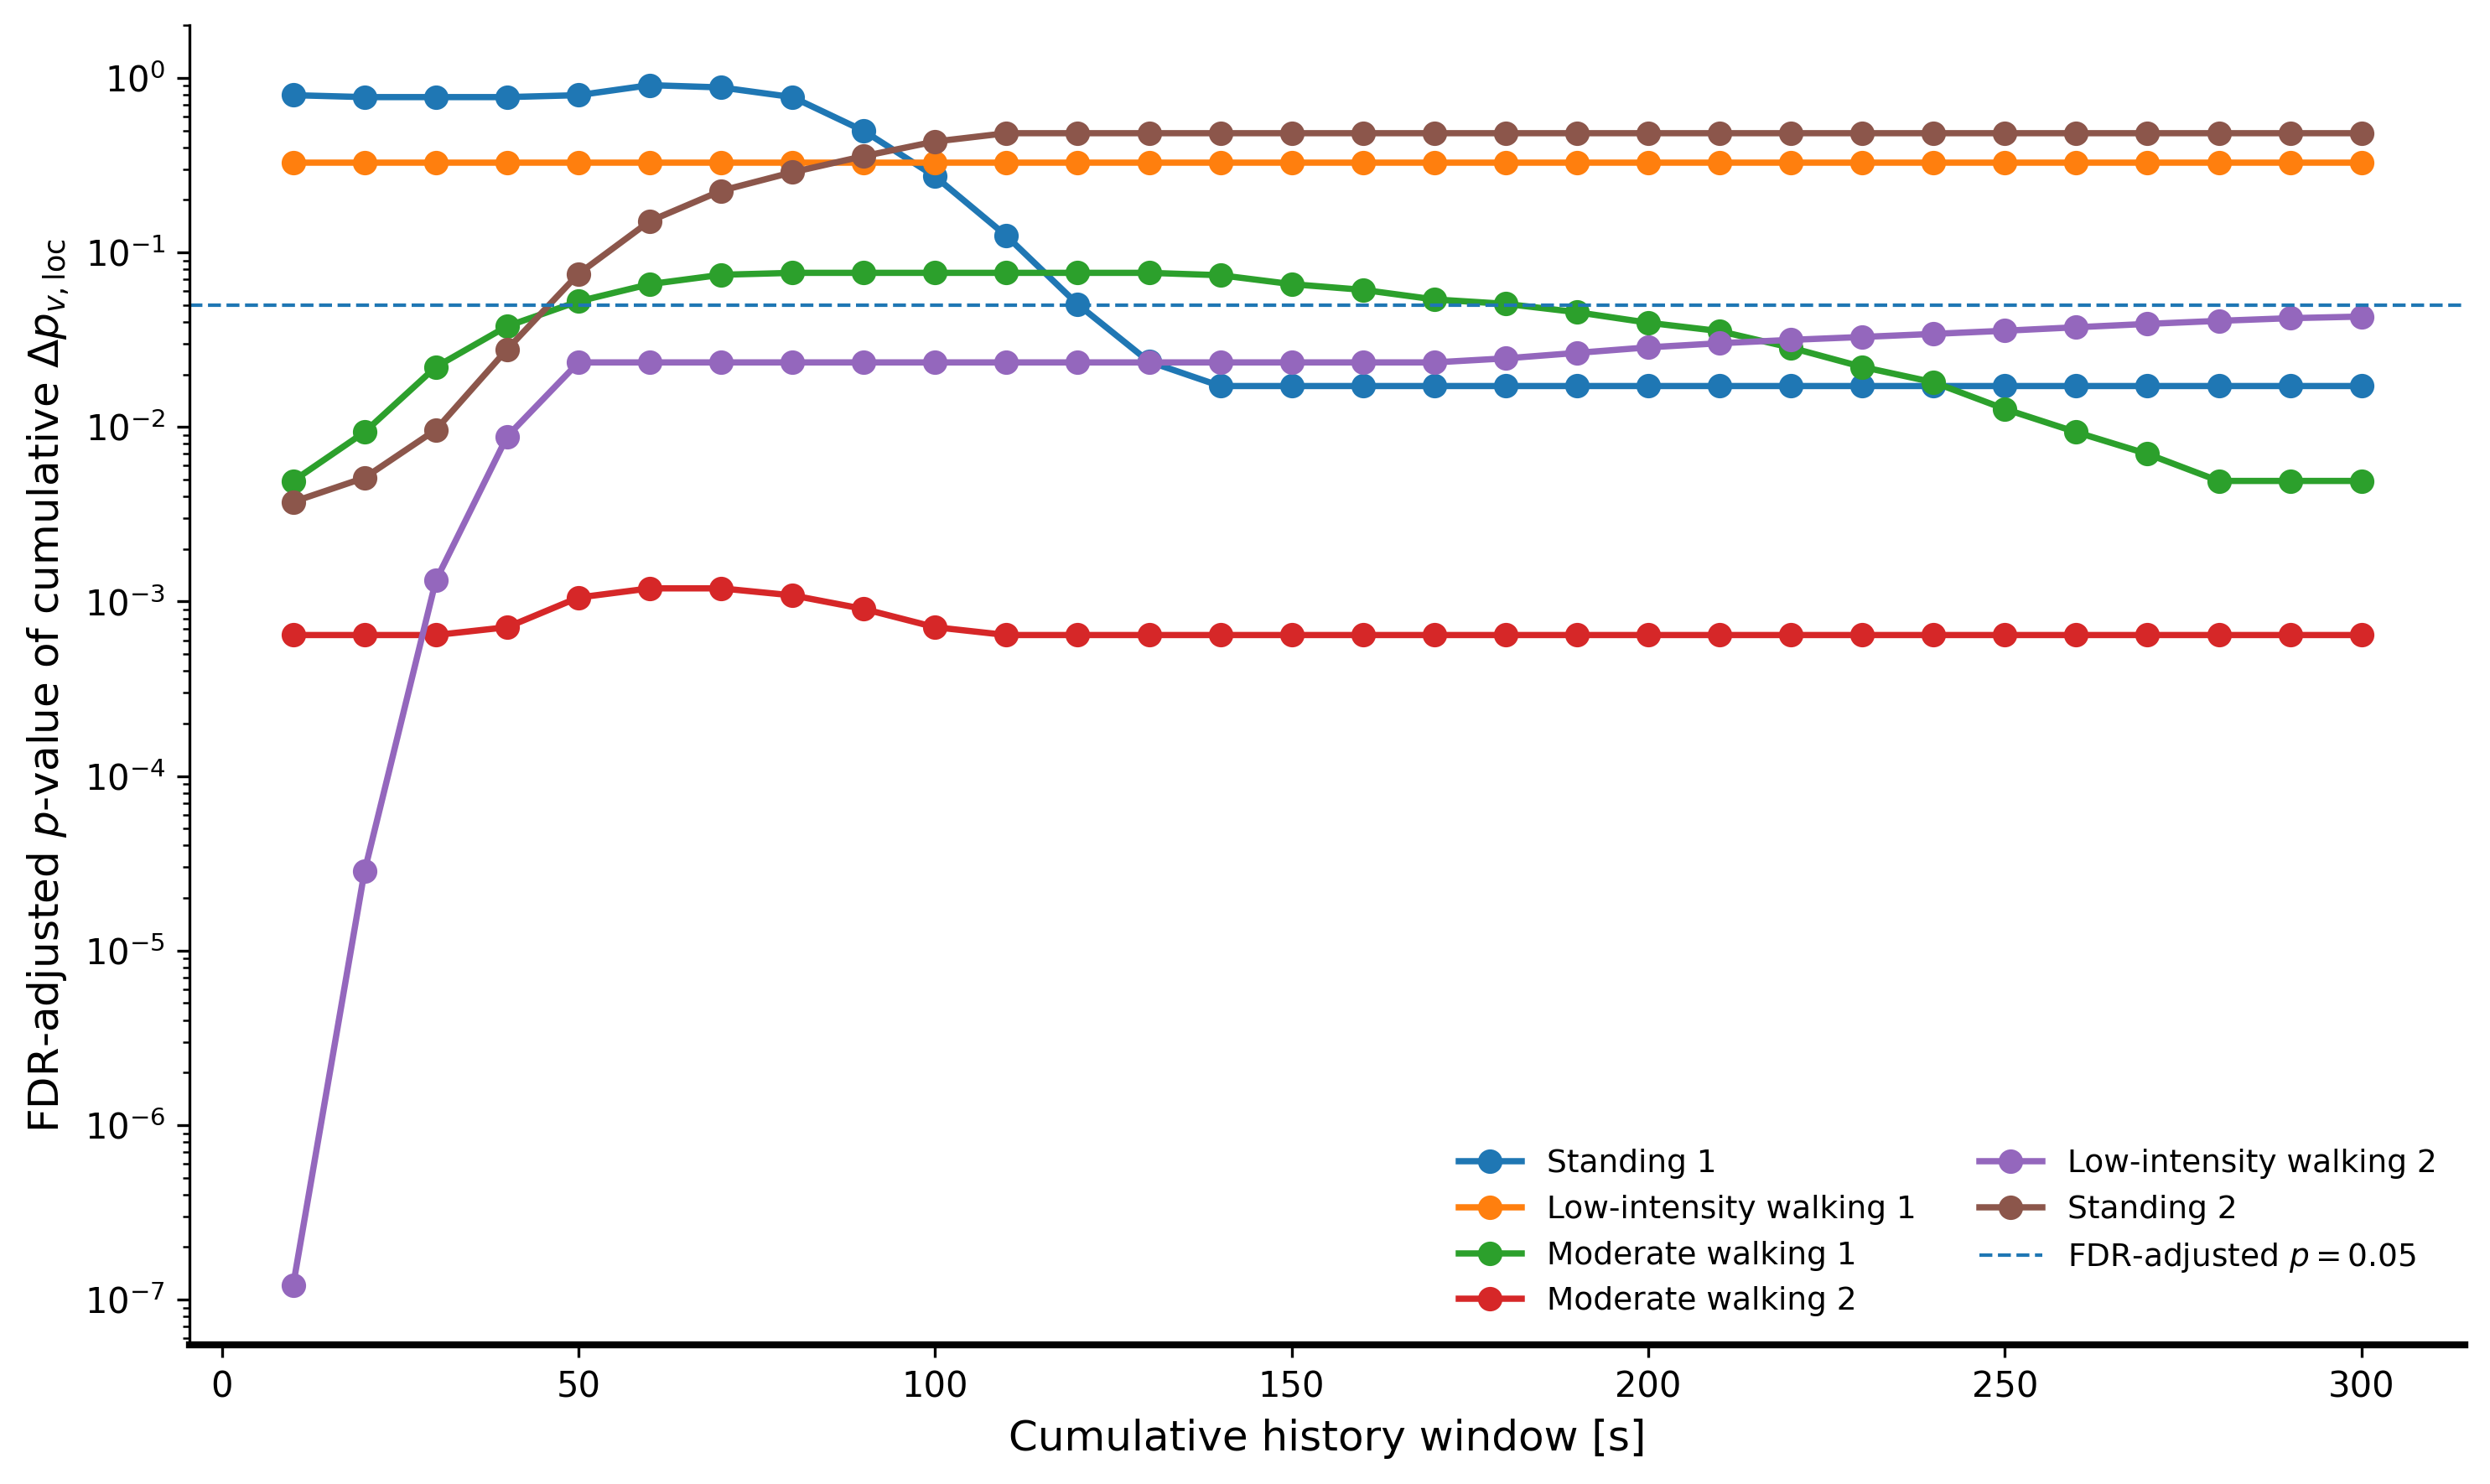

In [9]:
# ============================================================
# CUMULATIVE LATENT-DRIVING-FORCE ANALYSIS
# ============================================================

CUMULATIVE_OUTPUT_DIR = (
    OUTPUT_DIR
    / "cumulative_latent_analysis"
)

CUMULATIVE_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Tested integration windows
HISTORY_WINDOWS_SECONDS = np.arange(
    10,
    301,
    TIME_STEP_SECONDS,
)

MAX_HISTORY_WINDOW_SECONDS = int(
    HISTORY_WINDOWS_SECONDS.max()
)

print(
    "\nRunning cumulative latent-driving-force analysis"
)

print(
    "Tested history windows:",
    HISTORY_WINDOWS_SECONDS,
)


# ============================================================
# BUILD CUMULATIVE LATENT EXPOSURE
# ============================================================

def add_cumulative_latent_predictors(
    data,
    windows_seconds,
):
    """
    Calculate the recent cumulative vapor-pressure driving force:

        integral from t-W to t of delta_pv_loc dt

    The current observation is excluded using shift(1), so the
    cumulative predictor contains only information available
    before the current dT/dt observation.

    Calculations are performed separately for each subject,
    condition and phase, preventing integration across phase
    boundaries.
    """

    cumulative_data = (
        data
        .sort_values(
            [
                "subject_id",
                "condition",
                "phase",
                "elapsed_seconds_bin",
            ]
        )
        .copy()
    )

    group_columns = [
        "subject_id",
        "condition",
        "phase",
    ]

    cumulative_columns = []

    grouped_data = cumulative_data.groupby(
        group_columns,
        observed=True,
        sort=False,
    )

    for window_seconds in windows_seconds:

        if window_seconds % TIME_STEP_SECONDS != 0:
            raise ValueError(
                f"Window {window_seconds} s is not a multiple "
                f"of TIME_STEP_SECONDS={TIME_STEP_SECONDS}."
            )

        window_steps = (
            window_seconds
            // TIME_STEP_SECONDS
        )

        column_name = (
            f"delta_pv_integral_{window_seconds}s"
        )

        cumulative_columns.append(
            column_name
        )

        cumulative_data[column_name] = np.nan

        for _, group in grouped_data:

            group = (
                group
                .sort_values("elapsed_seconds_bin")
            )

            # Exclude the current value. For an outcome at time t,
            # the history therefore covers preceding observations.
            past_delta_pv = (
                group["delta_pv_loc"]
                .shift(1)
            )

            # Rectangular numerical integration.
            cumulative_integral = (
                past_delta_pv
                .rolling(
                    window=window_steps,
                    min_periods=window_steps,
                )
                .sum()
                * TIME_STEP_SECONDS
            )

            cumulative_data.loc[
                group.index,
                column_name,
            ] = cumulative_integral.to_numpy()

    return (
        cumulative_data,
        cumulative_columns,
    )


df_cumulative, cumulative_columns = (
    add_cumulative_latent_predictors(
        data=df,
        windows_seconds=HISTORY_WINDOWS_SECONDS,
    )
)


# ============================================================
# COMMON OUTCOME WINDOW
# ============================================================

# Every history window is evaluated only in the second half of
# each phase. Thus, a 10-s and a 300-s window use the same
# candidate outcome times.

df_cumulative = df_cumulative.loc[
    df_cumulative["seconds_from_phase_start"]
    >= MAX_HISTORY_WINDOW_SECONDS
].copy()


# ============================================================
# OPTIONAL: CONVERT THE INTEGRAL TO A RECENT MEAN
# ============================================================

# The integral has units of kPa*s. We also calculate the mean
# driving force over each history window. The two contain the
# same information for a fixed window, so their R² values are
# identical, but the mean coefficient is easier to compare
# between windows.

cumulative_mean_columns = []

for window_seconds in HISTORY_WINDOWS_SECONDS:

    integral_column = (
        f"delta_pv_integral_{window_seconds}s"
    )

    mean_column = (
        f"delta_pv_mean_{window_seconds}s"
    )

    df_cumulative[mean_column] = (
        df_cumulative[integral_column]
        / window_seconds
    )

    cumulative_mean_columns.append(
        mean_column
    )


# ============================================================
# FIT CUMULATIVE NESTED MODELS
# ============================================================

def fit_cumulative_models(
    data,
    window_seconds,
    analysis_level,
    analysis_group,
):
    """
    Fit three nested models:

    M0:
        dT/dt ~ delta_T

    M1:
        dT/dt ~ delta_T + current delta_pv

    M2:
        dT/dt ~ delta_T + current delta_pv
                + recent mean delta_pv

    Cluster-robust standard errors are calculated by subject.
    """

    history_column = (
        f"delta_pv_mean_{window_seconds}s"
    )

    required_model_columns = [
        "subject_id",
        "dT_dorsal_dt",
        "delta_T_loc",
        "delta_pv_loc",
        history_column,
    ]

    regression_data = (
        data
        .dropna(
            subset=required_model_columns
        )
        .copy()
    )

    n_observations = len(
        regression_data
    )

    n_subjects = (
        regression_data["subject_id"]
        .nunique()
    )

    empty_result = {
        "analysis_level": analysis_level,
        "analysis_group": analysis_group,
        "history_window_seconds": window_seconds,
        "n_observations": n_observations,
        "n_subjects": n_subjects,

        "r2_sensible": np.nan,
        "r2_instantaneous": np.nan,
        "r2_cumulative": np.nan,

        "delta_r2_instantaneous": np.nan,
        "delta_r2_history": np.nan,
        "delta_r2_total": np.nan,

        "aic_sensible": np.nan,
        "aic_instantaneous": np.nan,
        "aic_cumulative": np.nan,

        "delta_aic_instantaneous": np.nan,
        "delta_aic_history": np.nan,
        "delta_aic_total": np.nan,

        "beta_delta_T": np.nan,
        "p_delta_T": np.nan,

        "beta_delta_pv_current": np.nan,
        "p_delta_pv_current": np.nan,

        "beta_delta_pv_history": np.nan,
        "p_delta_pv_history": np.nan,
    }

    if (
        n_observations < 20
        or n_subjects < 2
    ):
        return empty_result

    y = regression_data[
        "dT_dorsal_dt"
    ]

    # Sensible-only model
    X_sensible = sm.add_constant(
        regression_data[
            [
                "delta_T_loc",
            ]
        ],
        has_constant="add",
    )

    # Instantaneous thermo-hygrometric model
    X_instantaneous = sm.add_constant(
        regression_data[
            [
                "delta_T_loc",
                "delta_pv_loc",
            ]
        ],
        has_constant="add",
    )

    # Instantaneous + cumulative-history model
    X_cumulative = sm.add_constant(
        regression_data[
            [
                "delta_T_loc",
                "delta_pv_loc",
                history_column,
            ]
        ],
        has_constant="add",
    )

    cluster_groups = (
        regression_data["subject_id"]
    )

    try:

        model_sensible = sm.OLS(
            y,
            X_sensible,
        ).fit(
            cov_type="cluster",
            cov_kwds={
                "groups": cluster_groups,
            },
        )

        model_instantaneous = sm.OLS(
            y,
            X_instantaneous,
        ).fit(
            cov_type="cluster",
            cov_kwds={
                "groups": cluster_groups,
            },
        )

        model_cumulative = sm.OLS(
            y,
            X_cumulative,
        ).fit(
            cov_type="cluster",
            cov_kwds={
                "groups": cluster_groups,
            },
        )

    except Exception as error:

        print(
            f"WARNING: cumulative model failed for "
            f"{analysis_level}={analysis_group}, "
            f"window={window_seconds} s: {error}"
        )

        return empty_result

    return {
        "analysis_level": analysis_level,
        "analysis_group": analysis_group,
        "history_window_seconds": window_seconds,
        "n_observations": n_observations,
        "n_subjects": n_subjects,

        "r2_sensible":
            model_sensible.rsquared,

        "r2_instantaneous":
            model_instantaneous.rsquared,

        "r2_cumulative":
            model_cumulative.rsquared,

        # Added value of current delta_pv over sensible model
        "delta_r2_instantaneous": (
            model_instantaneous.rsquared
            - model_sensible.rsquared
        ),

        # Added value of recent history beyond current delta_pv
        "delta_r2_history": (
            model_cumulative.rsquared
            - model_instantaneous.rsquared
        ),

        # Total improvement over the sensible-only model
        "delta_r2_total": (
            model_cumulative.rsquared
            - model_sensible.rsquared
        ),

        "aic_sensible":
            model_sensible.aic,

        "aic_instantaneous":
            model_instantaneous.aic,

        "aic_cumulative":
            model_cumulative.aic,

        "delta_aic_instantaneous": (
            model_instantaneous.aic
            - model_sensible.aic
        ),

        "delta_aic_history": (
            model_cumulative.aic
            - model_instantaneous.aic
        ),

        "delta_aic_total": (
            model_cumulative.aic
            - model_sensible.aic
        ),

        "beta_delta_T":
            model_cumulative.params[
                "delta_T_loc"
            ],

        "p_delta_T":
            model_cumulative.pvalues[
                "delta_T_loc"
            ],

        "beta_delta_pv_current":
            model_cumulative.params[
                "delta_pv_loc"
            ],

        "p_delta_pv_current":
            model_cumulative.pvalues[
                "delta_pv_loc"
            ],

        "beta_delta_pv_history":
            model_cumulative.params[
                history_column
            ],

        "p_delta_pv_history":
            model_cumulative.pvalues[
                history_column
            ],
    }


# ============================================================
# RUN CUMULATIVE WINDOW SERIES
# ============================================================

def run_cumulative_series(
    data,
    analysis_level,
    analysis_group,
):
    group_results = []

    for window_seconds in HISTORY_WINDOWS_SECONDS:

        result = fit_cumulative_models(
            data=data,
            window_seconds=window_seconds,
            analysis_level=analysis_level,
            analysis_group=analysis_group,
        )

        group_results.append(
            result
        )

    return group_results


cumulative_results = []


# Overall
cumulative_results.extend(
    run_cumulative_series(
        data=df_cumulative,
        analysis_level="overall",
        analysis_group="all",
    )
)


# By condition
for condition in CONDITION_ORDER:

    condition_data = df_cumulative.loc[
        df_cumulative["condition"] == condition
    ].copy()

    cumulative_results.extend(
        run_cumulative_series(
            data=condition_data,
            analysis_level="condition",
            analysis_group=condition,
        )
    )


# By phase
for phase in PHASE_ORDER:

    phase_data = df_cumulative.loc[
        df_cumulative["phase"] == phase
    ].copy()

    cumulative_results.extend(
        run_cumulative_series(
            data=phase_data,
            analysis_level="phase",
            analysis_group=phase,
        )
    )


cumulative_results_df = pd.DataFrame(
    cumulative_results
)


# ============================================================
# FDR CORRECTION
# ============================================================

cumulative_results_df[
    "p_delta_pv_history_fdr"
] = np.nan

cumulative_results_df[
    "p_delta_pv_current_fdr"
] = np.nan

for (
    analysis_level,
    analysis_group,
), group in cumulative_results_df.groupby(
    [
        "analysis_level",
        "analysis_group",
    ],
    observed=True,
):

    # FDR for cumulative-history term
    valid_history_indices = group.index[
        group["p_delta_pv_history"].notna()
    ]

    if len(valid_history_indices) > 0:

        corrected_history = multipletests(
            cumulative_results_df.loc[
                valid_history_indices,
                "p_delta_pv_history",
            ],
            alpha=0.05,
            method="fdr_bh",
        )[1]

        cumulative_results_df.loc[
            valid_history_indices,
            "p_delta_pv_history_fdr",
        ] = corrected_history

    # FDR for current delta_pv term
    valid_current_indices = group.index[
        group["p_delta_pv_current"].notna()
    ]

    if len(valid_current_indices) > 0:

        corrected_current = multipletests(
            cumulative_results_df.loc[
                valid_current_indices,
                "p_delta_pv_current",
            ],
            alpha=0.05,
            method="fdr_bh",
        )[1]

        cumulative_results_df.loc[
            valid_current_indices,
            "p_delta_pv_current_fdr",
        ] = corrected_current


# ============================================================
# SAVE FULL RESULTS
# ============================================================

cumulative_results_path = (
    CUMULATIVE_OUTPUT_DIR
    / "cumulative_latent_ols_results.csv"
)

cumulative_results_df.to_csv(
    cumulative_results_path,
    index=False,
)

print(
    "\nCumulative latent OLS results saved to:"
)

print(
    cumulative_results_path
)


# ============================================================
# SAMPLE-SIZE CONSISTENCY
# ============================================================

cumulative_sample_check = (
    cumulative_results_df
    .groupby(
        [
            "analysis_level",
            "analysis_group",
        ],
        observed=True,
    )
    .agg(
        minimum_n=(
            "n_observations",
            "min",
        ),
        maximum_n=(
            "n_observations",
            "max",
        ),
        minimum_subjects=(
            "n_subjects",
            "min",
        ),
        maximum_subjects=(
            "n_subjects",
            "max",
        ),
    )
    .reset_index()
)

cumulative_sample_check["constant_n"] = (
    cumulative_sample_check["minimum_n"]
    == cumulative_sample_check["maximum_n"]
)

cumulative_sample_check_path = (
    CUMULATIVE_OUTPUT_DIR
    / "cumulative_sample_size_check.csv"
)

cumulative_sample_check.to_csv(
    cumulative_sample_check_path,
    index=False,
)

print(
    "\nCumulative sample-size consistency check:"
)

print(
    cumulative_sample_check.to_string(
        index=False
    )
)


# ============================================================
# EXTRACT BEST HISTORY WINDOW
# ============================================================

def extract_best_history_window(group):

    valid = (
        group
        .dropna(
            subset=[
                "delta_r2_history",
                "p_delta_pv_history",
            ]
        )
        .copy()
    )

    if valid.empty:

        return {
            "best_window_by_delta_r2": np.nan,
            "maximum_delta_r2_history": np.nan,
            "r2_sensible": np.nan,
            "r2_instantaneous": np.nan,
            "r2_cumulative": np.nan,
            "delta_r2_total": np.nan,
            "p_history_at_best_r2": np.nan,
            "p_history_fdr_at_best_r2": np.nan,
            "beta_history_at_best_r2": np.nan,
            "best_window_by_pvalue": np.nan,
            "minimum_p_history": np.nan,
            "minimum_p_history_fdr": np.nan,
            "delta_r2_at_best_pvalue": np.nan,
            "n_observations": np.nan,
            "n_subjects": np.nan,
        }

    best_r2_row = valid.loc[
        valid["delta_r2_history"].idxmax()
    ]

    best_p_row = valid.loc[
        valid["p_delta_pv_history"].idxmin()
    ]

    return {
        "best_window_by_delta_r2":
            best_r2_row[
                "history_window_seconds"
            ],

        "maximum_delta_r2_history":
            best_r2_row[
                "delta_r2_history"
            ],

        "r2_sensible":
            best_r2_row[
                "r2_sensible"
            ],

        "r2_instantaneous":
            best_r2_row[
                "r2_instantaneous"
            ],

        "r2_cumulative":
            best_r2_row[
                "r2_cumulative"
            ],

        "delta_r2_total":
            best_r2_row[
                "delta_r2_total"
            ],

        "p_history_at_best_r2":
            best_r2_row[
                "p_delta_pv_history"
            ],

        "p_history_fdr_at_best_r2":
            best_r2_row[
                "p_delta_pv_history_fdr"
            ],

        "beta_history_at_best_r2":
            best_r2_row[
                "beta_delta_pv_history"
            ],

        "best_window_by_pvalue":
            best_p_row[
                "history_window_seconds"
            ],

        "minimum_p_history":
            best_p_row[
                "p_delta_pv_history"
            ],

        "minimum_p_history_fdr":
            best_p_row[
                "p_delta_pv_history_fdr"
            ],

        "delta_r2_at_best_pvalue":
            best_p_row[
                "delta_r2_history"
            ],

        "n_observations":
            best_r2_row[
                "n_observations"
            ],

        "n_subjects":
            best_r2_row[
                "n_subjects"
            ],
    }


best_history_rows = []

for (
    analysis_level,
    analysis_group,
), group in cumulative_results_df.groupby(
    [
        "analysis_level",
        "analysis_group",
    ],
    observed=True,
):

    summary = extract_best_history_window(
        group
    )

    summary["analysis_level"] = (
        analysis_level
    )

    summary["analysis_group"] = (
        analysis_group
    )

    best_history_rows.append(
        summary
    )


best_history_windows = pd.DataFrame(
    best_history_rows
)

best_history_column_order = [
    "analysis_level",
    "analysis_group",
    "best_window_by_delta_r2",
    "maximum_delta_r2_history",
    "r2_sensible",
    "r2_instantaneous",
    "r2_cumulative",
    "delta_r2_total",
    "p_history_at_best_r2",
    "p_history_fdr_at_best_r2",
    "beta_history_at_best_r2",
    "best_window_by_pvalue",
    "minimum_p_history",
    "minimum_p_history_fdr",
    "delta_r2_at_best_pvalue",
    "n_observations",
    "n_subjects",
]

best_history_windows = (
    best_history_windows[
        best_history_column_order
    ]
    .sort_values(
        [
            "analysis_level",
            "analysis_group",
        ]
    )
    .reset_index(drop=True)
)

best_history_path = (
    CUMULATIVE_OUTPUT_DIR
    / "best_cumulative_windows_summary.csv"
)

best_history_windows.to_csv(
    best_history_path,
    index=False,
)

print(
    "\nBest cumulative-history windows:"
)

print(
    best_history_windows.to_string(
        index=False
    )
)


# ============================================================
# PLOT: OVERALL HISTORY CONTRIBUTION
# ============================================================

overall_cumulative = (
    cumulative_results_df
    .loc[
        cumulative_results_df[
            "analysis_level"
        ] == "overall"
    ]
    .sort_values(
        "history_window_seconds"
    )
    .copy()
)

fig, ax = plt.subplots(
    figsize=(8, 5),
    dpi=300,
)

ax.plot(
    overall_cumulative[
        "history_window_seconds"
    ],
    overall_cumulative[
        "delta_r2_history"
    ],
    marker="o",
    linewidth=2,
)

ax.axhline(
    0,
    linewidth=0.8,
    linestyle="--",
)

ax.set_xlabel(
    "Cumulative history window [s]",
    fontsize=12,
)

ax.set_ylabel(
    r"$\Delta R^2$ from cumulative "
    r"$\Delta p_{v,\mathrm{loc}}$ history",
    fontsize=12,
)

clean_axes(ax)

plt.tight_layout()

fig.savefig(
    CUMULATIVE_OUTPUT_DIR
    / "overall_cumulative_delta_r2.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# PLOT: OVERALL FDR-ADJUSTED P-VALUE
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 5),
    dpi=300,
)

ax.plot(
    overall_cumulative[
        "history_window_seconds"
    ],
    overall_cumulative[
        "p_delta_pv_history_fdr"
    ],
    marker="o",
    linewidth=2,
)

ax.axhline(
    0.05,
    linewidth=1,
    linestyle="--",
    label=r"FDR-adjusted $p=0.05$",
)

ax.set_xlabel(
    "Cumulative history window [s]",
    fontsize=12,
)

ax.set_ylabel(
    r"FDR-adjusted $p$-value of cumulative "
    r"$\Delta p_{v,\mathrm{loc}}$",
    fontsize=12,
)

ax.set_yscale(
    "log"
)

clean_axes(ax)

ax.legend(
    frameon=False,
)

plt.tight_layout()

fig.savefig(
    CUMULATIVE_OUTPUT_DIR
    / "overall_cumulative_pvalue_fdr.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# PLOT: HISTORY CONTRIBUTION BY CONDITION
# ============================================================

condition_cumulative = (
    cumulative_results_df
    .loc[
        cumulative_results_df[
            "analysis_level"
        ] == "condition"
    ]
    .sort_values(
        "history_window_seconds"
    )
    .copy()
)

fig, ax = plt.subplots(
    figsize=(9, 5),
    dpi=300,
)

for condition in CONDITION_ORDER:

    subset = condition_cumulative.loc[
        condition_cumulative[
            "analysis_group"
        ] == condition
    ]

    ax.plot(
        subset[
            "history_window_seconds"
        ],
        subset[
            "delta_r2_history"
        ],
        color=CONDITION_COLORS[
            condition
        ],
        label=CONDITION_LABELS[
            condition
        ],
        marker="o",
        linewidth=2,
    )

ax.axhline(
    0,
    linewidth=0.8,
    linestyle="--",
)

ax.set_xlabel(
    "Cumulative history window [s]",
    fontsize=12,
)

ax.set_ylabel(
    r"$\Delta R^2$ from cumulative "
    r"$\Delta p_{v,\mathrm{loc}}$ history",
    fontsize=12,
)

clean_axes(ax)

ax.legend(
    frameon=False,
)

plt.tight_layout()

fig.savefig(
    CUMULATIVE_OUTPUT_DIR
    / "cumulative_delta_r2_by_condition.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# PLOT: HISTORY FDR P-VALUE BY CONDITION
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 5),
    dpi=300,
)

for condition in CONDITION_ORDER:

    subset = condition_cumulative.loc[
        condition_cumulative[
            "analysis_group"
        ] == condition
    ]

    ax.plot(
        subset[
            "history_window_seconds"
        ],
        subset[
            "p_delta_pv_history_fdr"
        ],
        color=CONDITION_COLORS[
            condition
        ],
        label=CONDITION_LABELS[
            condition
        ],
        marker="o",
        linewidth=2,
    )

ax.axhline(
    0.05,
    linewidth=1,
    linestyle="--",
    label=r"FDR-adjusted $p=0.05$",
)

ax.set_xlabel(
    "Cumulative history window [s]",
    fontsize=12,
)

ax.set_ylabel(
    r"FDR-adjusted $p$-value of cumulative "
    r"$\Delta p_{v,\mathrm{loc}}$",
    fontsize=12,
)

ax.set_yscale(
    "log"
)

clean_axes(ax)

ax.legend(
    frameon=False,
)

plt.tight_layout()

fig.savefig(
    CUMULATIVE_OUTPUT_DIR
    / "cumulative_pvalue_fdr_by_condition.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# PLOT: HISTORY CONTRIBUTION BY PHASE
# ============================================================

phase_cumulative = (
    cumulative_results_df
    .loc[
        cumulative_results_df[
            "analysis_level"
        ] == "phase"
    ]
    .sort_values(
        "history_window_seconds"
    )
    .copy()
)

fig, ax = plt.subplots(
    figsize=(10, 6),
    dpi=300,
)

for phase in PHASE_ORDER:

    subset = phase_cumulative.loc[
        phase_cumulative[
            "analysis_group"
        ] == phase
    ]

    ax.plot(
        subset[
            "history_window_seconds"
        ],
        subset[
            "delta_r2_history"
        ],
        label=PHASE_LABELS[
            phase
        ],
        marker="o",
        linewidth=1.8,
    )

ax.axhline(
    0,
    linewidth=0.8,
    linestyle="--",
)

ax.set_xlabel(
    "Cumulative history window [s]",
    fontsize=12,
)

ax.set_ylabel(
    r"$\Delta R^2$ from cumulative "
    r"$\Delta p_{v,\mathrm{loc}}$ history",
    fontsize=12,
)

clean_axes(ax)

ax.legend(
    frameon=False,
    fontsize=9,
    ncol=2,
)

plt.tight_layout()

fig.savefig(
    CUMULATIVE_OUTPUT_DIR
    / "cumulative_delta_r2_by_phase.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# PLOT: HISTORY FDR P-VALUE BY PHASE
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6),
    dpi=300,
)

for phase in PHASE_ORDER:

    subset = phase_cumulative.loc[
        phase_cumulative[
            "analysis_group"
        ] == phase
    ]

    ax.plot(
        subset[
            "history_window_seconds"
        ],
        subset[
            "p_delta_pv_history_fdr"
        ],
        label=PHASE_LABELS[
            phase
        ],
        marker="o",
        linewidth=1.8,
    )

ax.axhline(
    0.05,
    linewidth=1,
    linestyle="--",
    label=r"FDR-adjusted $p=0.05$",
)

ax.set_xlabel(
    "Cumulative history window [s]",
    fontsize=12,
)

ax.set_ylabel(
    r"FDR-adjusted $p$-value of cumulative "
    r"$\Delta p_{v,\mathrm{loc}}$",
    fontsize=12,
)

ax.set_yscale(
    "log"
)

clean_axes(ax)

ax.legend(
    frameon=False,
    fontsize=9,
    ncol=2,
)

plt.tight_layout()

fig.savefig(
    CUMULATIVE_OUTPUT_DIR
    / "cumulative_pvalue_fdr_by_phase.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

Loading cumulative results from: /home/eleonorab/repository/convective_cooling/reports/9_humidity/lagged_regression/cumulative_latent_analysis/cumulative_latent_ols_results.csv

Values selected for the figure:
             label analysis_level analysis_group  best_window_seconds  r2_sensible  r2_instantaneous  r2_cumulative  delta_r2_instantaneous  delta_r2_history  delta_r2_total  p_history_fdr
           Overall        overall            all                   80     0.020693          0.025035       0.065317                0.004343          0.040282        0.044625       0.142108
Moderate walking 1          phase        phase_3                  300     0.000017          0.027567       0.113291                0.027550          0.085723        0.113273       0.004905
Moderate walking 2          phase        phase_4                  150     0.081170          0.143419       0.460375                0.062249          0.316956        0.379205       0.000643

Figure saved to: /home/eleonorab/

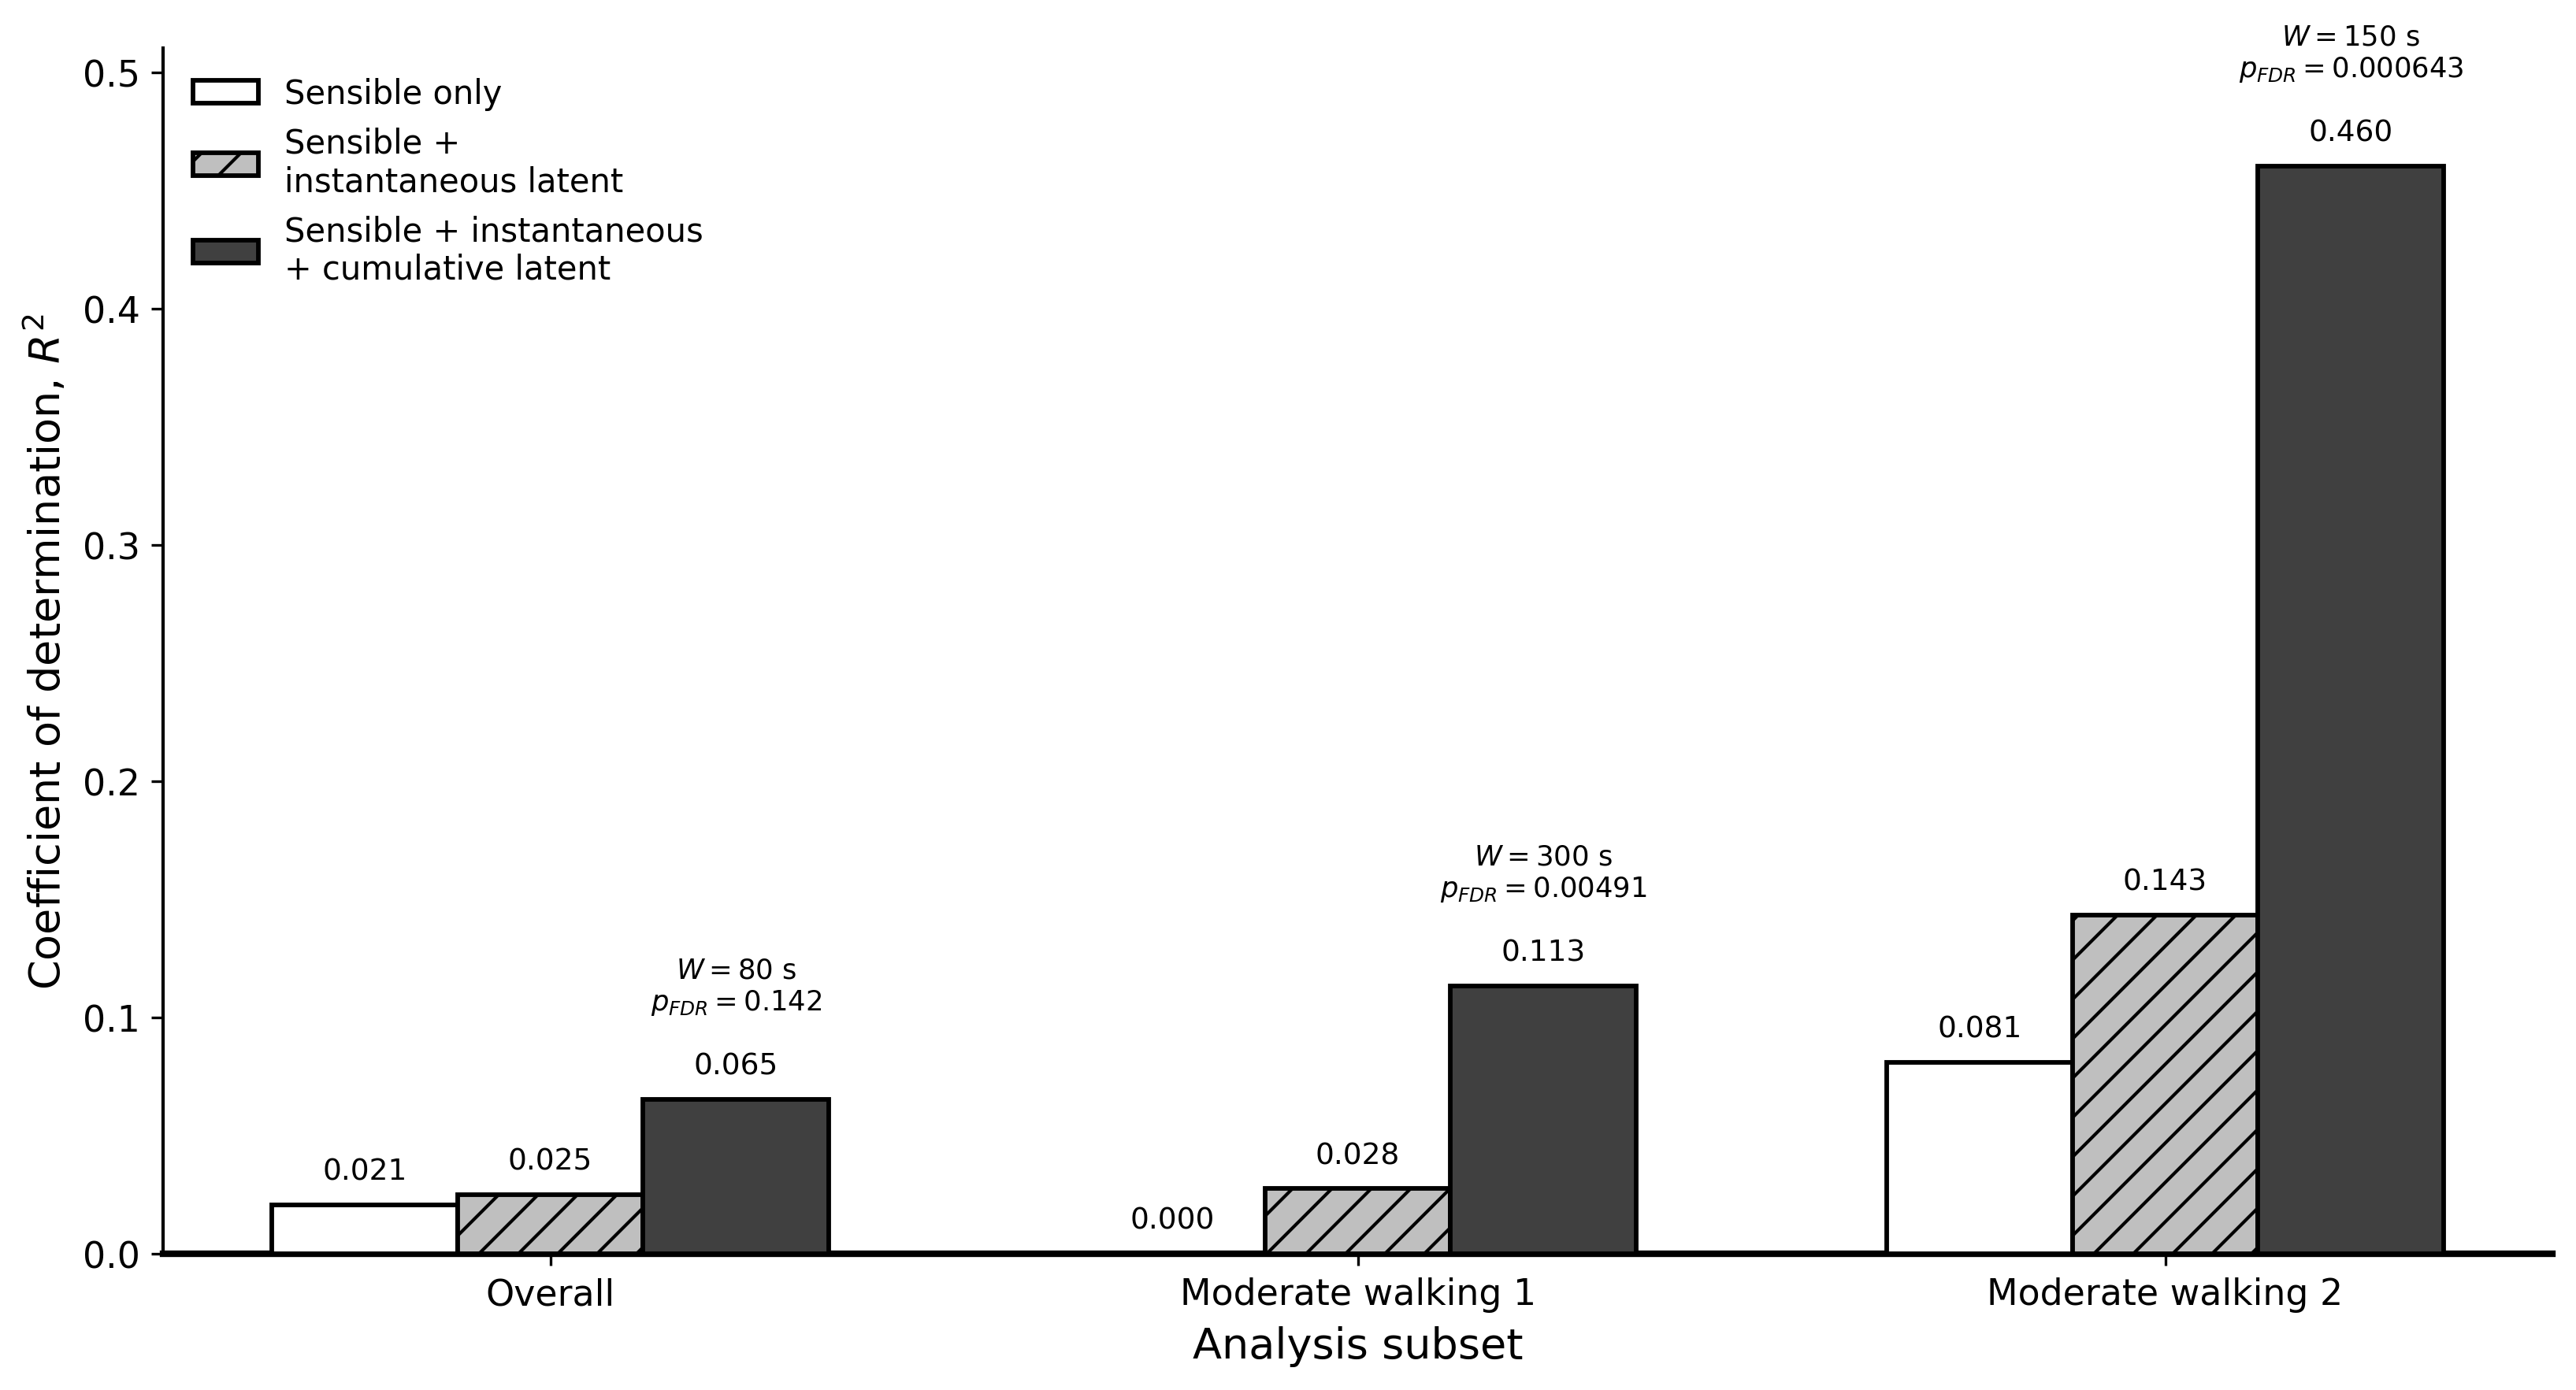

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# PATHS
# ============================================================

INPUT_PATH = (
    ROOT
    / "reports"
    / "9_humidity"
    / "lagged_regression"
    / "cumulative_latent_analysis"
    / "cumulative_latent_ols_results.csv"
)

OUTPUT_DIR = (
    ROOT
    / "reports"
    / "9_humidity"
    / "lagged_regression"
    / "cumulative_latent_analysis"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

if not INPUT_PATH.exists():
    raise FileNotFoundError(
        f"Cumulative analysis results not found: {INPUT_PATH}"
    )

print(f"Loading cumulative results from: {INPUT_PATH}")


# ============================================================
# LOAD RESULTS
# ============================================================

results = pd.read_csv(INPUT_PATH)

required_columns = [
    "analysis_level",
    "analysis_group",
    "history_window_seconds",
    "r2_sensible",
    "r2_instantaneous",
    "r2_cumulative",
    "delta_r2_instantaneous",
    "delta_r2_history",
    "p_delta_pv_history_fdr",
]

missing_columns = [
    column
    for column in required_columns
    if column not in results.columns
]

if missing_columns:
    raise KeyError(
        "Missing required columns in cumulative results: "
        f"{missing_columns}"
    )

numeric_columns = [
    "history_window_seconds",
    "r2_sensible",
    "r2_instantaneous",
    "r2_cumulative",
    "delta_r2_instantaneous",
    "delta_r2_history",
    "p_delta_pv_history_fdr",
]

for column in numeric_columns:
    results[column] = pd.to_numeric(
        results[column],
        errors="coerce",
    )


# ============================================================
# GROUPS TO INCLUDE IN THE FIGURE
# ============================================================

groups_to_plot = [
    {
        "analysis_level": "overall",
        "analysis_group": "all",
        "label": "Overall",
    },
    {
        "analysis_level": "phase",
        "analysis_group": "phase_3",
        "label": "Moderate walking 1",
    },
    {
        "analysis_level": "phase",
        "analysis_group": "phase_4",
        "label": "Moderate walking 2",
    },
]


# ============================================================
# SELECT THE BEST CUMULATIVE WINDOW FOR EACH GROUP
# ============================================================

selected_rows = []

for group_info in groups_to_plot:

    subset = results.loc[
        (
            results["analysis_level"]
            == group_info["analysis_level"]
        )
        & (
            results["analysis_group"]
            == group_info["analysis_group"]
        )
    ].copy()

    subset = subset.dropna(
        subset=[
            "delta_r2_history",
            "r2_sensible",
            "r2_instantaneous",
            "r2_cumulative",
        ]
    )

    if subset.empty:
        raise ValueError(
            "No valid cumulative results found for "
            f"{group_info['analysis_level']} / "
            f"{group_info['analysis_group']}."
        )

    # Select the history window producing the largest additional
    # R² beyond the instantaneous thermo-hygrometric model.
    best_row = subset.loc[
        subset["delta_r2_history"].idxmax()
    ].copy()

    selected_rows.append(
        {
            "label": group_info["label"],
            "analysis_level": group_info["analysis_level"],
            "analysis_group": group_info["analysis_group"],
            "best_window_seconds": (
                best_row["history_window_seconds"]
            ),
            "r2_sensible": (
                best_row["r2_sensible"]
            ),
            "r2_instantaneous": (
                best_row["r2_instantaneous"]
            ),
            "r2_cumulative": (
                best_row["r2_cumulative"]
            ),
            "delta_r2_instantaneous": (
                best_row["r2_instantaneous"]
                - best_row["r2_sensible"]
            ),
            "delta_r2_history": (
                best_row["r2_cumulative"]
                - best_row["r2_instantaneous"]
            ),
            "delta_r2_total": (
                best_row["r2_cumulative"]
                - best_row["r2_sensible"]
            ),
            "p_history_fdr": (
                best_row["p_delta_pv_history_fdr"]
            ),
        }
    )

plot_data = pd.DataFrame(
    selected_rows
)

print("\nValues selected for the figure:")

print(
    plot_data.to_string(
        index=False
    )
)


# ============================================================
# SAVE THE VALUES USED IN THE FIGURE
# ============================================================

plot_data_path = (
    OUTPUT_DIR
    / "model_hierarchy_figure_values.csv"
)

plot_data.to_csv(
    plot_data_path,
    index=False,
)


# ============================================================
# FIGURE SETTINGS
# ============================================================

model_labels = [
    "Sensible only",
    "Sensible +\ninstantaneous latent",
    "Sensible + instantaneous\n+ cumulative latent",
]

model_columns = [
    "r2_sensible",
    "r2_instantaneous",
    "r2_cumulative",
]

bar_facecolors = [
    "white",
    "0.75",
    "0.25",
]

bar_hatches = [
    "",
    "//",
    "",
]

n_groups = len(
    plot_data
)

n_models = len(
    model_columns
)

x_group = np.arange(
    n_groups
)

bar_width = 0.23

bar_offsets = np.array(
    [
        -bar_width,
        0,
        bar_width,
    ]
)


# ============================================================
# CREATE FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(11, 6),
    dpi=300,
)

bar_containers = []

for model_index, (
    model_column,
    model_label,
    facecolor,
    hatch,
) in enumerate(
    zip(
        model_columns,
        model_labels,
        bar_facecolors,
        bar_hatches,
    )
):

    positions = (
        x_group
        + bar_offsets[model_index]
    )

    bars = ax.bar(
        positions,
        plot_data[model_column],
        width=bar_width,
        facecolor=facecolor,
        edgecolor="black",
        linewidth=1.4,
        hatch=hatch,
        label=model_label,
        zorder=3,
    )

    bar_containers.append(
        bars
    )


# ============================================================
# ADD R-SQUARED VALUES
# ============================================================

for model_index, model_column in enumerate(
    model_columns
):

    positions = (
        x_group
        + bar_offsets[model_index]
    )

    for x_position, value in zip(
        positions,
        plot_data[model_column],
    ):

        ax.text(
            x_position,
            value + 0.008,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )


# ============================================================
# ADD INCREMENTAL DELTA R-SQUARED ANNOTATIONS
# ============================================================

for group_index, row in plot_data.iterrows():

    x_instantaneous = (
        x_group[group_index]
        + bar_offsets[1]
    )

    x_cumulative = (
        x_group[group_index]
        + bar_offsets[2]
    )

    instantaneous_value = (
        row["r2_instantaneous"]
    )

    cumulative_value = (
        row["r2_cumulative"]
    )



# ============================================================
# ADD OPTIMAL HISTORY WINDOW ABOVE CUMULATIVE BARS
# ============================================================

for group_index, row in plot_data.iterrows():

    x_position = (
        x_group[group_index]
        + bar_offsets[2]
    )

    y_position = (
        row["r2_cumulative"]
        + 0.035
    )

    window_seconds = int(
        row["best_window_seconds"]
    )

    p_fdr = row["p_history_fdr"]

    if np.isfinite(p_fdr):
        annotation = (
            f"$W={window_seconds}$ s\n"
            f"$p_{{FDR}}={p_fdr:.3g}$"
        )
    else:
        annotation = (
            f"$W={window_seconds}$ s"
        )

    ax.text(
        x_position,
        y_position,
        annotation,
        ha="center",
        va="bottom",
        fontsize=8.5,
    )


# ============================================================
# AXIS FORMATTING
# ============================================================

ax.set_xticks(
    x_group
)

ax.set_xticklabels(
    plot_data["label"],
    fontsize=11,
)

ax.set_ylabel(
    r"Coefficient of determination, $R^2$",
    fontsize=13,
)

ax.set_xlabel(
    "Analysis subset",
    fontsize=13,
)

# Automatic upper limit with space for annotations
maximum_r2 = (
    plot_data[
        [
            "r2_sensible",
            "r2_instantaneous",
            "r2_cumulative",
        ]
    ]
    .to_numpy()
    .max()
)

ax.set_ylim(
    0,
    maximum_r2 + 0.05,
)

ax.axhline(
    0,
    color="black",
    linewidth=0.8,
    zorder=1,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(1)

ax.tick_params(
    axis="both",
    labelsize=11,
)

ax.legend(
    loc="upper left",
    frameon=False,
    fontsize=10,
    ncol=1,
)



# ============================================================
# SAVE
# ============================================================

plt.tight_layout()

output_path = (
    OUTPUT_DIR
    / "model_hierarchy_r2_comparison.png"
)

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

print(
    f"\nFigure saved to: {output_path}"
)

plt.show()